# HVIA Task 1 — Olist EDA & Business Analysis

**HVIA – Data & AI Solutions** | Internship Task 1  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Scope:** Orders 2016–2018 (marketplace aggregator model)

Supporting-work notebook: load all **9** tables, check data quality, build **order-level** KPIs where needed, and save charts to `outputs/charts/`.

**Run:** *Run All* from the repo. Paths resolve relative to the project root (parent of `notebooks/`).


## 0. Setup

Imports, relative paths, chart helper, and plot style.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Project root = parent of notebooks/ when kernel cwd is notebooks/
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'archive').exists():
    # Walk up a few levels looking for archive/
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'archive').exists() and (candidate / 'notebooks').exists():
            ROOT = candidate
            break

DATA_PATH = ROOT / 'archive'
CHARTS_PATH = ROOT / 'outputs' / 'charts'
CHARTS_PATH.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    # Fallback when CSVs live under the bundled Kaggle extract folder
    alt = ROOT / 'Brazilian_E-Commerce_Data_Analysis-master' / 'archive'
    if alt.exists():
        DATA_PATH = alt

assert DATA_PATH.exists(), f'Data folder not found: {DATA_PATH}'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.size': 10,
    'figure.figsize': (12, 6),
})


def save_chart(fig, name):
    # Save under outputs/charts/ (still displayable via plt.show())
    fig.tight_layout()
    out = CHARTS_PATH / f'{name}.png'
    fig.savefig(out, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {out.relative_to(ROOT)}')
    return fig


print(f'ROOT:   {ROOT}')
print(f'DATA:   {DATA_PATH}')
print(f'CHARTS: {CHARTS_PATH}')


ROOT:   C:\ai atuomation\hvia
DATA:   C:\ai atuomation\hvia\archive
CHARTS: C:\ai atuomation\hvia\outputs\charts


## Locked metric definitions

Canonical formulas, grains, and denominators: **[`docs/01-definitions.md`](../docs/01-definitions.md)**.

| Metric | Locked rule (summary) |
|--------|------------------------|
| **Late (primary)** | `delivery_delta_days > 0` on delivered base; **6.77%** of **96,470** (sensitivity: strict timestamp **8.11%**) |
| **Delivered base** | `status == delivered` + both delivery & estimated dates non-null → **96,470** |
| **AOV (primary)** | Mean of per-order `Σ price` → **R$ 137.75** |
| **Freight** | **Primary** `Σfreight/(Σprice+Σfreight)` **14.2%** of total paid; secondary `Σfreight/Σprice` ~**16.6%**; mean item ratio **21.3%** |
| **Retention** | **Crude full-window** one-time rate on `customer_unique_id` → **96.9%** (93,099 / 96,096) |
| **Revenue base** | `SUM(price)` product GMV (excludes freight) → **R$ 13,591,643.70** |

Truncation: orders window **2016-09-04 → 2018-10-17**; items-joined / master max **2018-09-03** (**775** item-less orders). Do not change code cells to redefine these.

## 1. Load all 9 tables & data quality

`orders` is the hub. Missing delivery timestamps are expected for non-delivered statuses.


In [2]:
orders = pd.read_csv(DATA_PATH / 'olist_orders_dataset.csv')
items = pd.read_csv(DATA_PATH / 'olist_order_items_dataset.csv')
payments = pd.read_csv(DATA_PATH / 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(DATA_PATH / 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(DATA_PATH / 'olist_customers_dataset.csv')
sellers = pd.read_csv(DATA_PATH / 'olist_sellers_dataset.csv')
products = pd.read_csv(DATA_PATH / 'olist_products_dataset.csv')
geolocation = pd.read_csv(DATA_PATH / 'olist_geolocation_dataset.csv')
cat_translation = pd.read_csv(DATA_PATH / 'product_category_name_translation.csv')

datasets = {
    'orders': orders, 'items': items, 'payments': payments, 'reviews': reviews,
    'customers': customers, 'sellers': sellers, 'products': products,
    'geolocation': geolocation, 'cat_translation': cat_translation,
}

print('DATA QUALITY REPORT (missing values)')
print('-' * 60)
for name, df in datasets.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]
    total_cells = df.shape[0] * df.shape[1]
    overall_pct = df.isna().sum().sum() / total_cells * 100
    print(f'{name:16s}  {df.shape[0]:>9,} rows x {df.shape[1]:2d} cols | overall missing: {overall_pct:5.2f}%')
    if len(missing) == 0:
        print('  (no missing values)')
    else:
        for col, cnt in missing.items():
            print(f'  - {col}: {cnt:,} ({cnt / len(df) * 100:.1f}%)')


DATA QUALITY REPORT (missing values)
------------------------------------------------------------
orders               99,441 rows x  8 cols | overall missing:  0.62%
  - order_approved_at: 160 (0.2%)
  - order_delivered_carrier_date: 1,783 (1.8%)
  - order_delivered_customer_date: 2,965 (3.0%)
items               112,650 rows x  7 cols | overall missing:  0.00%
  (no missing values)
payments            103,886 rows x  5 cols | overall missing:  0.00%
  (no missing values)
reviews              99,224 rows x  7 cols | overall missing: 21.01%
  - review_comment_title: 87,656 (88.3%)
  - review_comment_message: 58,247 (58.7%)
customers            99,441 rows x  5 cols | overall missing:  0.00%
  (no missing values)
sellers               3,095 rows x  4 cols | overall missing:  0.00%
  (no missing values)
products             32,951 rows x  9 cols | overall missing:  0.83%
  - product_category_name: 610 (1.9%)
  - product_name_lenght: 610 (1.9%)
  - product_description_lenght: 610 (1.9%)
 

geolocation       1,000,163 rows x  5 cols | overall missing:  0.00%
  (no missing values)
cat_translation          71 rows x  2 cols | overall missing:  0.00%
  (no missing values)


## 2. Prepare dates, categories, geo centroids & master table

- Translate categories to English  
- Aggregate geolocation to **one lat/lng per zip prefix** (mean)  
- Item-level `master` for category/seller metrics; delivery KPIs stay **order-level** later


In [3]:
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])
reviews['has_comment'] = reviews['review_comment_message'].fillna('').str.strip().ne('')
reviews['comment_length'] = reviews['review_comment_message'].fillna('').str.len()

products = products.merge(cat_translation, on='product_category_name', how='left')

geo_zip = (
    geolocation
    .groupby('geolocation_zip_code_prefix')
    .agg(lat=('geolocation_lat', 'mean'), lng=('geolocation_lng', 'mean'))
    .reset_index()
)

master = (
    items
    .merge(orders, on='order_id', how='left')
    .merge(
        products[['product_id', 'product_category_name_english', 'product_weight_g']],
        on='product_id', how='left',
    )
    .merge(
        customers[['customer_id', 'customer_unique_id', 'customer_city',
                   'customer_state', 'customer_zip_code_prefix']],
        on='customer_id', how='left',
    )
    .merge(
        sellers[['seller_id', 'seller_city', 'seller_state', 'seller_zip_code_prefix']],
        on='seller_id', how='left',
    )
)

master['actual_delivery_days'] = (
    master['order_delivered_customer_date'] - master['order_purchase_timestamp']
).dt.days
master['estimated_delivery_days'] = (
    master['order_estimated_delivery_date'] - master['order_purchase_timestamp']
).dt.days
master['delivery_delta'] = (
    master['order_delivered_customer_date'] - master['order_estimated_delivery_date']
).dt.days
master['is_late'] = master['delivery_delta'] > 0
master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M')

print(f'Master table: {len(master):,} rows x {master.shape[1]} columns')
print(
    f'Date range: {master["order_purchase_timestamp"].min().date()} '
    f'-> {master["order_purchase_timestamp"].max().date()}'
)
print(f'Unique orders: {master["order_id"].nunique():,}')
print(f'Geolocation zip centroids: {len(geo_zip):,}')


Master table: 112,650 rows x 28 columns
Date range: 2016-09-04 -> 2018-09-03
Unique orders: 98,666
Geolocation zip centroids: 19,015


## 3. Order volume & growth

YoY Jan 2017→Jan 2018 looks large partly due to **early-base effect** (platform still ramping in Jan 2017). Peak month aligns with Black Friday seasonality.


  Saved: outputs\charts\01_monthly_order_volume.png


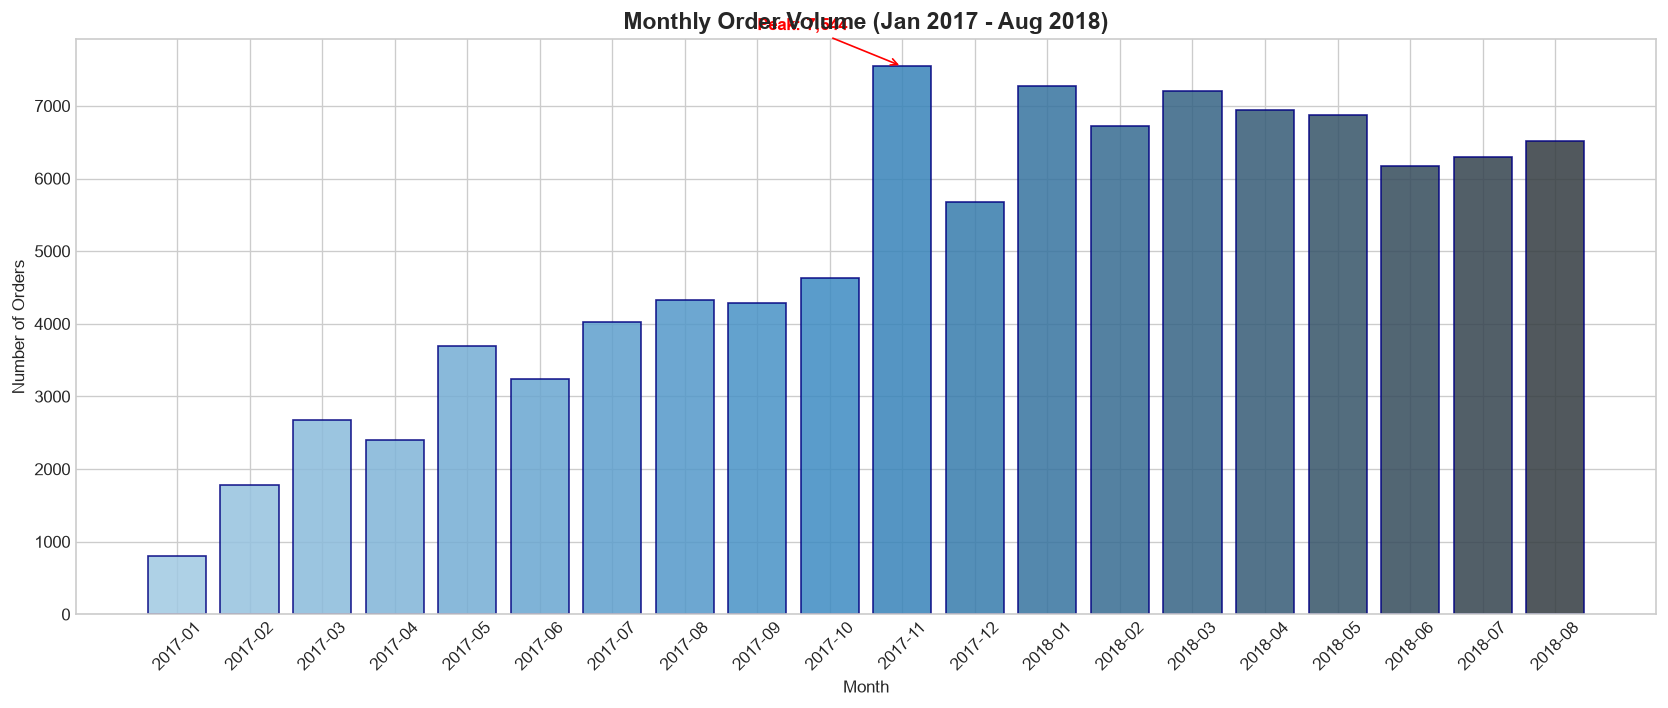

Jan 2017 -> Jan 2018 YoY Growth: 808.6%
(Caveat: early-base — Jan 2017 had only 800 orders)
Peak month: 2017-11 with 7,544 orders


  Saved: outputs\charts\02_orders_by_day_of_week.png


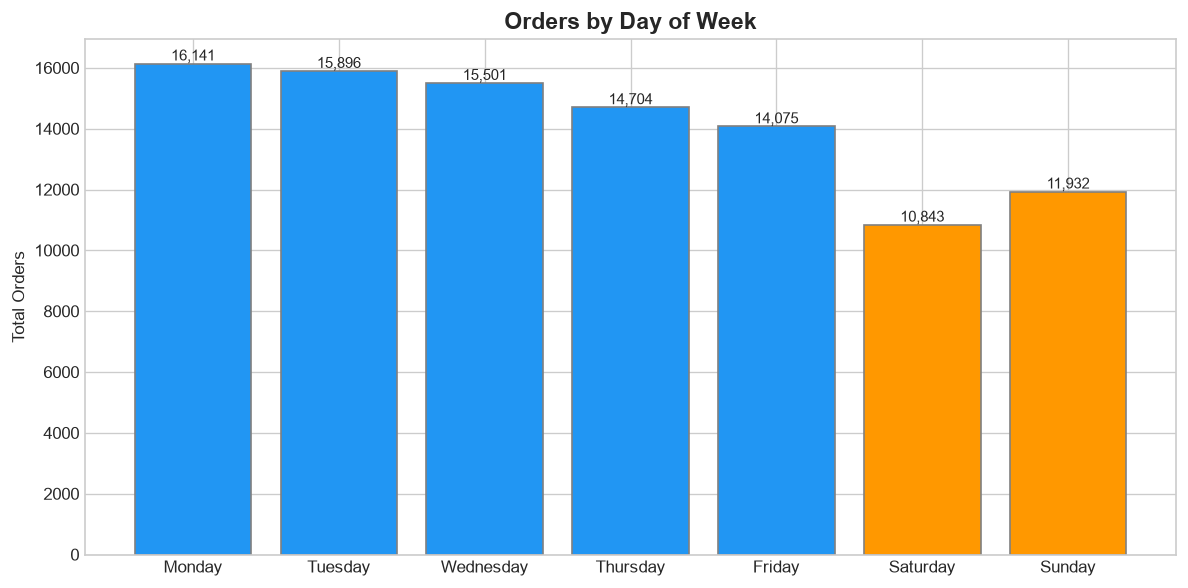

Busiest day: Monday (16,141)
Slowest day: Saturday (10,843)


In [4]:
monthly_orders = orders[
    (orders['order_purchase_timestamp'] >= '2017-01-01')
    & (orders['order_purchase_timestamp'] < '2018-09-01')
]
monthly = monthly_orders.groupby(monthly_orders['order_purchase_timestamp'].dt.to_period('M')).size()

fig, ax = plt.subplots(figsize=(14, 6))
months_str = [str(m) for m in monthly.index]
ax.bar(
    months_str, monthly.values,
    color=sns.color_palette('Blues_d', len(monthly)),
    edgecolor='navy', alpha=0.85,
)
ax.set_title('Monthly Order Volume (Jan 2017 - Aug 2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=45)

peak_idx = int(monthly.values.argmax())
peak_month_label = months_str[peak_idx]
peak_month_orders = int(monthly.values[peak_idx])
ax.annotate(
    f'Peak: {peak_month_orders:,}',
    xy=(peak_idx, peak_month_orders),
    xytext=(peak_idx - 2, peak_month_orders + 500),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontweight='bold',
)
save_chart(fig, '01_monthly_order_volume')
plt.show()

growth_jan17 = monthly.iloc[0]
growth_jan18 = monthly.loc[monthly.index == '2018-01']
growth_pct = 0.0
if len(growth_jan18) > 0:
    growth_pct = ((growth_jan18.iloc[0] - growth_jan17) / growth_jan17) * 100
    print(f'Jan 2017 -> Jan 2018 YoY Growth: {growth_pct:.1f}%')
    print(f'(Caveat: early-base — Jan 2017 had only {int(growth_jan17):,} orders)')
print(f'Peak month: {peak_month_label} with {peak_month_orders:,} orders')

dow = monthly_orders['order_purchase_timestamp'].dt.day_name().value_counts()
dow = dow.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dow.index, dow.values, color=['#2196F3'] * 5 + ['#FF9800'] * 2, edgecolor='gray')
ax.set_title('Orders by Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Orders')
for i, v in enumerate(dow.values):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)
save_chart(fig, '02_orders_by_day_of_week')
plt.show()

print(f'Busiest day: {dow.idxmax()} ({dow.max():,})')
print(f'Slowest day: {dow.idxmin()} ({dow.min():,})')


## 4. Revenue & product categories

Product revenue = sum of item `price`. Freight reported separately. A few categories drive most GMV.


Total Product Revenue: R$ 13,591,643.70
Total Freight Revenue: R$ 2,251,909.54
Freight as % of Total: 14.2%
Average Order Value (AOV): R$ 137.75


  Saved: outputs\charts\03_top15_categories_revenue.png


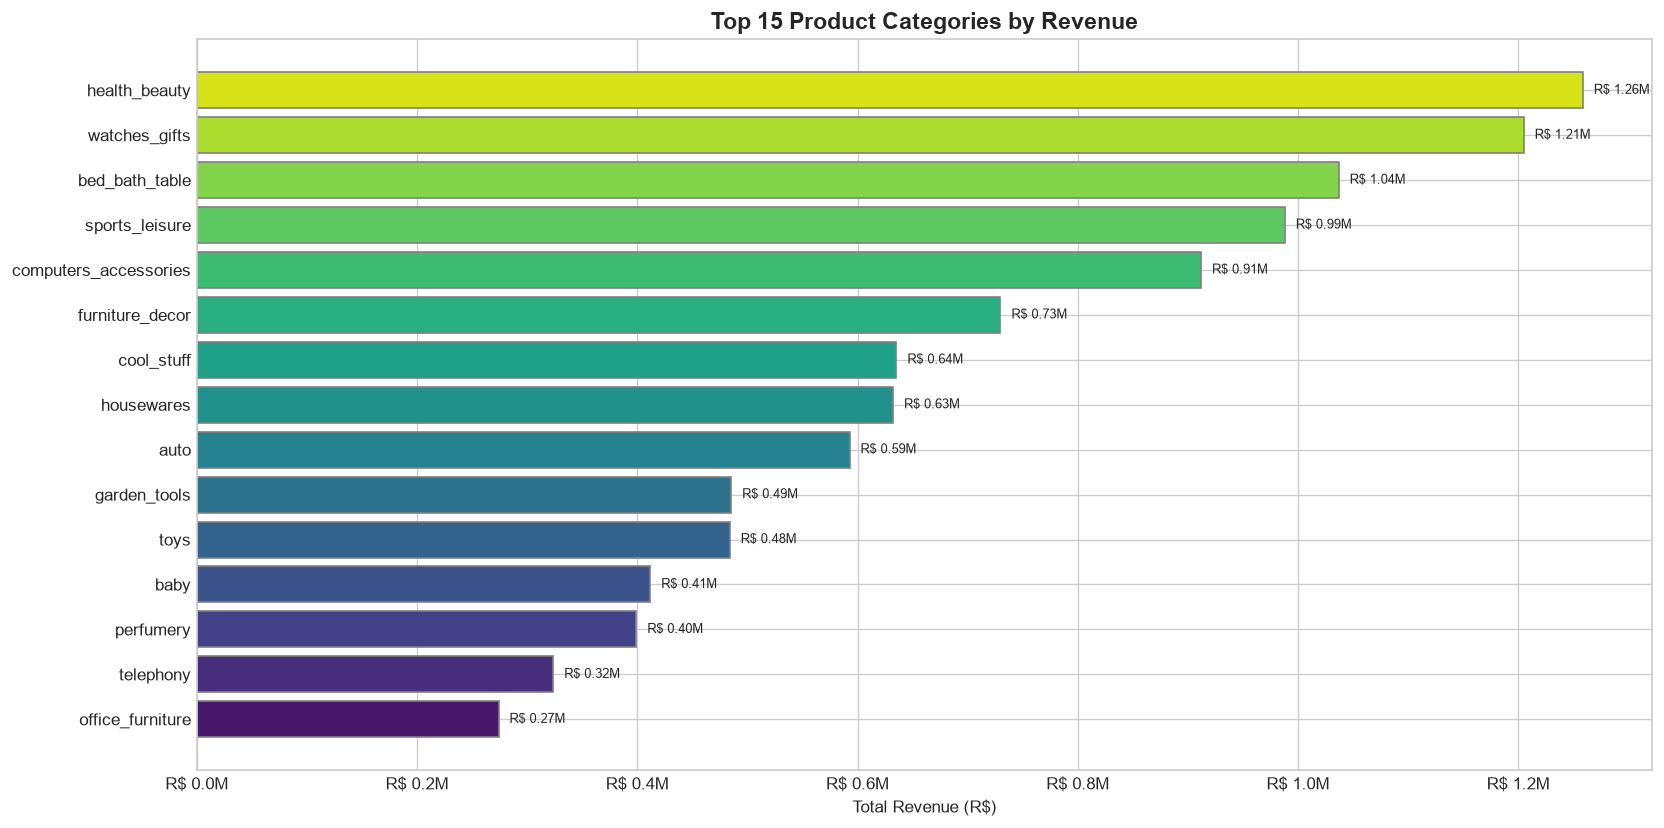

Top 16 categories (of 71) generate 80% of revenue


In [5]:
total_revenue = items['price'].sum()
total_freight = items['freight_value'].sum()
avg_order_value = items.groupby('order_id')['price'].sum().mean()
freight_ratio = total_freight / (total_revenue + total_freight) * 100

print(f'Total Product Revenue: R$ {total_revenue:,.2f}')
print(f'Total Freight Revenue: R$ {total_freight:,.2f}')
print(f'Freight as % of Total: {freight_ratio:.1f}%')
print(f'Average Order Value (AOV): R$ {avg_order_value:,.2f}')

cat_rev = master.groupby('product_category_name_english').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique'),
    avg_price=('price', 'mean'),
    items=('order_id', 'count'),
).sort_values('revenue', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(
    cat_rev.index[::-1], cat_rev['revenue'].values[::-1],
    color=sns.color_palette('viridis', 15), edgecolor='gray',
)
ax.set_title('Top 15 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (R$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x / 1e6:.1f}M'))
for bar, val in zip(bars, cat_rev['revenue'].values[::-1]):
    ax.text(val + 10000, bar.get_y() + bar.get_height() / 2, f'R$ {val / 1e6:.2f}M', va='center', fontsize=8)
save_chart(fig, '03_top15_categories_revenue')
plt.show()

cat_all = master.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False)
cat_cumsum = cat_all.cumsum() / cat_all.sum() * 100
top80_count = int((cat_cumsum <= 80).sum())
print(f'Top {top80_count} categories (of {len(cat_all)}) generate 80% of revenue')


## 5. Delivery performance (order-level)

One row per **delivered** order so multi-item baskets are not overweight. Late = delivered after the estimated date.


Delivered orders: 96,470
Late: 6,534 (6.8%) | On-time/early: 89,936 (93.2%)
Avg actual delivery: 12.1 days
Avg estimated: 23.4 days
When late, avg delay: 10.6 days


  Saved: outputs\charts\04_delivery_performance.png


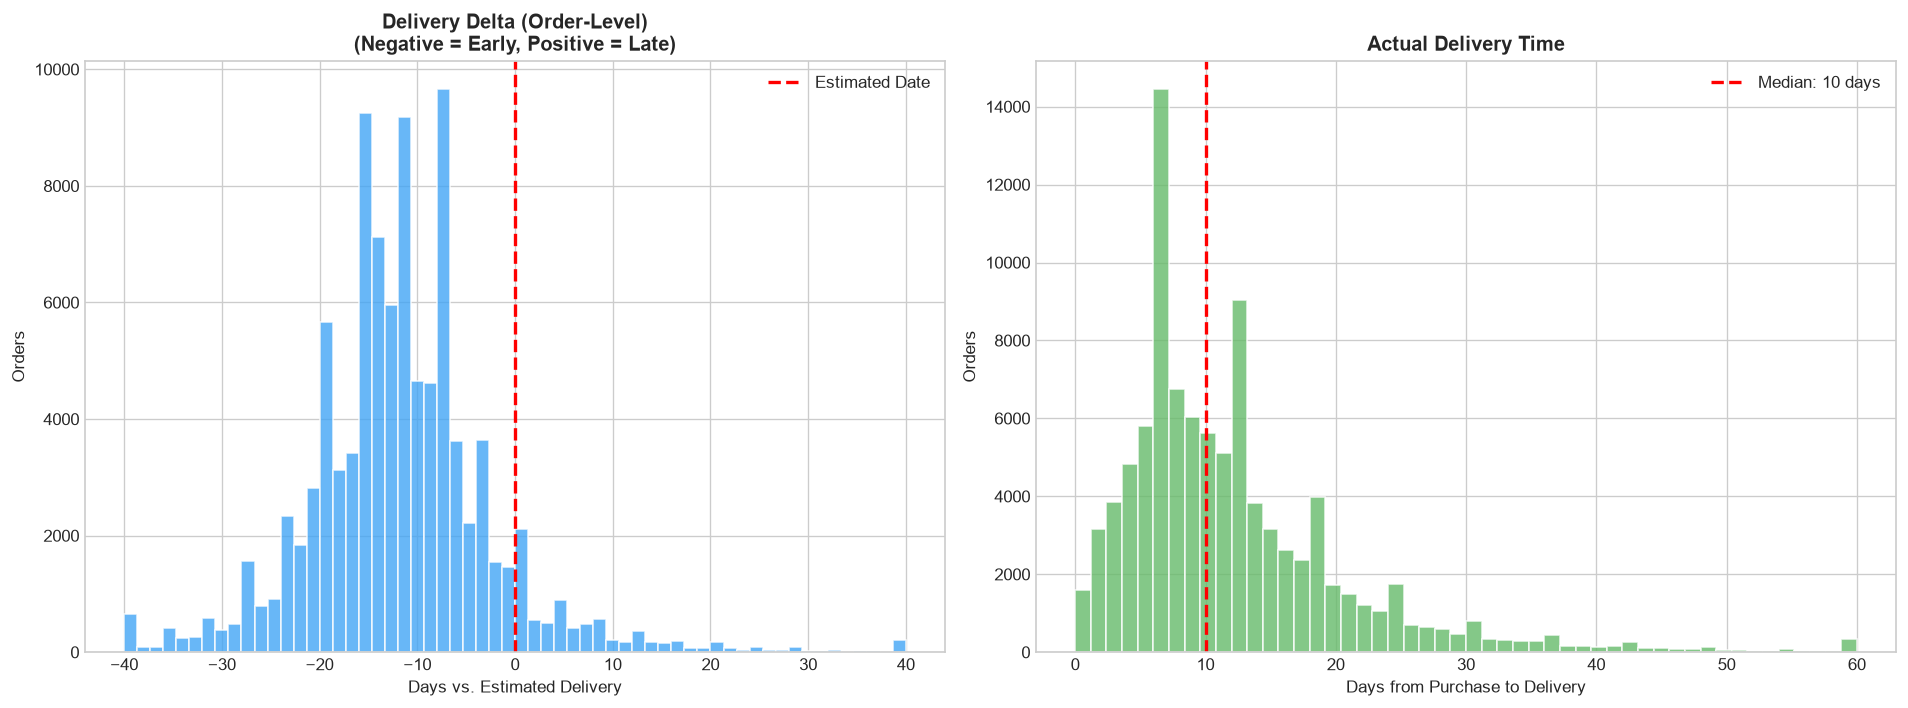

  Saved: outputs\charts\05_late_delivery_by_state.png


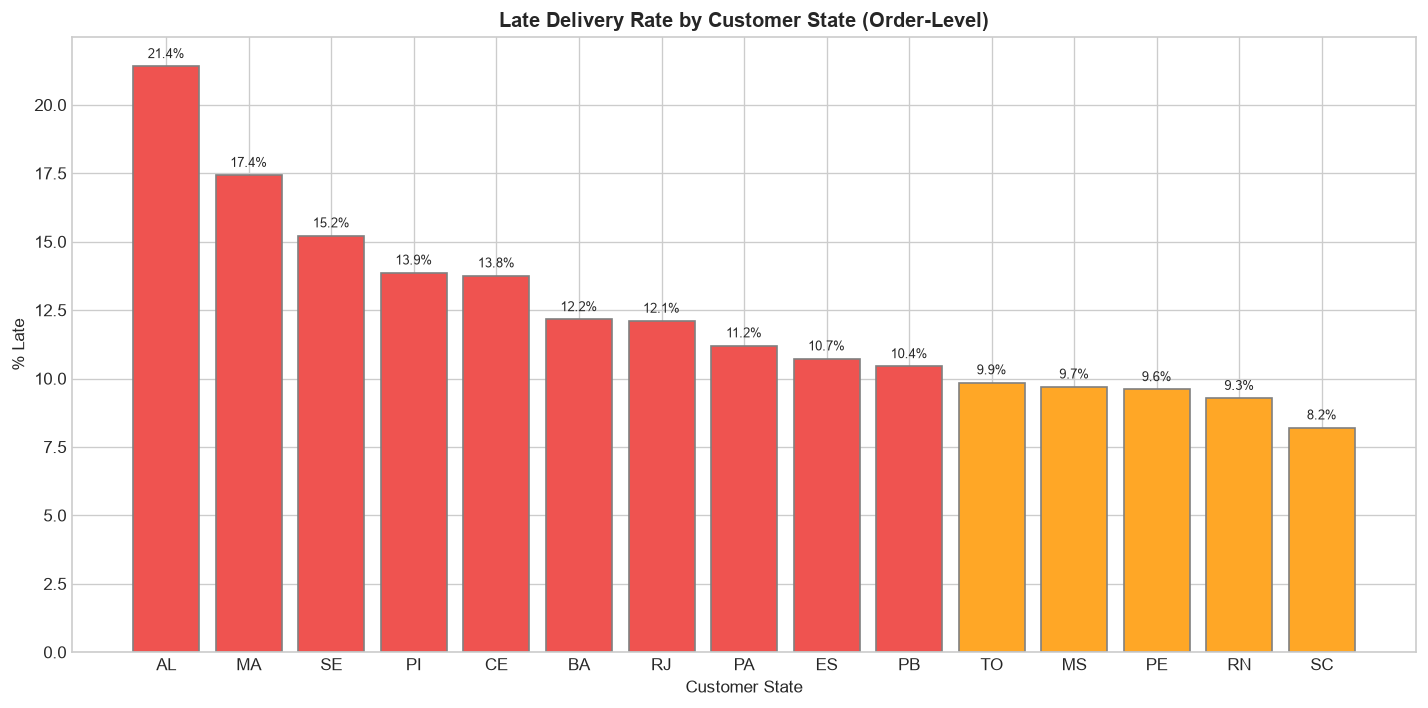

Highest late rate: AL (21.4%)


In [6]:
orders_delivered = orders[orders['order_status'] == 'delivered'].dropna(
    subset=['order_delivered_customer_date', 'order_estimated_delivery_date']
).copy()

orders_delivered['actual_delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] - orders_delivered['order_purchase_timestamp']
).dt.days
orders_delivered['estimated_delivery_days'] = (
    orders_delivered['order_estimated_delivery_date'] - orders_delivered['order_purchase_timestamp']
).dt.days
orders_delivered['delivery_delta'] = (
    orders_delivered['order_delivered_customer_date'] - orders_delivered['order_estimated_delivery_date']
).dt.days
orders_delivered['is_late'] = orders_delivered['delivery_delta'] > 0

orders_delivered = orders_delivered.merge(
    customers[['customer_id', 'customer_state']], on='customer_id', how='left'
)
order_financials = items.groupby('order_id').agg(
    order_price=('price', 'sum'),
    order_freight=('freight_value', 'sum'),
).reset_index()
orders_delivered = orders_delivered.merge(order_financials, on='order_id', how='left')

late_orders = orders_delivered[orders_delivered['is_late']]
ontime_orders = orders_delivered[~orders_delivered['is_late']]
late_pct = len(late_orders) / len(orders_delivered) * 100

print(f'Delivered orders: {len(orders_delivered):,}')
print(f'Late: {len(late_orders):,} ({late_pct:.1f}%) | On-time/early: {len(ontime_orders):,} ({100 - late_pct:.1f}%)')
print(f'Avg actual delivery: {orders_delivered["actual_delivery_days"].mean():.1f} days')
print(f'Avg estimated: {orders_delivered["estimated_delivery_days"].mean():.1f} days')
print(f'When late, avg delay: {late_orders["delivery_delta"].mean():.1f} days')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(orders_delivered['delivery_delta'].clip(-40, 40), bins=60, color='#42A5F5', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linewidth=2, linestyle='--', label='Estimated Date')
axes[0].set_title('Delivery Delta (Order-Level)\n(Negative = Early, Positive = Late)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days vs. Estimated Delivery')
axes[0].set_ylabel('Orders')
axes[0].legend()

axes[1].hist(orders_delivered['actual_delivery_days'].clip(0, 60), bins=50, color='#66BB6A', edgecolor='white', alpha=0.8)
med = orders_delivered['actual_delivery_days'].median()
axes[1].axvline(med, color='red', linewidth=2, linestyle='--', label=f'Median: {med:.0f} days')
axes[1].set_title('Actual Delivery Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Days from Purchase to Delivery')
axes[1].set_ylabel('Orders')
axes[1].legend()
save_chart(fig, '04_delivery_performance')
plt.show()

late_by_state = orders_delivered.groupby('customer_state').agg(
    total=('order_id', 'count'), late=('is_late', 'sum')
)
late_by_state['late_pct'] = late_by_state['late'] / late_by_state['total'] * 100
late_by_state = late_by_state[late_by_state['total'] >= 100].sort_values('late_pct', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#EF5350' if x > 10 else '#FFA726' if x > 7 else '#66BB6A' for x in late_by_state['late_pct']]
ax.bar(late_by_state.index, late_by_state['late_pct'], color=colors, edgecolor='gray')
ax.set_title('Late Delivery Rate by Customer State (Order-Level)', fontsize=12, fontweight='bold')
ax.set_ylabel('% Late')
ax.set_xlabel('Customer State')
for i, (_, row) in enumerate(late_by_state.iterrows()):
    ax.text(i, row['late_pct'] + 0.3, f'{row["late_pct"]:.1f}%', ha='center', fontsize=8)
save_chart(fig, '05_late_delivery_by_state')
plt.show()
print(f'Highest late rate: {late_by_state.index[0]} ({late_by_state["late_pct"].iloc[0]:.1f}%)')


## 6. Delivery vs review scores (+ review text)

Killer insight: late delivery collapses star ratings. We also use comment rate / length by score and a light Portuguese keyword scan on 1-star text.


Avg review (on-time/early): 4.29
Avg review (late):          2.27
Review drop when late:      -2.02 (47%)


  Saved: outputs\charts\06_delivery_vs_review_scores.png


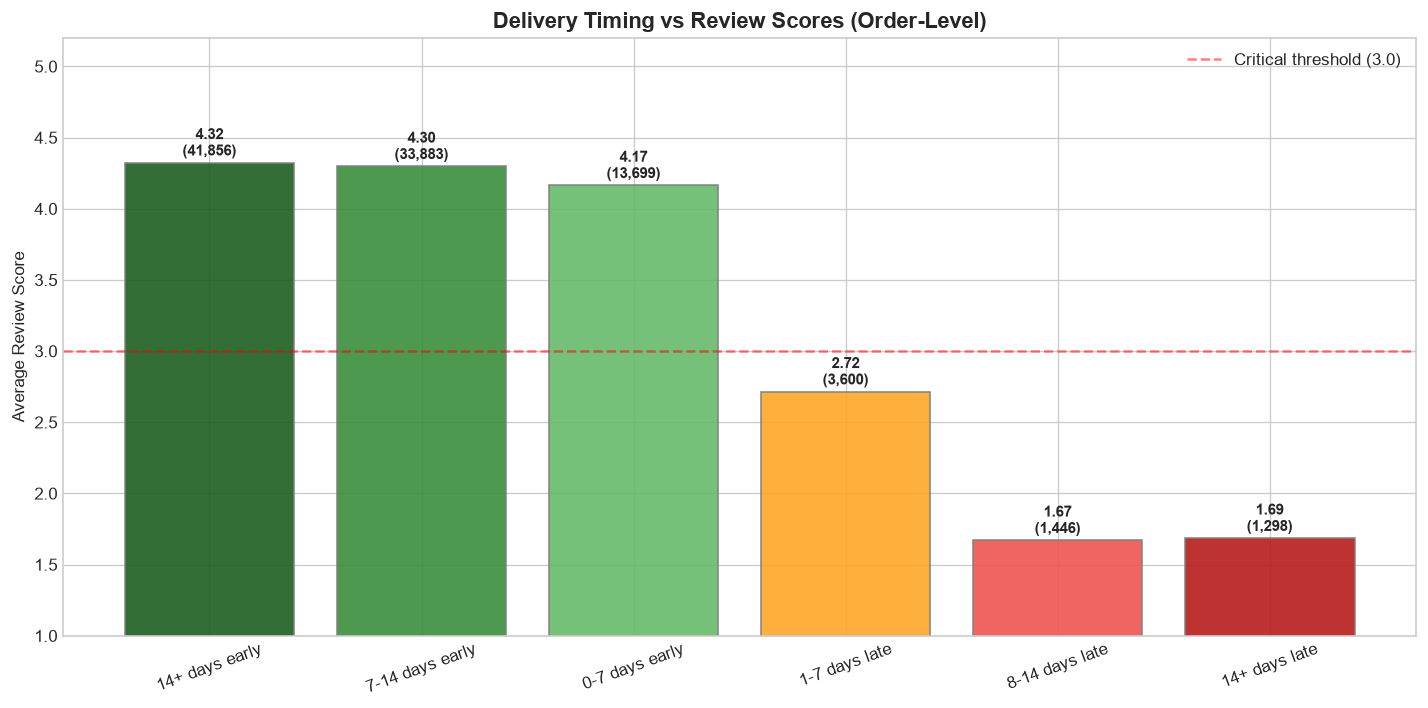

  Saved: outputs\charts\07_review_score_distribution.png


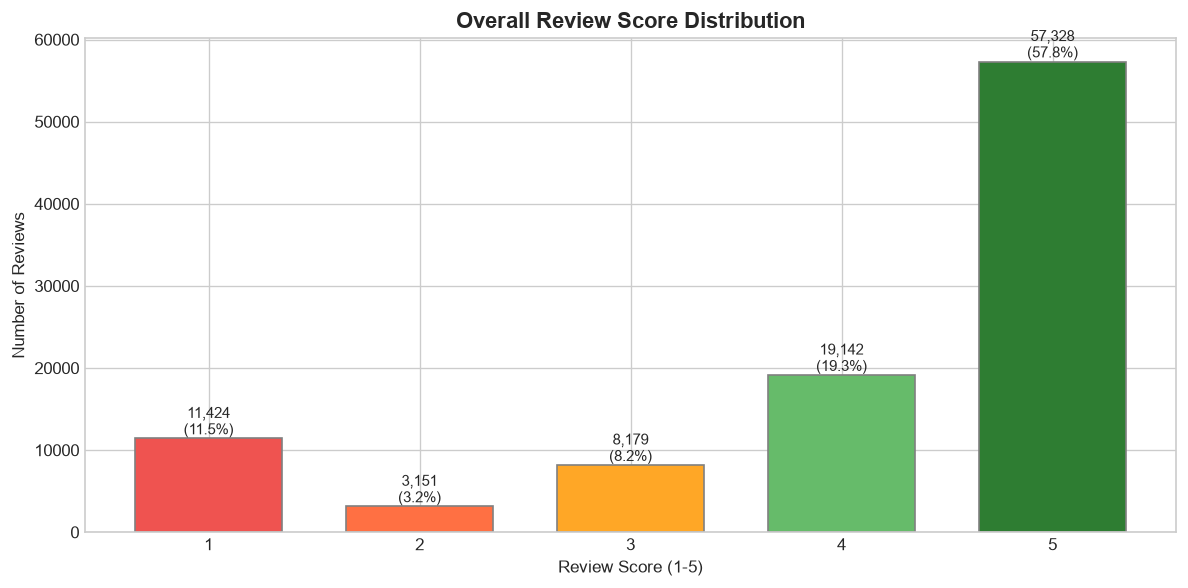

5-star: 57.8% | 1-star: 11.5%
Reviews with comments: 40,950 (41.3%)


Median review response time: 40.2 hours


  Saved: outputs\charts\18_review_text_signals.png


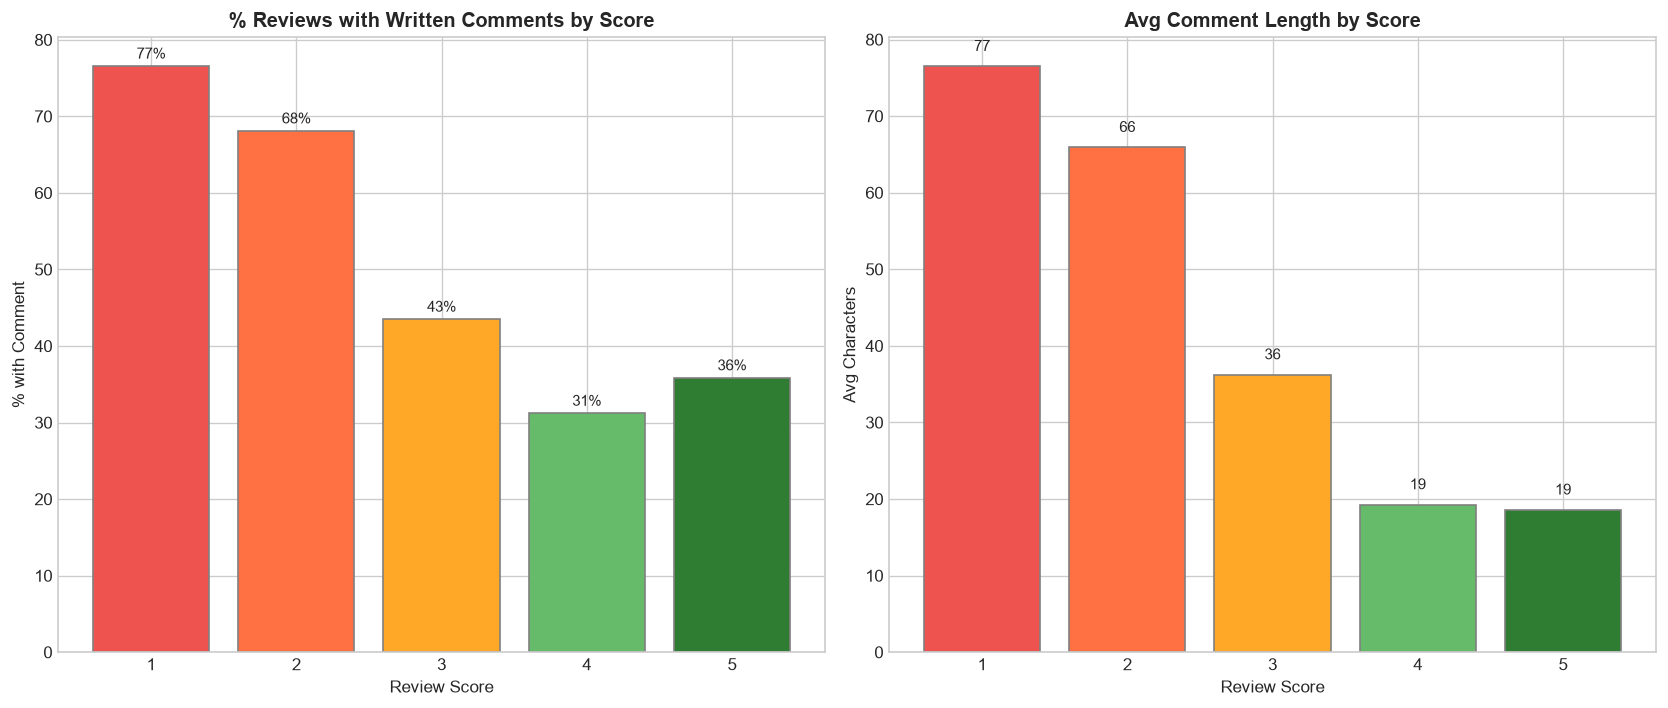

1-star comment themes (keyword hit rate among commented 1-stars):
  - atraso/entrega: 3,572 (40.9%)
  - produto/qualidade: 1,100 (12.6%)
  - cancelamento: 947 (10.8%)


In [7]:
order_reviews_dedup = reviews[['order_id', 'review_score']].drop_duplicates(subset='order_id')
orders_reviews = orders_delivered.merge(order_reviews_dedup, on='order_id', how='inner')

avg_review_ontime = orders_reviews.loc[~orders_reviews['is_late'], 'review_score'].mean()
avg_review_late = orders_reviews.loc[orders_reviews['is_late'], 'review_score'].mean()
review_drop = avg_review_ontime - avg_review_late

print(f'Avg review (on-time/early): {avg_review_ontime:.2f}')
print(f'Avg review (late):          {avg_review_late:.2f}')
print(f'Review drop when late:      -{review_drop:.2f} ({review_drop / avg_review_ontime * 100:.0f}%)')

orders_reviews['delay_bucket'] = pd.cut(
    orders_reviews['delivery_delta'],
    bins=[-100, -14, -7, 0, 7, 14, 100],
    labels=['14+ days early', '7-14 days early', '0-7 days early',
            '1-7 days late', '8-14 days late', '14+ days late'],
)
delay_review = orders_reviews.groupby('delay_bucket', observed=True)['review_score'].agg(['mean', 'count'])

fig, ax1 = plt.subplots(figsize=(12, 6))
colors_delay = ['#1B5E20', '#388E3C', '#66BB6A', '#FFA726', '#EF5350', '#B71C1C']
bars = ax1.bar(range(len(delay_review)), delay_review['mean'], color=colors_delay, edgecolor='gray', alpha=0.9)
ax1.set_xticks(range(len(delay_review)))
ax1.set_xticklabels(delay_review.index, rotation=20)
ax1.set_ylabel('Average Review Score')
ax1.set_title('Delivery Timing vs Review Scores (Order-Level)', fontsize=13, fontweight='bold')
ax1.set_ylim(1, 5.2)
for bar, (_, row) in zip(bars, delay_review.iterrows()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
        f'{row["mean"]:.2f}\n({int(row["count"]):,})', ha='center', fontsize=9, fontweight='bold',
    )
ax1.axhline(y=3.0, color='red', linestyle='--', alpha=0.5, label='Critical threshold (3.0)')
ax1.legend()
save_chart(fig, '06_delivery_vs_review_scores')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
review_dist = reviews['review_score'].value_counts().sort_index()
colors_rev = ['#EF5350', '#FF7043', '#FFA726', '#66BB6A', '#2E7D32']
ax.bar(review_dist.index, review_dist.values, color=colors_rev, edgecolor='gray', width=0.7)
ax.set_title('Overall Review Score Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Review Score (1-5)')
ax.set_ylabel('Number of Reviews')
for i, v in enumerate(review_dist.values):
    ax.text(review_dist.index[i], v + 500, f'{v:,}\n({v / len(reviews) * 100:.1f}%)', ha='center', fontsize=9)
save_chart(fig, '07_review_score_distribution')
plt.show()

pct_1star = (reviews['review_score'] == 1).mean() * 100
pct_5star = (reviews['review_score'] == 5).mean() * 100
print(f'5-star: {pct_5star:.1f}% | 1-star: {pct_1star:.1f}%')

# Review text signals
comment_rate = reviews['has_comment'].mean() * 100
print(f'Reviews with comments: {reviews["has_comment"].sum():,} ({comment_rate:.1f}%)')

comment_by_score = reviews.groupby('review_score').agg(
    n=('review_id', 'count'),
    comment_rate=('has_comment', 'mean'),
    avg_len=('comment_length', 'mean'),
)
comment_by_score['comment_rate'] *= 100

reviews['response_hours'] = (
    reviews['review_answer_timestamp'] - reviews['review_creation_date']
).dt.total_seconds() / 3600
print(f'Median review response time: {reviews["response_hours"].median():.1f} hours')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].bar(
    comment_by_score.index, comment_by_score['comment_rate'],
    color=['#EF5350', '#FF7043', '#FFA726', '#66BB6A', '#2E7D32'], edgecolor='gray',
)
axes[0].set_title('% Reviews with Written Comments by Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('% with Comment')
for score, row in comment_by_score.iterrows():
    axes[0].text(score, row['comment_rate'] + 1, f'{row["comment_rate"]:.0f}%', ha='center', fontsize=9)

axes[1].bar(
    comment_by_score.index, comment_by_score['avg_len'],
    color=['#EF5350', '#FF7043', '#FFA726', '#66BB6A', '#2E7D32'], edgecolor='gray',
)
axes[1].set_title('Avg Comment Length by Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Avg Characters')
for score, row in comment_by_score.iterrows():
    axes[1].text(score, row['avg_len'] + 2, f'{row["avg_len"]:.0f}', ha='center', fontsize=9)
# Chart 18 lives here (not after 17): review-text signals belong to this Section 6 review-score block.
save_chart(fig, '18_review_text_signals')
plt.show()

one_star_text = reviews.loc[
    (reviews['review_score'] == 1) & reviews['has_comment'], 'review_comment_message'
].str.lower()
complaint_keywords = {
    'atraso/entrega': ['atras', 'demor', 'entreg', 'chegou', 'prazo'],
    'produto/qualidade': ['quebr', 'defeito', 'errado', 'diferente', 'qualidade'],
    'cancelamento': ['cancel', 'reembolso', 'estorno', 'devol'],
}
print('1-star comment themes (keyword hit rate among commented 1-stars):')
n_one = max(len(one_star_text), 1)
for theme, kws in complaint_keywords.items():
    hits = one_star_text.apply(lambda t: any(k in t for k in kws)).sum()
    print(f'  - {theme}: {hits:,} ({hits / n_one * 100:.1f}%)')


## 7. Customer retention

Near-zero repeat purchase is a structural loyalty gap (`customer_unique_id`).


Unique customers: 96,096
One-time: 93,099 (96.9%)
Repeat 2+: 2,997 (3.1%)
Loyal 3+:  252 (0.3%)


  Saved: outputs\charts\08_customer_retention_crisis.png


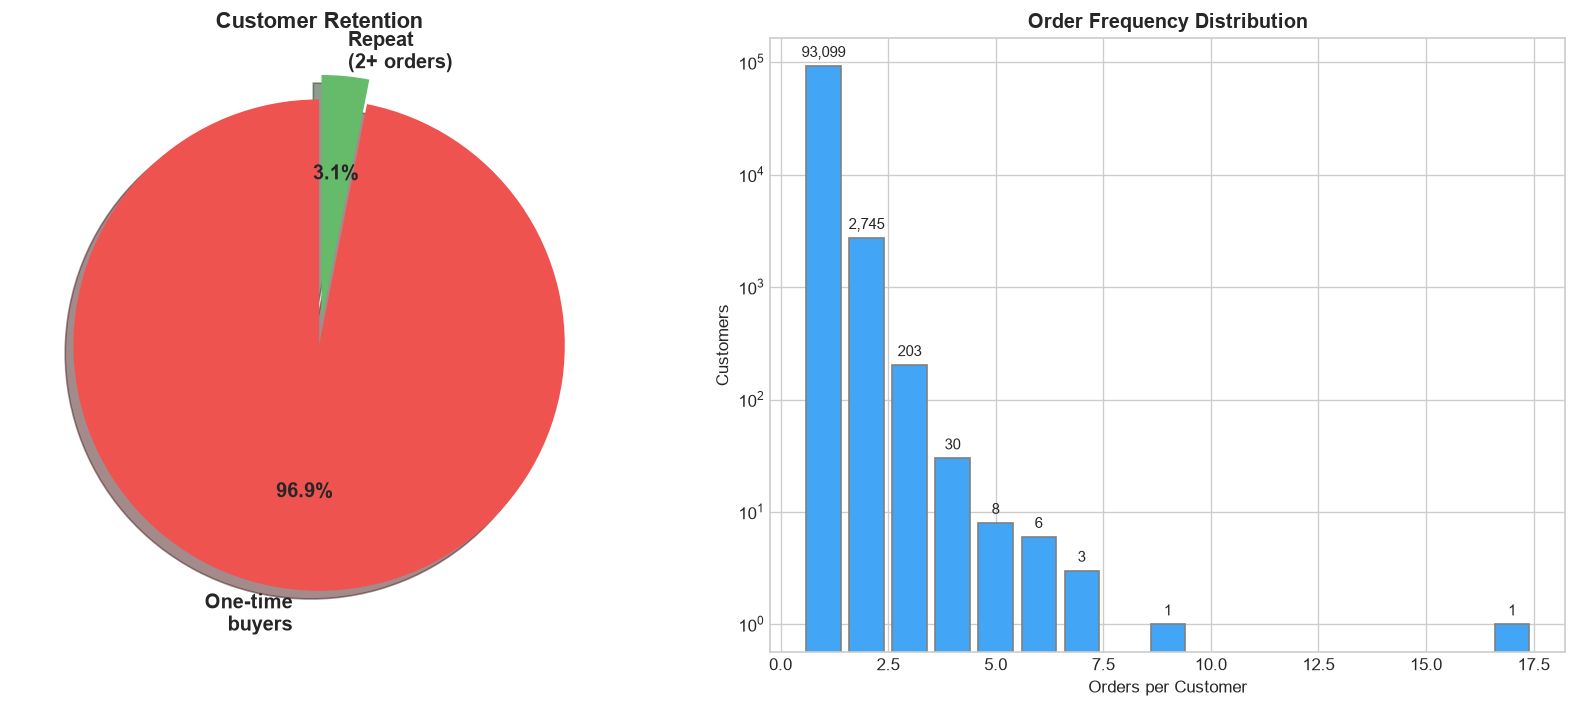

In [8]:
customer_orders = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
repeat_analysis = customer_orders.groupby('customer_unique_id')['order_id'].nunique()

total_customers = len(repeat_analysis)
one_time = int((repeat_analysis == 1).sum())
repeat_2plus = int((repeat_analysis >= 2).sum())
repeat_3plus = int((repeat_analysis >= 3).sum())

one_time_pct = one_time / total_customers * 100
repeat_pct = repeat_2plus / total_customers * 100
loyal_pct = repeat_3plus / total_customers * 100

print(f'Unique customers: {total_customers:,}')
print(f'One-time: {one_time:,} ({one_time_pct:.1f}%)')
print(f'Repeat 2+: {repeat_2plus:,} ({repeat_pct:.1f}%)')
print(f'Loyal 3+:  {repeat_3plus:,} ({loyal_pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(
    [one_time, repeat_2plus], explode=(0, 0.1),
    labels=['One-time\nbuyers', 'Repeat\n(2+ orders)'],
    colors=['#EF5350', '#66BB6A'], autopct='%1.1f%%', shadow=True, startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
)
axes[0].set_title('Customer Retention', fontsize=13, fontweight='bold')

freq_dist = repeat_analysis.value_counts().sort_index().head(10)
axes[1].bar(freq_dist.index, freq_dist.values, color='#42A5F5', edgecolor='gray')
axes[1].set_title('Order Frequency Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Orders per Customer')
axes[1].set_ylabel('Customers')
axes[1].set_yscale('log')
for x, v in zip(freq_dist.index, freq_dist.values):
    axes[1].text(x, v * 1.2, f'{v:,}', ha='center', fontsize=9)
save_chart(fig, '08_customer_retention_crisis')
plt.show()


## 8. Payments & installments


credit_card: 76,795 (73.9%)
boleto: 19,784 (19.0%)
voucher: 5,775 (5.6%)
debit_card: 1,529 (1.5%)
not_defined: 3 (0.0%)


  Saved: outputs\charts\09_payment_analysis.png


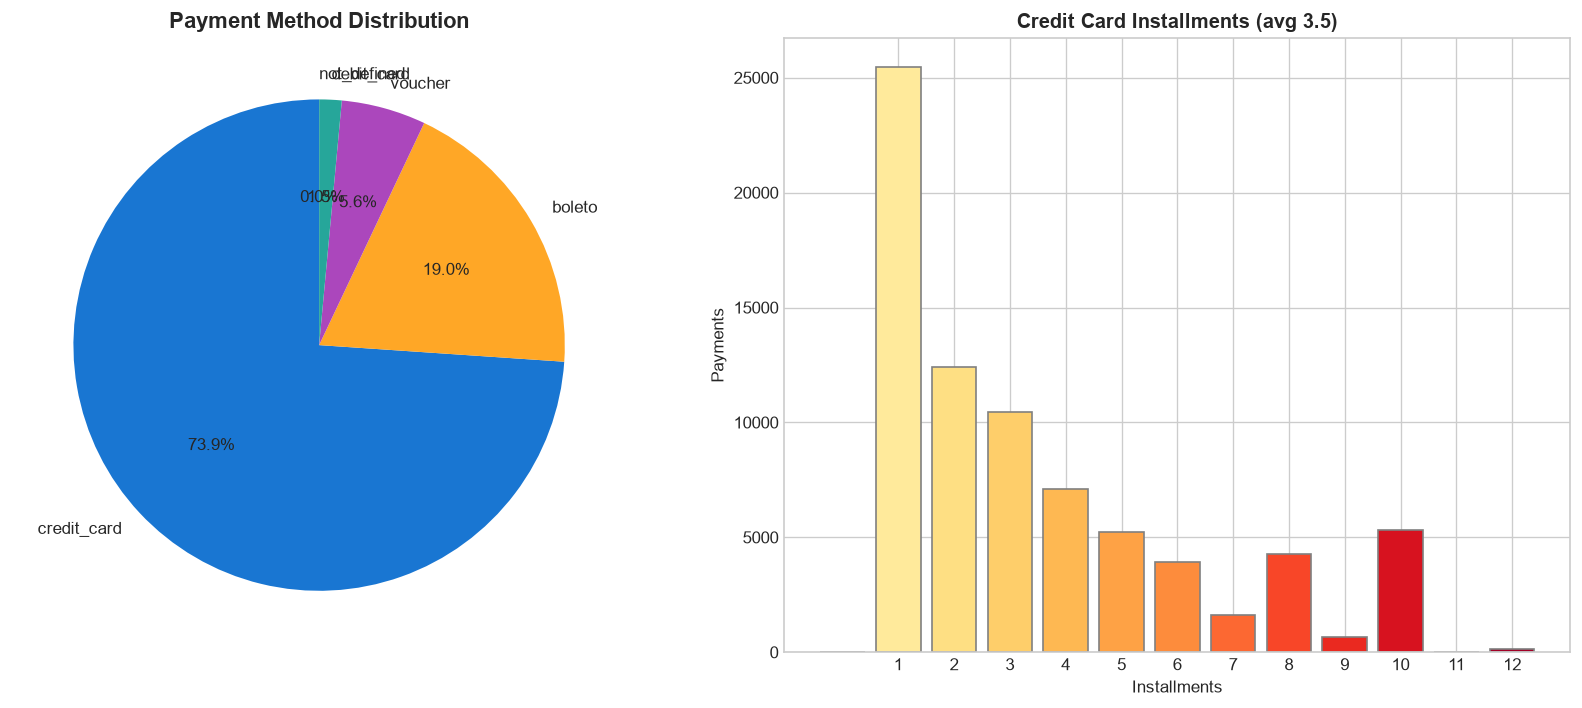

Average payment value by type:
  credit_card: R$ 163.32
  boleto: R$ 145.03
  debit_card: R$ 142.57
  voucher: R$ 65.70
  not_defined: R$ 0.00


In [9]:
payment_dist = payments['payment_type'].value_counts()
for ptype, count in payment_dist.items():
    print(f'{ptype}: {count:,} ({count / len(payments) * 100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_pay = ['#1976D2', '#FFA726', '#AB47BC', '#26A69A', '#BDBDBD']
axes[0].pie(
    payment_dist.values, labels=payment_dist.index, colors=colors_pay,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10},
)
axes[0].set_title('Payment Method Distribution', fontsize=13, fontweight='bold')

cc_installments = payments.loc[payments['payment_type'] == 'credit_card', 'payment_installments']
inst_dist = cc_installments.value_counts().sort_index()
inst_dist = inst_dist[inst_dist.index <= 12]
axes[1].bar(inst_dist.index, inst_dist.values, color=sns.color_palette('YlOrRd', len(inst_dist)), edgecolor='gray')
axes[1].set_title(f'Credit Card Installments (avg {cc_installments.mean():.1f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Installments')
axes[1].set_ylabel('Payments')
axes[1].set_xticks(range(1, 13))
save_chart(fig, '09_payment_analysis')
plt.show()

print('Average payment value by type:')
for ptype, val in payments.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False).items():
    print(f'  {ptype}: R$ {val:.2f}')


## 9. Seller Pareto (80/20)


Active sellers: 3,095
Top 10% sellers -> 67.5% of revenue
Bottom 50% sellers -> 3.2% of revenue


  Saved: outputs\charts\10_seller_pareto_curve.png


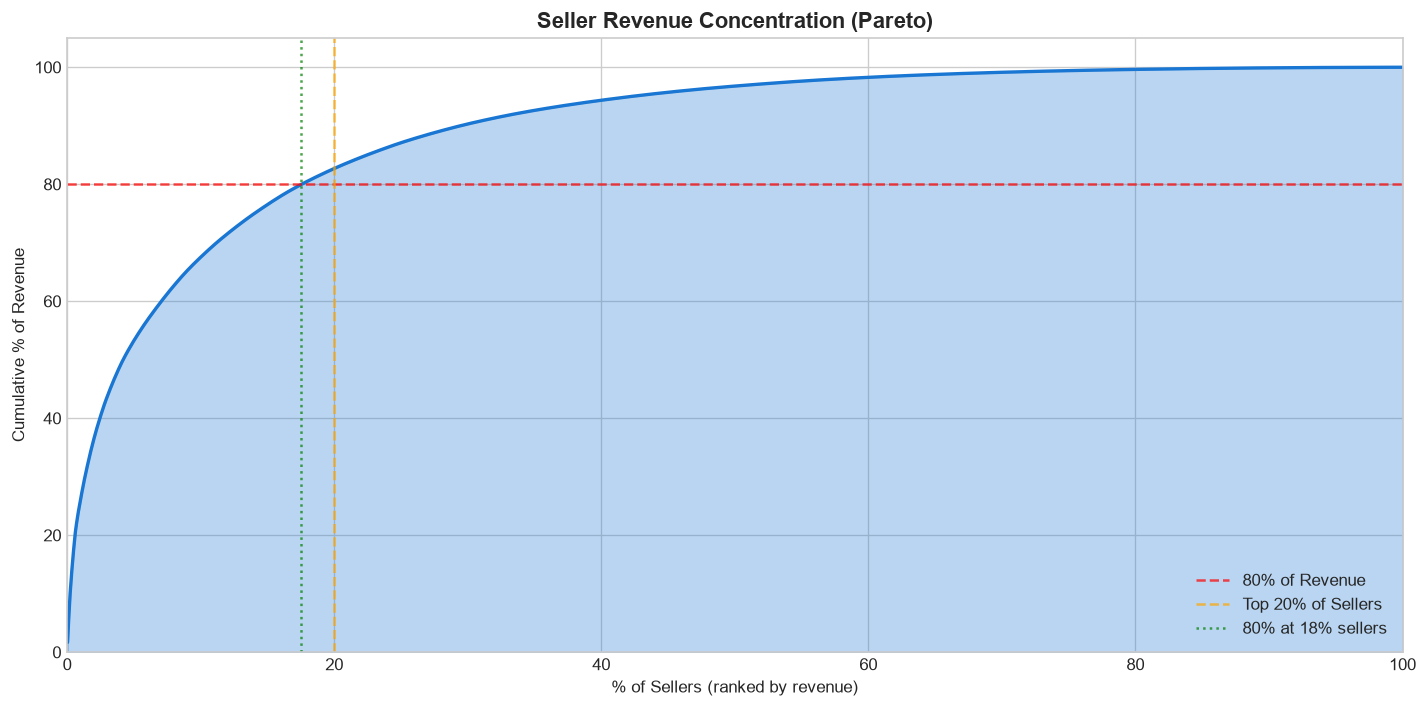

In [10]:
seller_perf = master.groupby('seller_id').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique'),
    items=('order_id', 'count'),
    avg_price=('price', 'mean'),
    state=('seller_state', 'first'),
).sort_values('revenue', ascending=False)

seller_perf['cumulative_pct'] = seller_perf['revenue'].cumsum() / seller_perf['revenue'].sum() * 100
seller_perf['seller_rank_pct'] = np.arange(1, len(seller_perf) + 1) / len(seller_perf) * 100

# NOTE (Task 3-6 consistency): the floor-based top-10% count here (309 sellers -> ~67.49%)
# differs slightly from the qcut-based D1 decile (310 sellers -> 67.56%) used in the
# SECTION 15 seller cells; both round to ~67.5% at headline precision. D1 is the primary reference.
top10_rev = seller_perf.head(int(len(seller_perf) * 0.1))['revenue'].sum() / seller_perf['revenue'].sum() * 100
bottom50_rev = seller_perf.tail(int(len(seller_perf) * 0.5))['revenue'].sum() / seller_perf['revenue'].sum() * 100

print(f'Active sellers: {len(seller_perf):,}')
print(f'Top 10% sellers -> {top10_rev:.1f}% of revenue')
print(f'Bottom 50% sellers -> {bottom50_rev:.1f}% of revenue')

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.fill_between(seller_perf['seller_rank_pct'], seller_perf['cumulative_pct'], alpha=0.3, color='#1976D2')
ax1.plot(seller_perf['seller_rank_pct'], seller_perf['cumulative_pct'], color='#1976D2', linewidth=2)
ax1.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% of Revenue')
ax1.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='Top 20% of Sellers')
pct80_sellers = seller_perf.loc[seller_perf['cumulative_pct'] <= 80, 'seller_rank_pct'].max()
ax1.axvline(x=pct80_sellers, color='green', linestyle=':', alpha=0.7, label=f'80% at {pct80_sellers:.0f}% sellers')
ax1.set_title('Seller Revenue Concentration (Pareto)', fontsize=13, fontweight='bold')
ax1.set_xlabel('% of Sellers (ranked by revenue)')
ax1.set_ylabel('Cumulative % of Revenue')
ax1.legend(loc='lower right')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 105)
save_chart(fig, '10_seller_pareto_curve')
plt.show()


## 10. Geography, same vs cross-state, distance (haversine)

SP dominates both sides of the marketplace. Cross-state and longer km correlate with slower delivery.


  Saved: outputs\charts\11_geographic_distribution.png


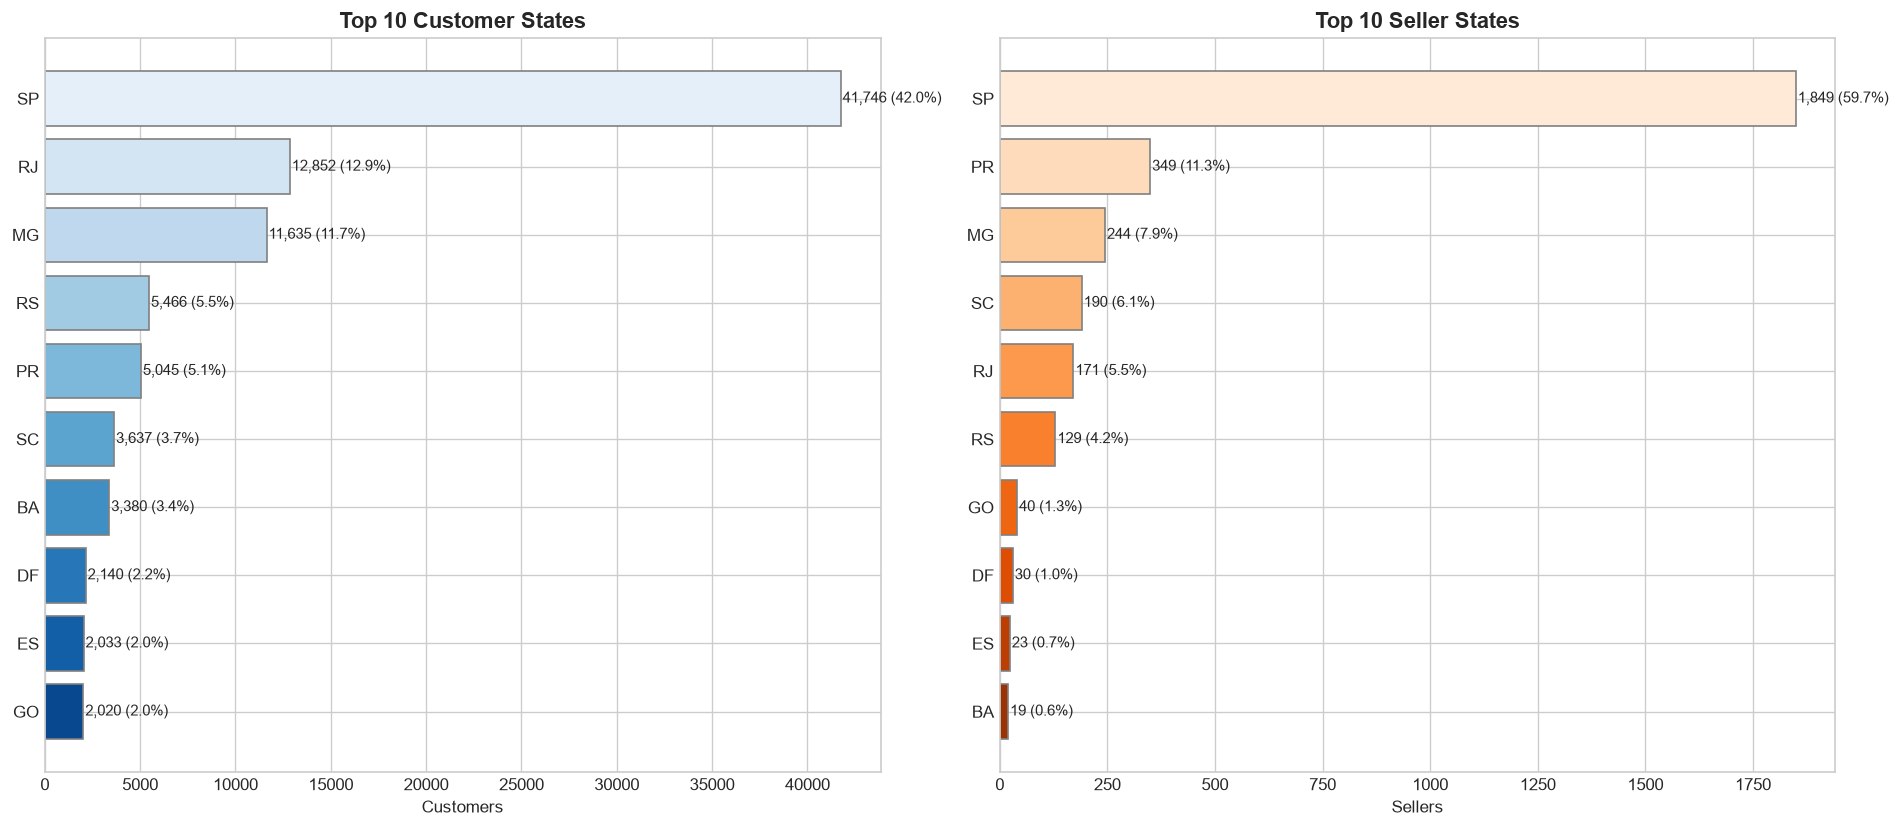

SP customers: 42.0%
SP sellers:   59.7%


Same-state avg delivery: 7.5 days
Cross-state avg delivery: 14.7 days
Cross-state penalty: +7.2 days


  Saved: outputs\charts\12_geography_delivery_freight.png


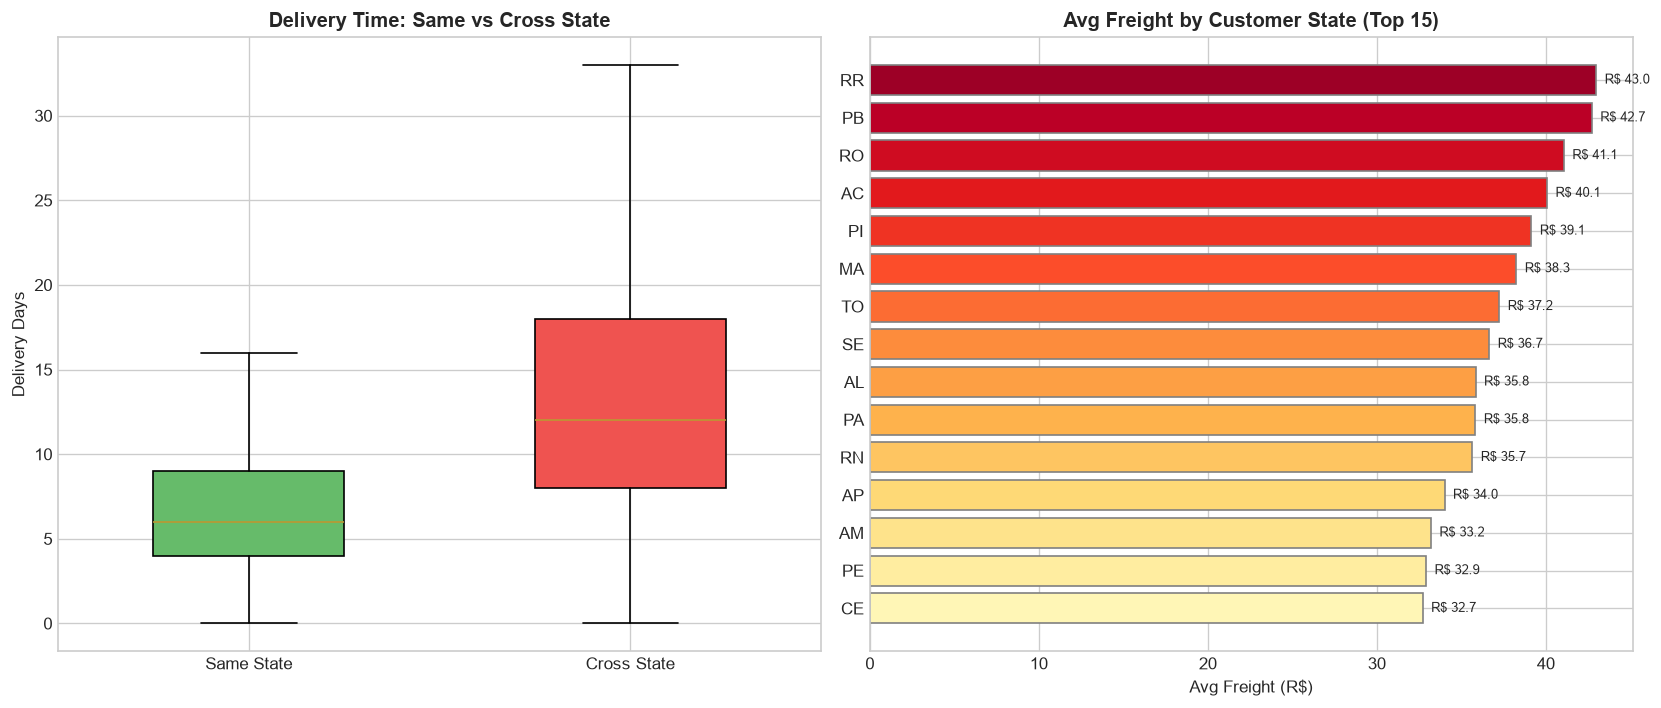

Distance coverage: 95,992 / 96,470 delivered orders
Median seller->customer distance: 434 km
Mean seller->customer distance: 601 km


  Saved: outputs\charts\16_distance_vs_delivery.png


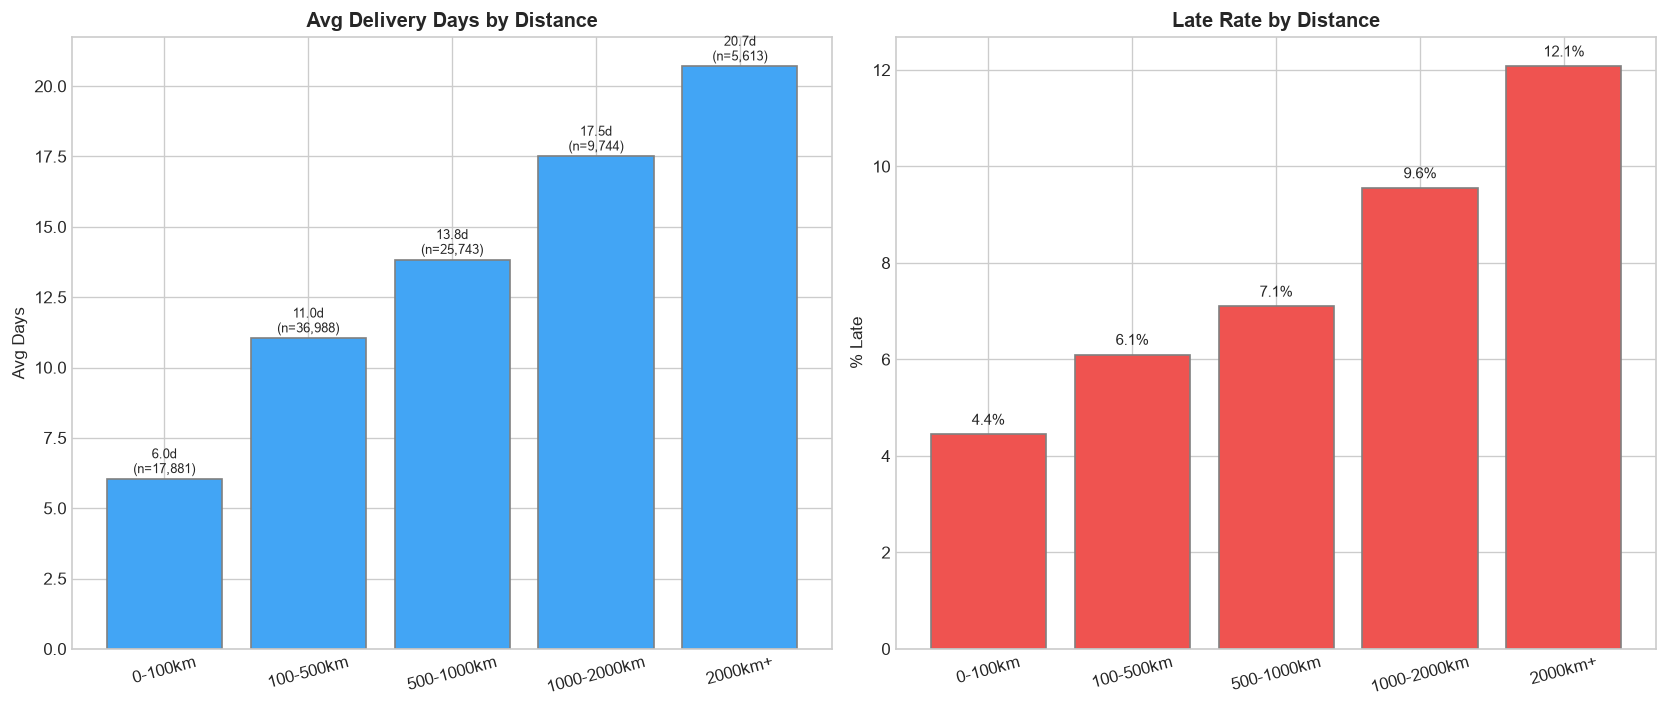

distance_km <-> actual_delivery_days: r = 0.394


In [11]:
cust_state = customers['customer_state'].value_counts().head(10)
sell_state = sellers['seller_state'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(cust_state.index[::-1], cust_state.values[::-1], color=sns.color_palette('Blues_r', 10), edgecolor='gray')
axes[0].set_title('Top 10 Customer States', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Customers')
for i, v in enumerate(cust_state.values[::-1]):
    axes[0].text(v + 100, i, f'{v:,} ({v / len(customers) * 100:.1f}%)', va='center', fontsize=9)

axes[1].barh(sell_state.index[::-1], sell_state.values[::-1], color=sns.color_palette('Oranges_r', 10), edgecolor='gray')
axes[1].set_title('Top 10 Seller States', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sellers')
for i, v in enumerate(sell_state.values[::-1]):
    axes[1].text(v + 5, i, f'{v:,} ({v / len(sellers) * 100:.1f}%)', va='center', fontsize=9)
save_chart(fig, '11_geographic_distribution')
plt.show()

print(f'SP customers: {cust_state["SP"] / len(customers) * 100:.1f}%')
print(f'SP sellers:   {sell_state["SP"] / len(sellers) * 100:.1f}%')

order_seller_state = (
    master.dropna(subset=['seller_state'])
    .sort_values('order_item_id')
    .groupby('order_id')['seller_state']
    .first()
    .reset_index()
)
orders_geo = orders_delivered.merge(order_seller_state, on='order_id', how='left')
orders_geo = orders_geo.dropna(subset=['customer_state', 'seller_state', 'actual_delivery_days'])
orders_geo['same_state'] = orders_geo['customer_state'] == orders_geo['seller_state']

same_state_delivery = orders_geo.loc[orders_geo['same_state'], 'actual_delivery_days'].mean()
cross_state_delivery = orders_geo.loc[~orders_geo['same_state'], 'actual_delivery_days'].mean()
print(f'Same-state avg delivery: {same_state_delivery:.1f} days')
print(f'Cross-state avg delivery: {cross_state_delivery:.1f} days')
print(f'Cross-state penalty: +{cross_state_delivery - same_state_delivery:.1f} days')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
data_ss = [
    orders_geo.loc[orders_geo['same_state'], 'actual_delivery_days'],
    orders_geo.loc[~orders_geo['same_state'], 'actual_delivery_days'],
]
bp = axes[0].boxplot(data_ss, tick_labels=['Same State', 'Cross State'], patch_artist=True, showfliers=False, widths=0.5)
bp['boxes'][0].set_facecolor('#66BB6A')
bp['boxes'][1].set_facecolor('#EF5350')
axes[0].set_title('Delivery Time: Same vs Cross State', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Delivery Days')

freight_by_state = master.groupby('customer_state')['freight_value'].mean().sort_values(ascending=False).head(15)
axes[1].barh(freight_by_state.index[::-1], freight_by_state.values[::-1], color=sns.color_palette('YlOrRd', 15), edgecolor='gray')
axes[1].set_title('Avg Freight by Customer State (Top 15)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Freight (R$)')
for i, v in enumerate(freight_by_state.values[::-1]):
    axes[1].text(v + 0.5, i, f'R$ {v:.1f}', va='center', fontsize=8)
save_chart(fig, '12_geography_delivery_freight')
plt.show()


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))


order_zips = (
    master.dropna(subset=['customer_zip_code_prefix', 'seller_zip_code_prefix'])
    .sort_values('order_item_id')
    .groupby('order_id')
    .agg(
        customer_zip=('customer_zip_code_prefix', 'first'),
        seller_zip=('seller_zip_code_prefix', 'first'),
    )
    .reset_index()
)
orders_dist = orders_delivered.merge(order_zips, on='order_id', how='inner')
orders_dist = (
    orders_dist
    .merge(
        geo_zip.rename(columns={'geolocation_zip_code_prefix': 'customer_zip', 'lat': 'cust_lat', 'lng': 'cust_lng'}),
        on='customer_zip', how='left',
    )
    .merge(
        geo_zip.rename(columns={'geolocation_zip_code_prefix': 'seller_zip', 'lat': 'sell_lat', 'lng': 'sell_lng'}),
        on='seller_zip', how='left',
    )
)
orders_dist = orders_dist.dropna(subset=['cust_lat', 'cust_lng', 'sell_lat', 'sell_lng'])
orders_dist['distance_km'] = haversine_km(
    orders_dist['cust_lat'].values, orders_dist['cust_lng'].values,
    orders_dist['sell_lat'].values, orders_dist['sell_lng'].values,
)

print(f'Distance coverage: {len(orders_dist):,} / {len(orders_delivered):,} delivered orders')
print(f'Median seller->customer distance: {orders_dist["distance_km"].median():.0f} km')
print(f'Mean seller->customer distance: {orders_dist["distance_km"].mean():.0f} km')

orders_dist['dist_bucket'] = pd.cut(
    orders_dist['distance_km'],
    bins=[0, 100, 500, 1000, 2000, 10000],
    labels=['0-100km', '100-500km', '500-1000km', '1000-2000km', '2000km+'],
)
dist_stats = orders_dist.groupby('dist_bucket', observed=True).agg(
    orders=('order_id', 'count'),
    avg_days=('actual_delivery_days', 'mean'),
    late_pct=('is_late', 'mean'),
)
dist_stats['late_pct'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].bar(dist_stats.index.astype(str), dist_stats['avg_days'], color='#42A5F5', edgecolor='gray')
axes[0].set_title('Avg Delivery Days by Distance', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Days')
axes[0].tick_params(axis='x', rotation=15)
for i, (_, row) in enumerate(dist_stats.iterrows()):
    axes[0].text(i, row['avg_days'] + 0.2, f'{row["avg_days"]:.1f}d\n(n={int(row["orders"]):,})', ha='center', fontsize=8)

axes[1].bar(dist_stats.index.astype(str), dist_stats['late_pct'], color='#EF5350', edgecolor='gray')
axes[1].set_title('Late Rate by Distance', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% Late')
axes[1].tick_params(axis='x', rotation=15)
for i, (_, row) in enumerate(dist_stats.iterrows()):
    axes[1].text(i, row['late_pct'] + 0.2, f'{row["late_pct"]:.1f}%', ha='center', fontsize=9)
# Chart 16 lives here (not after 15): distance analysis reuses this section's geo centroids.
save_chart(fig, '16_distance_vs_delivery')
plt.show()

corr_dist_days = orders_dist[['distance_km', 'actual_delivery_days']].corr().iloc[0, 1]
print(f'distance_km <-> actual_delivery_days: r = {corr_dist_days:.3f}')


## 11. Freight ratio & weight vs freight


  Saved: outputs\charts\13_freight_ratio_by_category.png


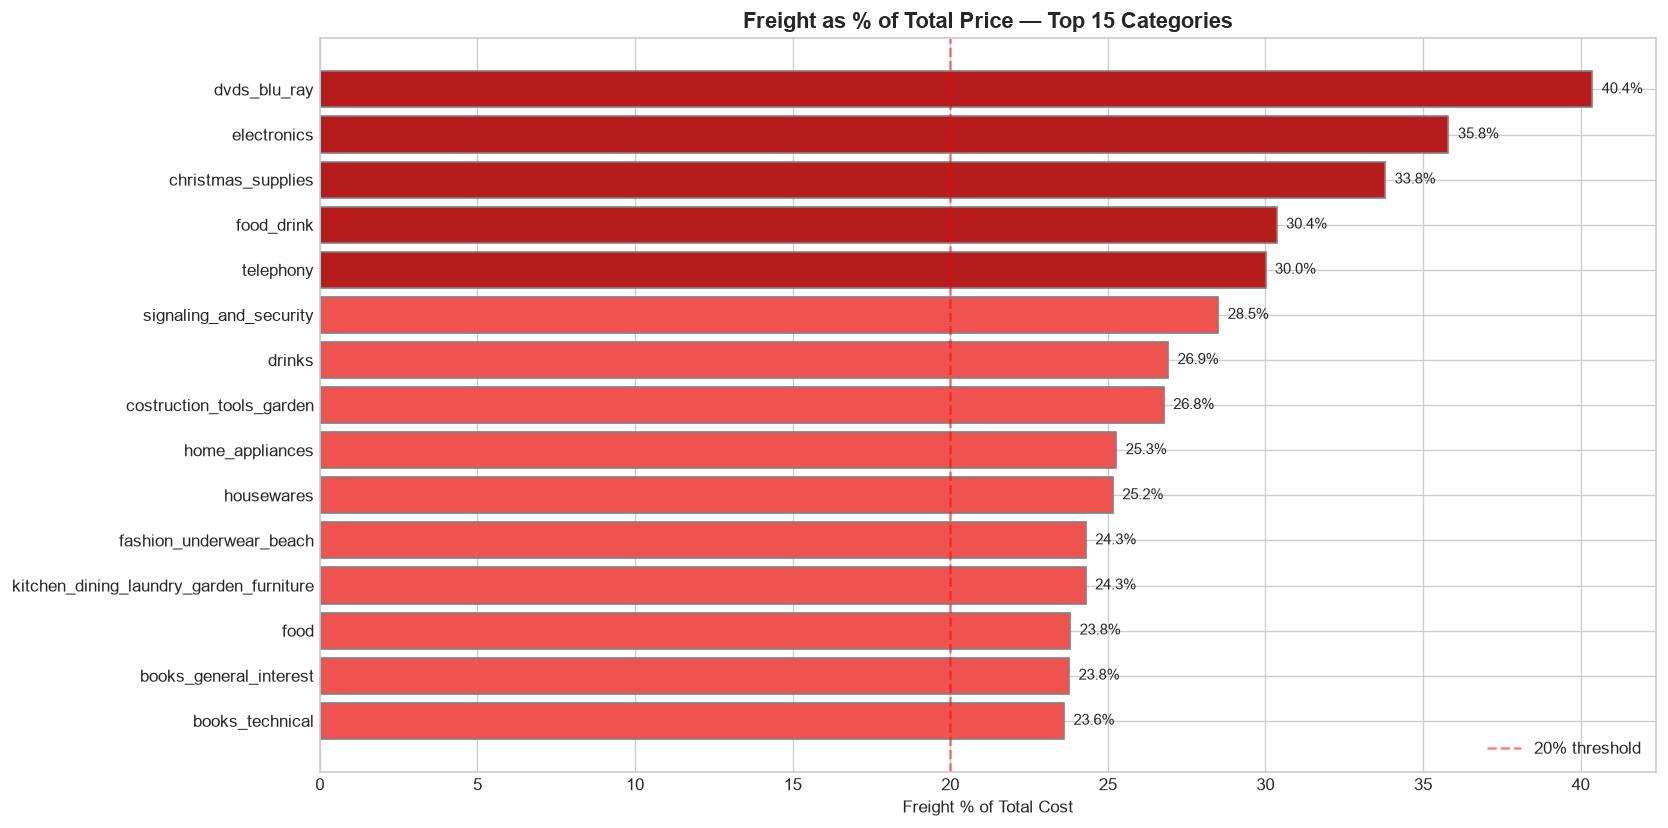

Overall avg freight ratio: 21.3%
Worst category: dvds_blu_ray (40.4%)
product_weight_g <-> freight_value: r = 0.610


  Saved: outputs\charts\17_weight_vs_freight.png


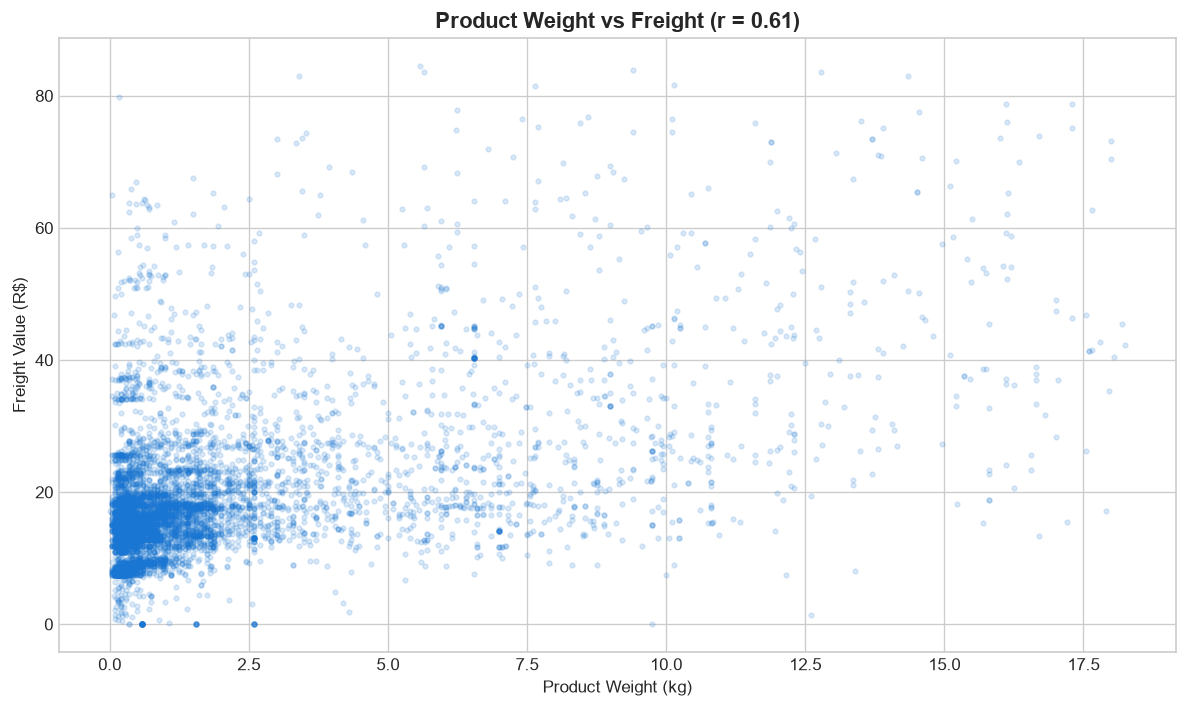

In [12]:
master['freight_ratio'] = np.where(
    (master['price'] + master['freight_value']) > 0,
    master['freight_value'] / (master['price'] + master['freight_value']) * 100,
    np.nan,
)

ftr_by_cat = master.groupby('product_category_name_english').agg(
    avg_freight_ratio=('freight_ratio', 'mean'),
    total_orders=('order_id', 'nunique'),
).sort_values('avg_freight_ratio', ascending=False)
ftr_by_cat = ftr_by_cat[ftr_by_cat['total_orders'] >= 50].head(15)

fig, ax = plt.subplots(figsize=(14, 7))
colors_ftr = ['#B71C1C' if x > 30 else '#EF5350' if x > 20 else '#FFA726' for x in ftr_by_cat['avg_freight_ratio']]
ax.barh(ftr_by_cat.index[::-1], ftr_by_cat['avg_freight_ratio'].values[::-1], color=colors_ftr[::-1], edgecolor='gray')
ax.set_title('Freight as % of Total Price — Top 15 Categories', fontsize=13, fontweight='bold')
ax.set_xlabel('Freight % of Total Cost')
ax.axvline(x=20, color='red', linestyle='--', alpha=0.5, label='20% threshold')
ax.legend()
for i, v in enumerate(ftr_by_cat['avg_freight_ratio'].values[::-1]):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
save_chart(fig, '13_freight_ratio_by_category')
plt.show()

overall_ftr = master['freight_ratio'].mean()
print(f'Overall avg freight ratio: {overall_ftr:.1f}%')
print(f'Worst category: {ftr_by_cat.index[0]} ({ftr_by_cat["avg_freight_ratio"].iloc[0]:.1f}%)')

weight_freight = master[['product_weight_g', 'freight_value']].dropna()
weight_freight = weight_freight[(weight_freight['product_weight_g'] > 0) & (weight_freight['freight_value'] >= 0)]
wf_plot = weight_freight[
    (weight_freight['product_weight_g'] <= weight_freight['product_weight_g'].quantile(0.99))
    & (weight_freight['freight_value'] <= weight_freight['freight_value'].quantile(0.99))
].sample(n=min(8000, len(weight_freight)), random_state=42)

corr_wf = weight_freight['product_weight_g'].corr(weight_freight['freight_value'])
print(f'product_weight_g <-> freight_value: r = {corr_wf:.3f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(wf_plot['product_weight_g'] / 1000, wf_plot['freight_value'], alpha=0.15, s=8, color='#1976D2')
ax.set_title(f'Product Weight vs Freight (r = {corr_wf:.2f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Product Weight (kg)')
ax.set_ylabel('Freight Value (R$)')
# Chart 17 lives here (not after 16): weight-freight analysis belongs to this freight-ratio block.
save_chart(fig, '17_weight_vs_freight')
plt.show()


## 12. Order status & cancellations


In [13]:
status_dist = orders['order_status'].value_counts()
for status, count in status_dist.items():
    print(f'{status}: {count:,} ({count / len(orders) * 100:.2f}%)')

cancel_rate = orders['order_status'].isin(['canceled', 'unavailable']).mean() * 100
print(f'\nCombined cancel/unavailable rate: {cancel_rate:.2f}%')


delivered: 96,478 (97.02%)
shipped: 1,107 (1.11%)
canceled: 625 (0.63%)
unavailable: 609 (0.61%)
invoiced: 314 (0.32%)
processing: 301 (0.30%)
created: 5 (0.01%)
approved: 2 (0.00%)

Combined cancel/unavailable rate: 1.24%


## 13. Monthly revenue & AOV


  Saved: outputs\charts\14_monthly_revenue_trend.png


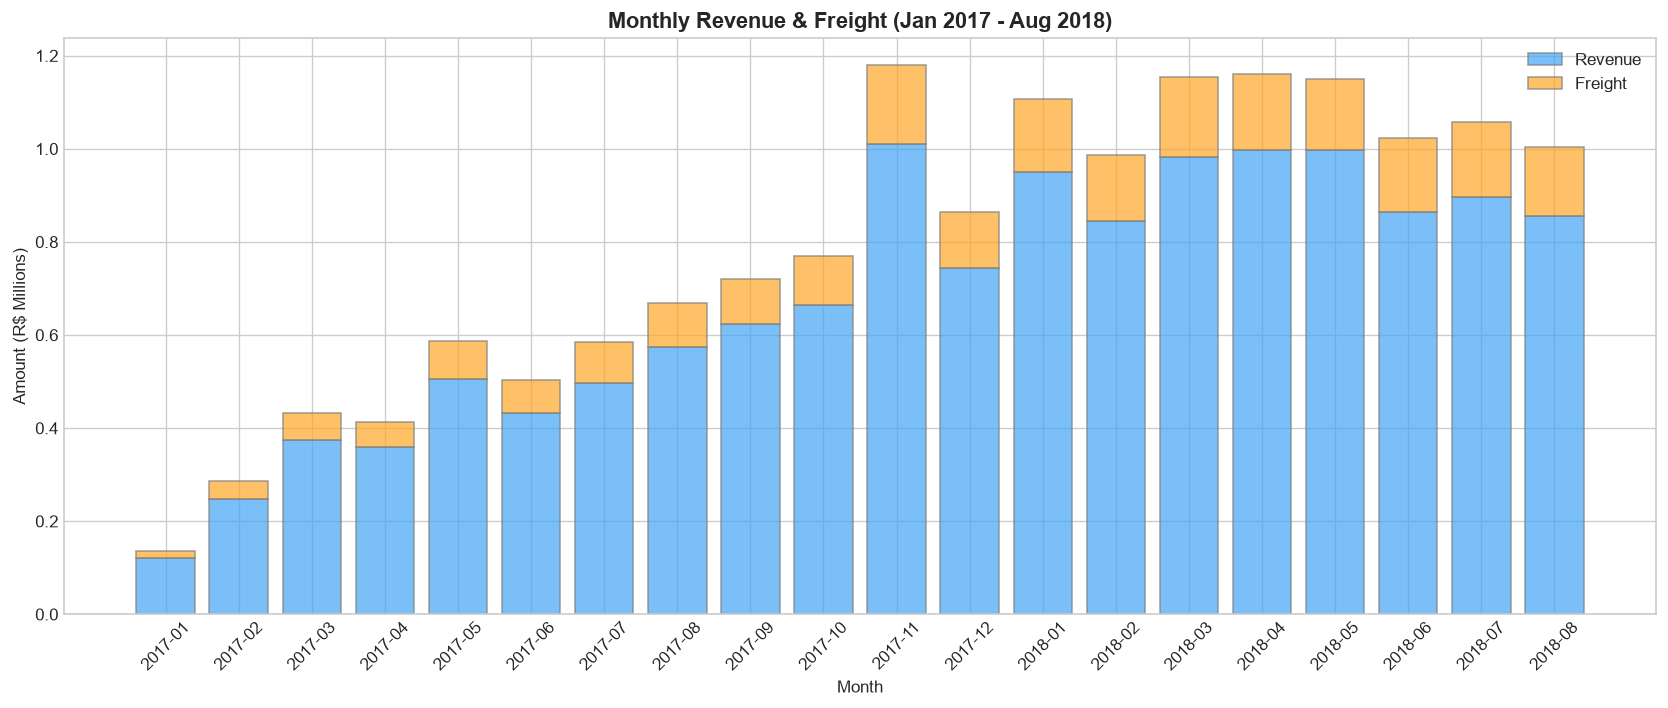

                            revenue  orders         aov
order_purchase_timestamp                               
2018-04                   996647.75    6934  143.733451
2018-05                   996517.68    6853  145.413349
2018-06                   865124.31    6160  140.442258
2018-07                   895507.22    6273  142.755814
2018-08                   854686.33    6452  132.468433


In [14]:
monthly_rev = master[
    (master['order_purchase_timestamp'] >= '2017-01-01')
    & (master['order_purchase_timestamp'] < '2018-09-01')
]
monthly_rev = monthly_rev.groupby(monthly_rev['order_purchase_timestamp'].dt.to_period('M')).agg(
    revenue=('price', 'sum'),
    freight=('freight_value', 'sum'),
    orders=('order_id', 'nunique'),
)
monthly_rev['aov'] = monthly_rev['revenue'] / monthly_rev['orders']

fig, ax1 = plt.subplots(figsize=(14, 6))
rev_months_str = [str(m) for m in monthly_rev.index]
ax1.bar(rev_months_str, monthly_rev['revenue'] / 1e6, color='#42A5F5', alpha=0.7, label='Revenue', edgecolor='gray')
ax1.bar(
    rev_months_str, monthly_rev['freight'] / 1e6, bottom=monthly_rev['revenue'] / 1e6,
    color='#FFA726', alpha=0.7, label='Freight', edgecolor='gray',
)
ax1.set_title('Monthly Revenue & Freight (Jan 2017 - Aug 2018)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Amount (R$ Millions)')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
save_chart(fig, '14_monthly_revenue_trend')
plt.show()

print(monthly_rev[['revenue', 'orders', 'aov']].tail())


## 14. Correlation: what moves review scores?

Order-level financials + delivery fields — avoids multi-item bias.


  Saved: outputs\charts\15_correlation_heatmap.png


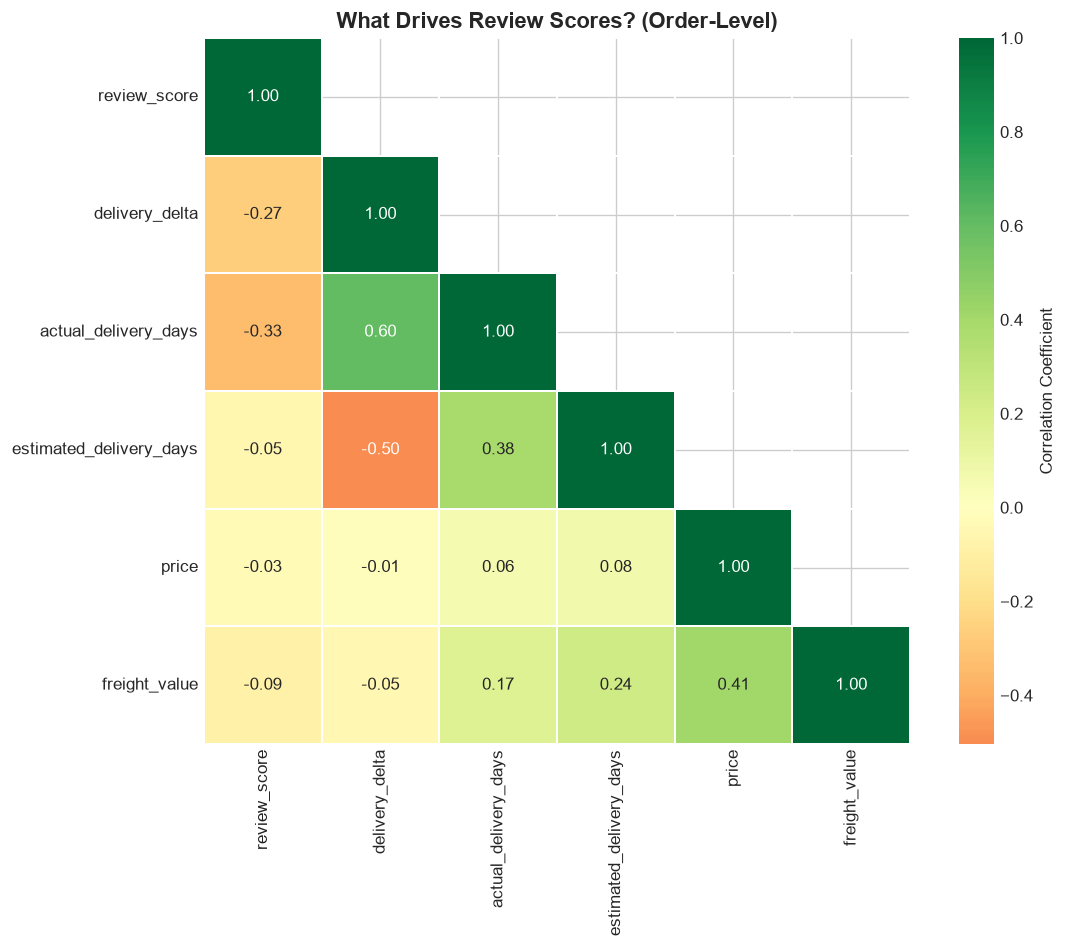

delivery_delta <-> review_score: r = -0.267
actual_delivery_days <-> review_score: r = -0.334
freight_value <-> review_score: r = -0.090


In [15]:
corr_data = orders_reviews[[
    'review_score', 'delivery_delta', 'actual_delivery_days',
    'estimated_delivery_days', 'order_price', 'order_freight',
]].dropna()

corr_matrix = corr_data.rename(
    columns={'order_price': 'price', 'order_freight': 'freight_value'}
).corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f',
    mask=mask, square=True, linewidths=1, ax=ax,
    cbar_kws={'label': 'Correlation Coefficient'},
)
ax.set_title('What Drives Review Scores? (Order-Level)', fontsize=13, fontweight='bold')
save_chart(fig, '15_correlation_heatmap')
plt.show()

print(f'delivery_delta <-> review_score: r = {corr_matrix.loc["review_score", "delivery_delta"]:.3f}')
print(f'actual_delivery_days <-> review_score: r = {corr_matrix.loc["review_score", "actual_delivery_days"]:.3f}')
print(f'freight_value <-> review_score: r = {corr_matrix.loc["review_score", "freight_value"]:.3f}')


## SECTION 14: Delivery Decomposition (Task 2)

Order-level stage times on the **locked delivered base**. Late rule unchanged: `is_late = delivery_delta > 0` (`docs/01-definitions.md`).

Primary table = **full-chain** (approval + carrier + customer + ETA). Negatives flagged, not dropped; headline stats on **≥ 0**. Chart display may clip; stats are unclipped / not winsorized.

Outputs: `outputs/tables/delivery_decomposition.csv`, `outputs/charts/19_delivery_stage_breakdown.png`, `docs/02-delivery-decomposition.md`.


Delivered base: 96,470
Full-chain primary n: 96,455
Stage-wise usable — approval/handoff/transit: 96,456 / 96,455 / 96,469
Negatives (full-chain): handoff=1,350 (1.40%), transit=23 (0.024%)
Headline medians (>=0): approval=0.34h | handoff=44.38h | transit=7.10d | total=10d
t_total_d reconciles with actual_delivery_days: True
Saved: outputs\tables\delivery_decomposition.csv


,stage,n_fullchain,n_stage,n_negative,pct_negative,median,mean,p90,sd,units,n_ge0_stats,full_sample_median
0,approval,96455,96456,0,0.0000,0.343333,10.277702,34.595000,20.536149,hours,96455,0.343333
1,handoff,96455,96455,1350,1.3996,44.377222,68.481390,144.553333,83.652306,hours,95105,43.579444
2,transit,96455,96469,23,0.0238,7.100156,9.333412,18.902266,8.759206,days,96432,7.099699
3,total,96455,96470,0,0.0000,10.000000,12.093100,23.000000,9.551209,days,96455,10.000000


Late vs on-time medians (>=0, full-chain) — correlational only:
  approval (hours): on-time=0.34 | late=0.41 | delta=0.07 | late_share=6.77%
  handoff (hours): on-time=43.02 | late=73.60 | delta=30.57 | late_share=6.84%
  transit (days): on-time=6.95 | late=26.20 | delta=19.25 | late_share=6.77%
  total (days): on-time=9.00 | late=31.00 | delta=22.00 | late_share=6.77%


  Saved: outputs\charts\19_delivery_stage_breakdown.png


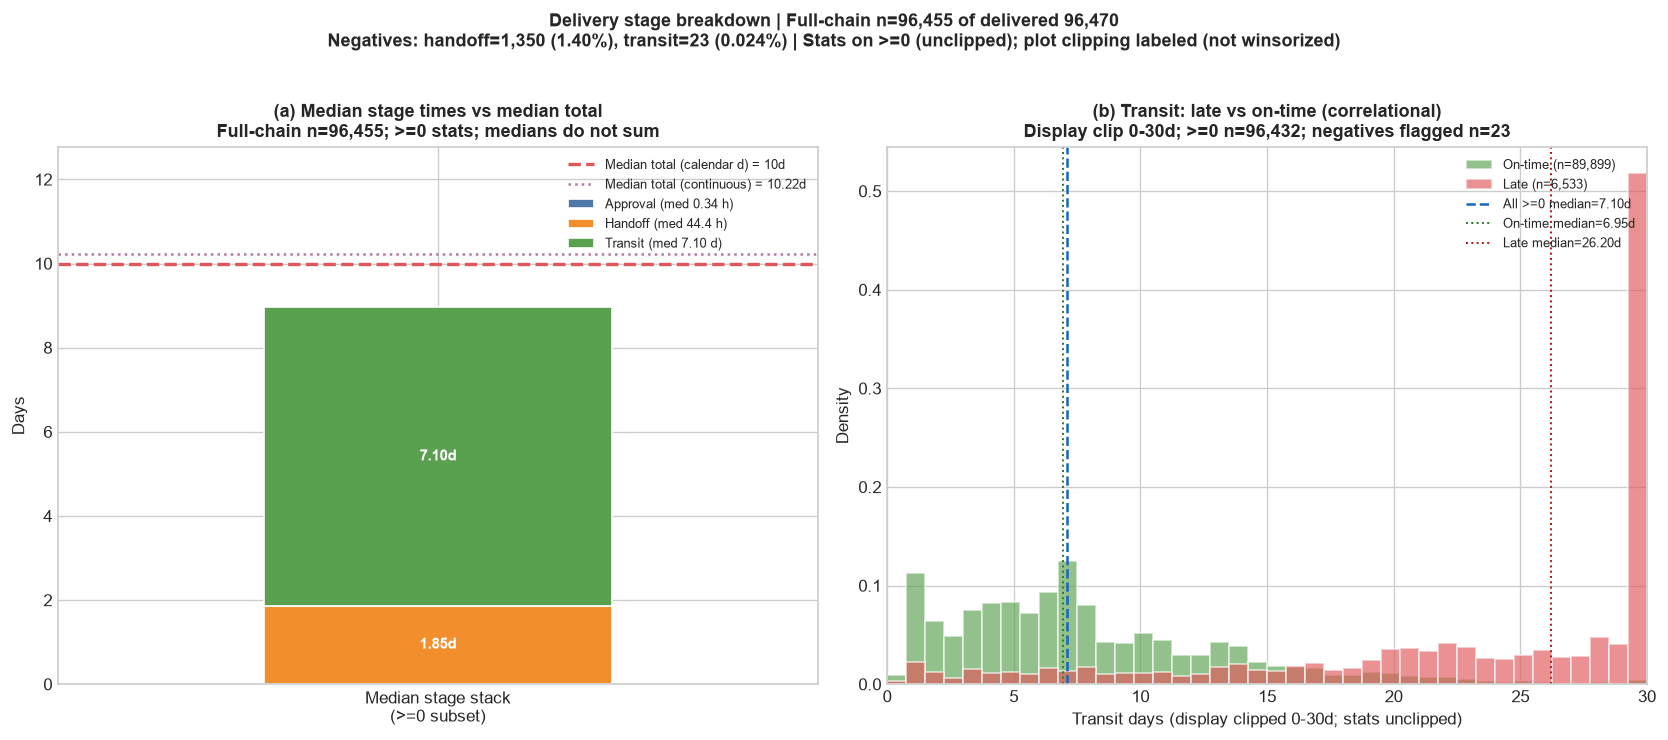

P1 link (descriptive only): transit median dominates total; handoff has widest p90; late orders show much longer transit median vs on-time — no causal claim.


In [16]:
# SECTION 14: DELIVERY DECOMPOSITION — mirrors notebooks/olist_full_eda.py
# Locked late rule / delivered base from earlier cells — do NOT redefine.

TABLES_PATH = ROOT / 'outputs' / 'tables'
TABLES_PATH.mkdir(parents=True, exist_ok=True)

_od = orders_delivered.copy()
_od['t_approval_h'] = (
    _od['order_approved_at'] - _od['order_purchase_timestamp']
).dt.total_seconds() / 3600.0
_od['t_handoff_h'] = (
    _od['order_delivered_carrier_date'] - _od['order_approved_at']
).dt.total_seconds() / 3600.0
_od['t_transit_h'] = (
    _od['order_delivered_customer_date'] - _od['order_delivered_carrier_date']
).dt.total_seconds() / 3600.0
_od['t_transit_d'] = _od['t_transit_h'] / 24.0
_od['t_total_d'] = _od['actual_delivery_days']  # reconcile with existing field
_od['t_total_d_continuous'] = (
    _od['order_delivered_customer_date'] - _od['order_purchase_timestamp']
).dt.total_seconds() / 86400.0

n_stage_approval = int(_od['t_approval_h'].notna().sum())
n_stage_handoff = int(_od['t_handoff_h'].notna().sum())
n_stage_transit = int(_od['t_transit_d'].notna().sum())
n_stage_total = int(_od['t_total_d'].notna().sum())

_fc_mask = _od[[
    'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date',
]].notna().all(axis=1)
fc_decomp = _od[_fc_mask].copy()
n_fullchain = len(fc_decomp)

neg_handoff = int((fc_decomp['t_handoff_h'] < 0).sum())
neg_transit = int((fc_decomp['t_transit_d'] < 0).sum())
neg_approval = int((fc_decomp['t_approval_h'] < 0).sum())
neg_total = int((fc_decomp['t_total_d'] < 0).sum())


def _decomp_stats(series):
    full = series.dropna()
    ge0 = full[full >= 0]
    return {
        'n_ge0': len(ge0),
        'median': float(ge0.median()) if len(ge0) else np.nan,
        'mean': float(ge0.mean()) if len(ge0) else np.nan,
        'p90': float(ge0.quantile(0.9)) if len(ge0) else np.nan,
        'sd': float(ge0.std()) if len(ge0) else np.nan,
        'full_sample_median': float(full.median()) if len(full) else np.nan,
    }


_stages = [
    ('approval', 't_approval_h', 'hours', n_stage_approval, neg_approval),
    ('handoff', 't_handoff_h', 'hours', n_stage_handoff, neg_handoff),
    ('transit', 't_transit_d', 'days', n_stage_transit, neg_transit),
    ('total', 't_total_d', 'days', n_stage_total, neg_total),
]

_decomp_rows = []
_stats = {}
for _stage, _col, _units, _n_stage, _n_neg in _stages:
    _st = _decomp_stats(fc_decomp[_col])
    _stats[_stage] = _st
    _decomp_rows.append({
        'stage': _stage,
        'n_fullchain': n_fullchain,
        'n_stage': _n_stage,
        'n_negative': _n_neg,
        'pct_negative': round(100.0 * _n_neg / n_fullchain, 4),
        'median': round(_st['median'], 6),
        'mean': round(_st['mean'], 6),
        'p90': round(_st['p90'], 6),
        'sd': round(_st['sd'], 6),
        'units': _units,
        'n_ge0_stats': _st['n_ge0'],
        'full_sample_median': round(_st['full_sample_median'], 6),
    })

decomp_table = pd.DataFrame(_decomp_rows)
decomp_csv = TABLES_PATH / 'delivery_decomposition.csv'
decomp_table.to_csv(decomp_csv, index=False)

print(f'Delivered base: {len(orders_delivered):,}')
print(f'Full-chain primary n: {n_fullchain:,}')
print(
    f'Stage-wise usable — approval/handoff/transit: '
    f'{n_stage_approval:,} / {n_stage_handoff:,} / {n_stage_transit:,}'
)
print(
    f'Negatives (full-chain): handoff={neg_handoff:,} '
    f'({100 * neg_handoff / n_fullchain:.2f}%), '
    f'transit={neg_transit:,} ({100 * neg_transit / n_fullchain:.3f}%)'
)
print(
    f'Headline medians (>=0): approval={_stats["approval"]["median"]:.2f}h | '
    f'handoff={_stats["handoff"]["median"]:.2f}h | '
    f'transit={_stats["transit"]["median"]:.2f}d | '
    f'total={_stats["total"]["median"]:.0f}d'
)
print(
    f't_total_d reconciles with actual_delivery_days: '
    f'{(fc_decomp["t_total_d"] == fc_decomp["actual_delivery_days"]).all()}'
)
print(f'Saved: {decomp_csv.relative_to(ROOT)}')
try:
    display(decomp_table)
except NameError:
    print(decomp_table.to_string(index=False))

print('Late vs on-time medians (>=0, full-chain) — correlational only:')
for _stage, _col, _units, _, _ in _stages:
    _ge0 = fc_decomp[fc_decomp[_col] >= 0]
    _late_med = _ge0.loc[_ge0['is_late'], _col].median()
    _ontime_med = _ge0.loc[~_ge0['is_late'], _col].median()
    _share = _ge0['is_late'].mean() * 100
    print(
        f'  {_stage} ({_units}): on-time={_ontime_med:.2f} | late={_late_med:.2f} | '
        f'delta={_late_med - _ontime_med:.2f} | late_share={_share:.2f}%'
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

med_a_d = _stats['approval']['median'] / 24.0
med_h_d = _stats['handoff']['median'] / 24.0
med_t_d = _stats['transit']['median']
med_tot = _stats['total']['median']
med_tot_cont = float(
    fc_decomp.loc[fc_decomp['t_total_d_continuous'] >= 0, 't_total_d_continuous'].median()
)

ax = axes[0]
_colors = ['#4E79A7', '#F28E2B', '#59A14F']
_labels = [
    f'Approval (med {_stats["approval"]["median"]:.2f} h)',
    f'Handoff (med {_stats["handoff"]["median"]:.1f} h)',
    f'Transit (med {med_t_d:.2f} d)',
]
_bottom = 0.0
for _v, _c, _lab in zip([med_a_d, med_h_d, med_t_d], _colors, _labels):
    ax.bar(0, _v, bottom=_bottom, color=_c, edgecolor='white', width=0.55, label=_lab)
    if _v >= 0.05:
        ax.text(
            0, _bottom + _v / 2, f'{_v:.2f}d', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold',
        )
    _bottom += _v
ax.axhline(
    med_tot, color='#E15759', linestyle='--', linewidth=2,
    label=f'Median total (calendar d) = {med_tot:.0f}d',
)
ax.axhline(
    med_tot_cont, color='#B07AA1', linestyle=':', linewidth=1.5,
    label=f'Median total (continuous) = {med_tot_cont:.2f}d',
)
ax.set_xlim(-0.6, 0.6)
ax.set_xticks([0])
ax.set_xticklabels(['Median stage stack\n(>=0 subset)'])
ax.set_ylabel('Days')
ax.set_title(
    f'(a) Median stage times vs median total\n'
    f'Full-chain n={n_fullchain:,}; >=0 stats; medians do not sum',
    fontsize=11, fontweight='bold',
)
ax.legend(loc='upper right', fontsize=8, framealpha=0.95)
ax.set_ylim(0, max(_bottom, med_tot_cont) * 1.25)

ax = axes[1]
_transit_ge0 = fc_decomp.loc[fc_decomp['t_transit_d'] >= 0, ['t_transit_d', 'is_late']]
_late_v = _transit_ge0.loc[_transit_ge0['is_late'], 't_transit_d'].clip(0, 30)
_ontime_v = _transit_ge0.loc[~_transit_ge0['is_late'], 't_transit_d'].clip(0, 30)
ax.hist(
    _ontime_v, bins=40, alpha=0.65, color='#59A14F', edgecolor='white', density=True,
    label=f'On-time (n={(~_transit_ge0["is_late"]).sum():,})',
)
ax.hist(
    _late_v, bins=40, alpha=0.65, color='#E15759', edgecolor='white', density=True,
    label=f'Late (n={_transit_ge0["is_late"].sum():,})',
)
_late_med_t = float(_transit_ge0.loc[_transit_ge0['is_late'], 't_transit_d'].median())
_ontime_med_t = float(_transit_ge0.loc[~_transit_ge0['is_late'], 't_transit_d'].median())
ax.axvline(
    _stats['transit']['median'], color='#1565C0', linestyle='--', linewidth=1.5,
    label=f'All >=0 median={_stats["transit"]["median"]:.2f}d',
)
ax.axvline(
    _ontime_med_t, color='#2E7D32', linestyle=':', linewidth=1.2,
    label=f'On-time median={_ontime_med_t:.2f}d',
)
ax.axvline(
    _late_med_t, color='#B71C1C', linestyle=':', linewidth=1.2,
    label=f'Late median={_late_med_t:.2f}d',
)
ax.set_xlim(0, 30)
ax.set_xlabel('Transit days (display clipped 0-30d; stats unclipped)')
ax.set_ylabel('Density')
ax.set_title(
    f'(b) Transit: late vs on-time (correlational)\n'
    f'Display clip 0-30d; >=0 n={_stats["transit"]["n_ge0"]:,}; '
    f'negatives flagged n={neg_transit}',
    fontsize=11, fontweight='bold',
)
ax.legend(loc='upper right', fontsize=8)

fig.suptitle(
    f'Delivery stage breakdown | Full-chain n={n_fullchain:,} of delivered {len(orders_delivered):,}\n'
    f'Negatives: handoff={neg_handoff:,} ({100 * neg_handoff / n_fullchain:.2f}%), '
    f'transit={neg_transit:,} ({100 * neg_transit / n_fullchain:.3f}%) | '
    f'Stats on >=0 (unclipped); plot clipping labeled (not winsorized)',
    fontsize=11, fontweight='bold', y=1.02,
)
save_chart(fig, '19_delivery_stage_breakdown')
plt.show()

print(
    'P1 link (descriptive only): transit median dominates total; '
    'handoff has widest p90; late orders show much longer transit median vs on-time — '
    'no causal claim.'
)


## SECTION 15: Seller Concentration of Risk (Task 3)

Seller-grain revenue ranking on locked `SUM(price)`; delivered seller–order pairs on the locked delivered base. Late rule unchanged: `is_late = delivery_delta > 0` (`docs/01-definitions.md`).

Deciles on all 3,095 sellers (D1 = top). Operational headlines: `seller_delivered_orders >= 10`. Outputs: `outputs/tables/seller_level.csv`, `seller_decile_summary.csv`, `outputs/charts/20_seller_risk.png`, `docs/03-seller-risk.md`.



SECTION 15: SELLER CONCENTRATION OF RISK (SELLER GRAIN)


  Sellers (revenue base): 3,095
  Zero-delivered sellers (isolated count): 125
  Seller–order pairs (delivered): 97,811 (order-level delivered base still 96,470)
  Reviewed delivered orders (deduped join): 95,824
  Locked Pareto: top 10% → 67.5% revenue; bottom 50% → 3.2% revenue
  Operational >=10 coverage: n=1,237 (40.0% sellers); 93.9% seller–order volume; 90.2% revenue
  Appendix median late rate: >=10 5.43% (IQR 7.58pp); >=5 4.47%; >=1 0.00%
  Top-30 by late-order volume: 1,968 late seller–orders (30.1% of seller-grain late flags)
  Saved: outputs\tables\seller_level.csv
  Saved: outputs\tables\seller_decile_summary.csv


  Saved: outputs\charts\20_seller_risk.png
  P1 link (descriptive only): late flags concentrate with revenue in top deciles while low-volume bands show wide seller late-rate spread; no claim that sellers cause review loss.


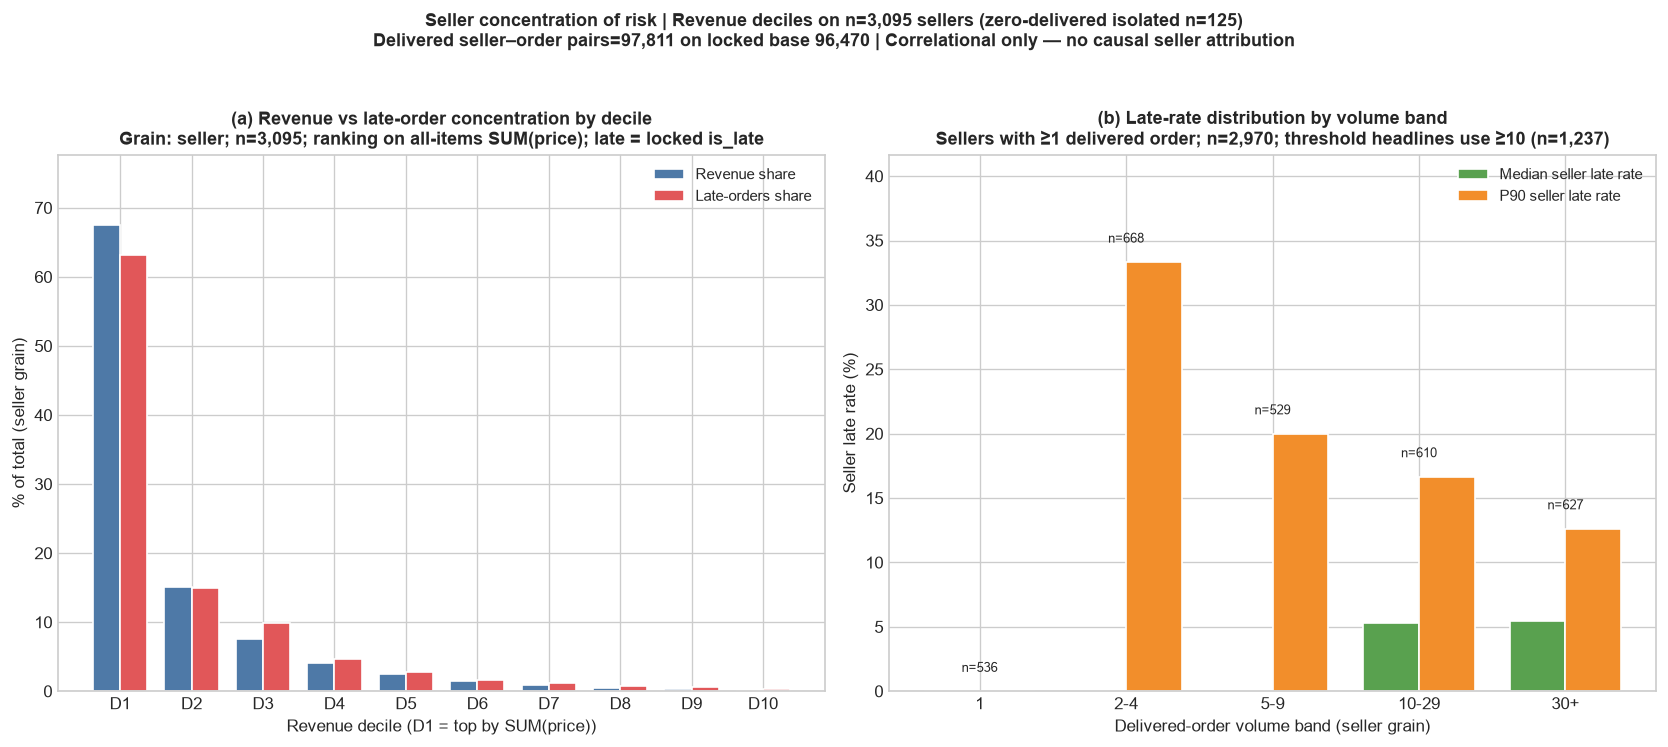

In [17]:
# SECTION 15: SELLER CONCENTRATION OF RISK — mirrors notebooks/olist_full_eda.py
# Locked late rule / delivered base / revenue base from earlier cells. Do NOT redefine late.

# ══════════════════════════════════════════════════════════════════════════
# SECTION 15: SELLER CONCENTRATION OF RISK (Task 3 — append-only; locked late rule)
# ══════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('SECTION 15: SELLER CONCENTRATION OF RISK (SELLER GRAIN)')
print('='*70)

TABLES_PATH = ROOT / 'outputs' / 'tables'
TABLES_PATH.mkdir(parents=True, exist_ok=True)

# --- Seller revenue (ALL items; locked REVENUE_BASE for ranking/deciles) ---
# Grain: seller_id. Formula: SUM(price). Does NOT redefine late.
_seller_rev = (
    items.groupby('seller_id', as_index=False)
    .agg(seller_revenue=('price', 'sum'), seller_items=('order_id', 'count'))
)

# --- Delivered seller–order pairs (items → locked delivered base) ---
# Multi-seller order counts once per involved seller; is_late reused as-is.
_so_pairs = (
    items[['order_id', 'seller_id']]
    .merge(orders_delivered[['order_id', 'is_late']], on='order_id', how='inner')
    .drop_duplicates(['seller_id', 'order_id'])
)

_seller_deliv = (
    _so_pairs.groupby('seller_id', as_index=False)
    .agg(
        seller_delivered_orders=('order_id', 'nunique'),
        seller_late_orders=('is_late', 'sum'),
    )
)
_seller_deliv['seller_late_rate'] = (
    _seller_deliv['seller_late_orders'] / _seller_deliv['seller_delivered_orders']
)

# Reviews: deduped order-level join; reviewed-only denominator (same pattern as SECTION 5)
_order_reviews_dedup = reviews[['order_id', 'review_score']].drop_duplicates(subset='order_id')
_so_rev = _so_pairs.merge(_order_reviews_dedup, on='order_id', how='inner')
_seller_revw = (
    _so_rev.groupby('seller_id', as_index=False)
    .agg(
        seller_avg_review=('review_score', 'mean'),
        seller_review_n=('review_score', 'count'),
        _n_1star=('review_score', lambda s: int((s == 1).sum())),
    )
)
_seller_revw['seller_1star_rate'] = (
    _seller_revw['_n_1star'] / _seller_revw['seller_review_n']
)
_seller_revw = _seller_revw.drop(columns=['_n_1star'])

seller_level = (
    _seller_rev
    .merge(_seller_deliv, on='seller_id', how='left')
    .merge(_seller_revw, on='seller_id', how='left')
)
seller_level['seller_delivered_orders'] = (
    seller_level['seller_delivered_orders'].fillna(0).astype(int)
)
seller_level['seller_late_orders'] = (
    seller_level['seller_late_orders'].fillna(0).astype(int)
)
seller_level['seller_review_n'] = (
    seller_level['seller_review_n'].fillna(0).astype(int)
)
# Undefined late rate when zero delivered
seller_level.loc[
    seller_level['seller_delivered_orders'] == 0, 'seller_late_rate'
] = np.nan

n_sellers = len(seller_level)
n_zero_delivered = int((seller_level['seller_delivered_orders'] == 0).sum())
total_seller_revenue = float(seller_level['seller_revenue'].sum())
total_seller_del_orders = int(seller_level['seller_delivered_orders'].sum())
total_seller_late_orders = int(seller_level['seller_late_orders'].sum())

# Locked Pareto shares (equal to SECTION 8 / 01-definitions.md)
_seller_sorted = seller_level.sort_values('seller_revenue', ascending=False)
top10_share = (
    _seller_sorted.head(int(n_sellers * 0.1))['seller_revenue'].sum()
    / total_seller_revenue * 100
)
bottom50_share = (
    _seller_sorted.tail(int(n_sellers * 0.5))['seller_revenue'].sum()
    / total_seller_revenue * 100
)

# Equal-count revenue deciles (D1 = top); rank-first handles revenue ties
_ranks = seller_level['seller_revenue'].rank(method='first', ascending=False)
seller_level['revenue_decile'] = pd.qcut(
    _ranks, 10, labels=[f'D{i}' for i in range(1, 11)]
)

# Operational threshold coverage (>=10 delivered); sensitivity >=5 / >=1 appendix-only
def _thr_coverage(df, thr):
    sub = df[df['seller_delivered_orders'] >= thr]
    return {
        'threshold': thr,
        'n_sellers': len(sub),
        'pct_sellers': 100.0 * len(sub) / n_sellers,
        'pct_delivered_orders': (
            100.0 * sub['seller_delivered_orders'].sum() / total_seller_del_orders
            if total_seller_del_orders else np.nan
        ),
        'pct_revenue': 100.0 * sub['seller_revenue'].sum() / total_seller_revenue,
        'median_late_rate': float(sub['seller_late_rate'].median()),
        'iqr_late_rate': float(
            sub['seller_late_rate'].quantile(0.75) - sub['seller_late_rate'].quantile(0.25)
        ),
    }


_cov10 = _thr_coverage(seller_level, 10)
_cov5 = _thr_coverage(seller_level, 5)
_cov1 = _thr_coverage(seller_level, 1)

# Decile summary (grain noted in docs; order-weighted = sum nums / sum dens)
_decile_rows = []
for _d, _g in seller_level.groupby('revenue_decile', observed=True):
    _g_del = _g[_g['seller_delivered_orders'] > 0]
    _g_rev = _g[_g['seller_review_n'] > 0]
    _del_sum = int(_g['seller_delivered_orders'].sum())
    _late_sum = int(_g['seller_late_orders'].sum())
    _rev_sum = float(_g['seller_revenue'].sum())
    _ow_late = (_late_sum / _del_sum) if _del_sum else np.nan
    _ow_review = (
        float(np.average(_g_rev['seller_avg_review'], weights=_g_rev['seller_review_n']))
        if len(_g_rev) else np.nan
    )
    _decile_rows.append({
        'decile': str(_d),
        'n_sellers': int(len(_g)),
        'revenue_sum': round(_rev_sum, 2),
        'revenue_share': round(100.0 * _rev_sum / total_seller_revenue, 6),
        'delivered_orders': _del_sum,
        'delivered_orders_share': round(
            100.0 * _del_sum / total_seller_del_orders, 6
        ) if total_seller_del_orders else np.nan,
        'late_orders': _late_sum,
        'late_orders_share': round(
            100.0 * _late_sum / total_seller_late_orders, 6
        ) if total_seller_late_orders else np.nan,
        'order_weighted_late_rate': round(_ow_late, 6) if pd.notna(_ow_late) else np.nan,
        'median_seller_late_rate': (
            round(float(_g_del['seller_late_rate'].median()), 6) if len(_g_del) else np.nan
        ),
        'order_weighted_review_mean': (
            round(_ow_review, 6) if pd.notna(_ow_review) else np.nan
        ),
        'median_seller_review': (
            round(float(_g_rev['seller_avg_review'].median()), 6) if len(_g_rev) else np.nan
        ),
    })

seller_decile_summary = pd.DataFrame(_decile_rows)

# Persist seller-level + decile tables (exact column sets)
_seller_csv_cols = [
    'seller_id', 'seller_revenue', 'seller_items', 'seller_delivered_orders',
    'seller_late_orders', 'seller_late_rate', 'seller_avg_review',
    'seller_review_n', 'seller_1star_rate', 'revenue_decile',
]
_decile_csv_cols = [
    'decile', 'n_sellers', 'revenue_sum', 'revenue_share', 'delivered_orders',
    'delivered_orders_share', 'late_orders', 'late_orders_share',
    'order_weighted_late_rate', 'median_seller_late_rate',
    'order_weighted_review_mean', 'median_seller_review',
]
seller_level_out = seller_level[_seller_csv_cols].sort_values(
    'seller_revenue', ascending=False
)
seller_level_csv = TABLES_PATH / 'seller_level.csv'
seller_decile_csv = TABLES_PATH / 'seller_decile_summary.csv'
seller_level_out.to_csv(seller_level_csv, index=False)
seller_decile_summary[_decile_csv_cols].to_csv(seller_decile_csv, index=False)

# Top-30 by seller_late_orders (volume of late seller–order flags)
_top30 = (
    seller_level.sort_values(
        ['seller_late_orders', 'seller_revenue'], ascending=[False, False]
    )
    .head(30)
    .copy()
)
_top30_late_share = (
    100.0 * _top30['seller_late_orders'].sum() / total_seller_late_orders
    if total_seller_late_orders else np.nan
)

# Volume bands (delivered-order count): late-rate distribution
def _volume_band(n_del):
    if n_del <= 0:
        return None
    if n_del == 1:
        return '1'
    if n_del <= 4:
        return '2-4'
    if n_del <= 9:
        return '5-9'
    if n_del <= 29:
        return '10-29'
    return '30+'


_band_order = ['1', '2-4', '5-9', '10-29', '30+']
_sl_banded = seller_level[seller_level['seller_delivered_orders'] > 0].copy()
_sl_banded['volume_band'] = _sl_banded['seller_delivered_orders'].map(_volume_band)
_band_rows = []
for _b in _band_order:
    _x = _sl_banded.loc[_sl_banded['volume_band'] == _b, 'seller_late_rate']
    _band_rows.append({
        'volume_band': _b,
        'n_sellers': int(len(_x)),
        'median_late_rate': float(_x.median()) if len(_x) else np.nan,
        'p90_late_rate': float(_x.quantile(0.9)) if len(_x) else np.nan,
    })
seller_volume_bands = pd.DataFrame(_band_rows)

print(f'  Sellers (revenue base): {n_sellers:,}')
print(f'  Zero-delivered sellers (isolated count): {n_zero_delivered:,}')
print(f'  Seller–order pairs (delivered): {total_seller_del_orders:,} '
      f'(order-level delivered base still {len(orders_delivered):,})')
print(f'  Reviewed delivered orders (deduped join): '
      f'{_so_rev["order_id"].nunique():,}')
print(f'  Locked Pareto: top 10% → {top10_share:.1f}% revenue; '
      f'bottom 50% → {bottom50_share:.1f}% revenue')
print(f'  Operational >=10 coverage: n={_cov10["n_sellers"]:,} '
      f'({_cov10["pct_sellers"]:.1f}% sellers); '
      f'{_cov10["pct_delivered_orders"]:.1f}% seller–order volume; '
      f'{_cov10["pct_revenue"]:.1f}% revenue')
print(f'  Appendix median late rate: '
      f'>=10 {_cov10["median_late_rate"]*100:.2f}% (IQR {_cov10["iqr_late_rate"]*100:.2f}pp); '
      f'>=5 {_cov5["median_late_rate"]*100:.2f}%; '
      f'>=1 {_cov1["median_late_rate"]*100:.2f}%')
print(f'  Top-30 by late-order volume: '
      f'{int(_top30["seller_late_orders"].sum()):,} late seller–orders '
      f'({_top30_late_share:.1f}% of seller-grain late flags)')
print(f'  Saved: {seller_level_csv.relative_to(ROOT)}')
print(f'  Saved: {seller_decile_csv.relative_to(ROOT)}')

# Chart 20 — (a) revenue vs late share by decile; (b) late-rate by volume band
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

_ax = axes[0]
_x = np.arange(len(seller_decile_summary))
_w = 0.38
_ax.bar(_x - _w / 2, seller_decile_summary['revenue_share'], width=_w,
        color='#4E79A7', edgecolor='white', label='Revenue share')
_ax.bar(_x + _w / 2, seller_decile_summary['late_orders_share'], width=_w,
        color='#E15759', edgecolor='white', label='Late-orders share')
_ax.set_xticks(_x)
_ax.set_xticklabels(seller_decile_summary['decile'])
_ax.set_ylabel('% of total (seller grain)')
_ax.set_xlabel('Revenue decile (D1 = top by SUM(price))')
_ax.set_title(
    f'(a) Revenue vs late-order concentration by decile\n'
    f'Grain: seller; n={n_sellers:,}; ranking on all-items SUM(price); '
    f'late = locked is_late',
    fontsize=11, fontweight='bold',
)
_ax.legend(loc='upper right', fontsize=9)
_ax.set_ylim(0, max(
    seller_decile_summary['revenue_share'].max(),
    seller_decile_summary['late_orders_share'].max(),
) * 1.15)

_ax = axes[1]
_med = seller_volume_bands['median_late_rate'] * 100
_p90 = seller_volume_bands['p90_late_rate'] * 100
_xb = np.arange(len(seller_volume_bands))
_ax.bar(_xb - _w / 2, _med, width=_w, color='#59A14F', edgecolor='white',
        label='Median seller late rate')
_ax.bar(_xb + _w / 2, _p90, width=_w, color='#F28E2B', edgecolor='white',
        label='P90 seller late rate')
for _i, _row in seller_volume_bands.iterrows():
    _ax.text(_i, max(_med.iloc[_i], _p90.iloc[_i]) + 1.5,
             f'n={int(_row["n_sellers"])}', ha='center', fontsize=8)
_ax.set_xticks(_xb)
_ax.set_xticklabels(seller_volume_bands['volume_band'])
_ax.set_ylabel('Seller late rate (%)')
_ax.set_xlabel('Delivered-order volume band (seller grain)')
_ax.set_title(
    f'(b) Late-rate distribution by volume band\n'
    f'Sellers with ≥1 delivered order; n={len(_sl_banded):,}; '
    f'threshold headlines use ≥10 (n={_cov10["n_sellers"]:,})',
    fontsize=11, fontweight='bold',
)
_ax.legend(loc='upper right', fontsize=9)
_ax.set_ylim(0, max(_p90.max(), 1) * 1.25)

fig.suptitle(
    f'Seller concentration of risk | Revenue deciles on n={n_sellers:,} sellers '
    f'(zero-delivered isolated n={n_zero_delivered})\n'
    f'Delivered seller–order pairs={total_seller_del_orders:,} on locked base '
    f'{len(orders_delivered):,} | Correlational only — no causal seller attribution',
    fontsize=11, fontweight='bold', y=1.03,
)
save_chart(fig, '20_seller_risk')

print('  P1 link (descriptive only): late flags concentrate with revenue in top '
      'deciles while low-volume bands show wide seller late-rate spread; '
      'no claim that sellers cause review loss.')

## SECTION 16: Category × Risk (Task 4)

Item-grain category metrics on locked `is_late` (broadcast from delivered orders). Revenue = all-items `SUM(price)` (reconciles to platform total). Headline filter: `n_orders (delivered, distinct) ≥ 100`. Unknown/untranslated bucketed and excluded from ranks.

Outputs: `outputs/tables/category_risk.csv`, `outputs/charts/21_category_risk.png`, `docs/04-category-risk.md`.



SECTION 16: CATEGORY × RISK (ITEM GRAIN + ORDER SENSITIVITY)


  QUALITY — missing / translation
  Distinct products with null product_category_name: 610
    affected items/orders/revenue: 1,603 / 1,451 / R$ 179,535.28
  Distinct PT categories with no English mapping: 2 ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']
    affected items/orders/revenue: 24 / 22 / R$ 5,514.48
  Bucket label: Unknown / untranslated (null + untranslated pooled)


  QUALITY — reconciliation
  Category SUM(price) = 13,591,643.70 | platform = 13,591,643.70 | delta = 0.0000 (must be 0)
  Late items (broadcast) = 7,264 vs locked late orders = 6,534 (inflation from multi-item late orders; item/order ≈ 1.112)
  Reviewed items (broadcast) = 109,362 vs reviewed delivered orders = 95,824
  QUALITY — threshold coverage (≥100 delivered distinct orders; named cats)
  Named categories ≥100: 51 / 71 (71.8% of named)
  Retained at ≥100: items 97.77% of delivered-item frame; cat-order-sum share 97.71%; revenue 97.63% of platform
  Thin aggregate (<100, excl. Unknown): n_cats=20, items=902, orders_sum=817, rev=R$ 137,180.35, late_rate=5.43%
  Unknown / untranslated: items=1,559, orders=1,412, rev=R$ 185,049.76, late_rate=7.44% (excluded from ranked headlines)
  QUALITY — top-15 revenue vs chart-03
  Overlap: 15/15 ['health_beauty', 'watches_gifts', 'bed_bath_table', 'sports_leisure', 'computers_accessories', 'furniture_decor', 'cool_stuff', 'housewares', 'auto',

  Saved: outputs\charts\21_category_risk.png
  P1 link (descriptive only): category late-rate and freight-ratio co-occurrence is correlational; item-grain late counts exceed order-grain 6,534 via multi-item broadcast — no claim that category causes lateness or review loss.


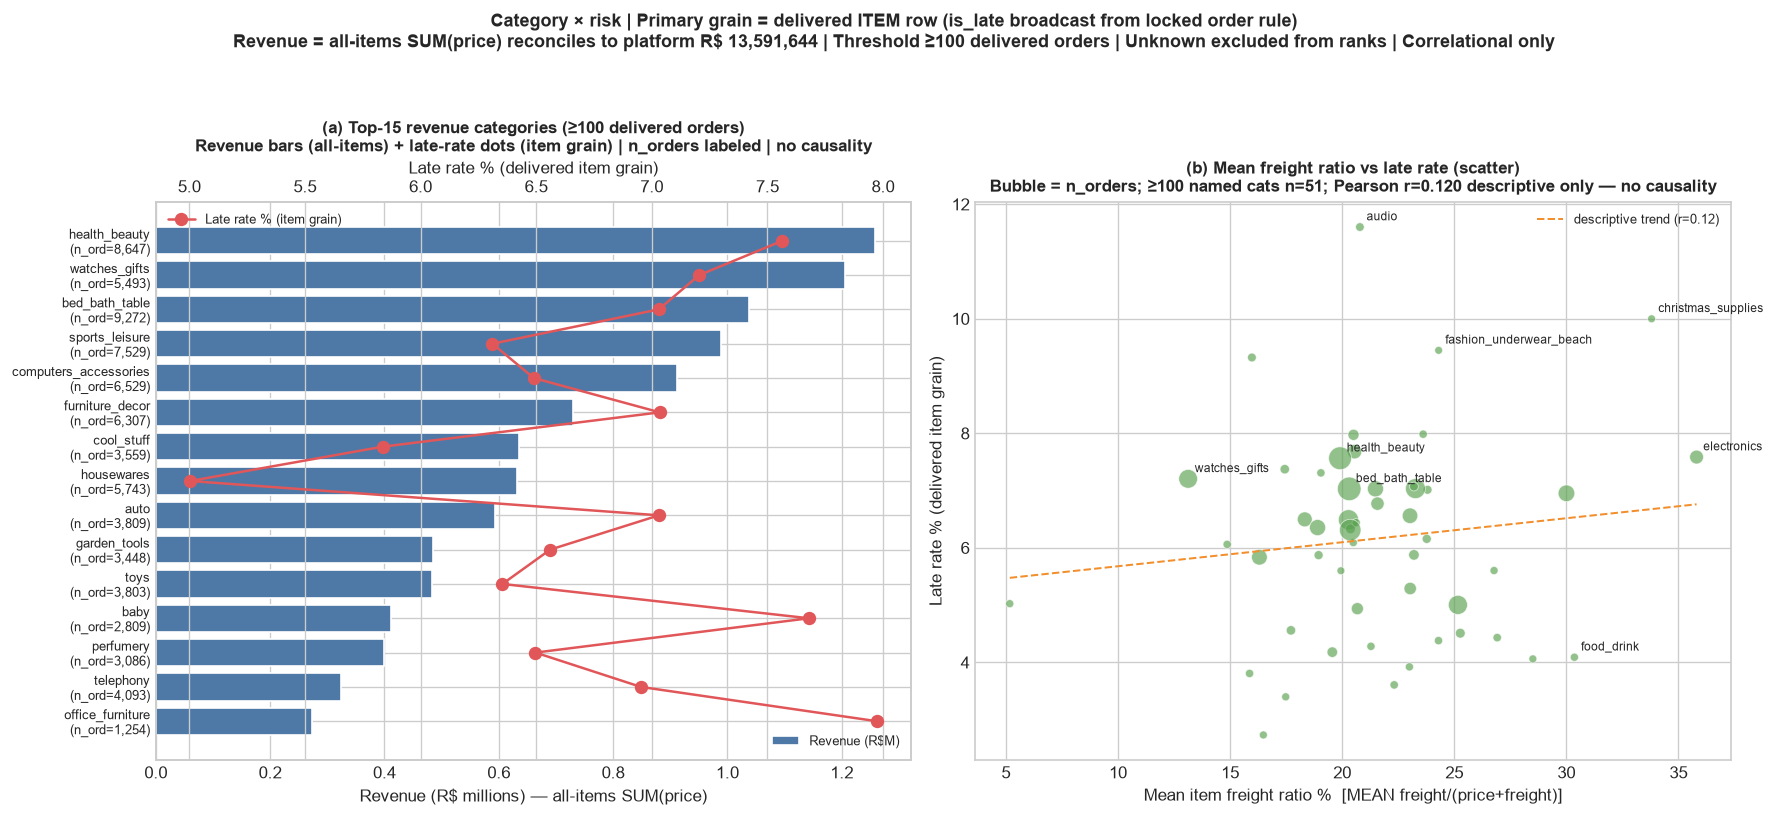

In [18]:
# SECTION 16: CATEGORY × RISK — mirrors notebooks/olist_full_eda.py
# Locked late rule / delivered base / revenue base from earlier cells. Do NOT redefine late.

# ══════════════════════════════════════════════════════════════════════════
# SECTION 16: CATEGORY × RISK (Task 4 — append-only; locked late rule)
# ══════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('SECTION 16: CATEGORY × RISK (ITEM GRAIN + ORDER SENSITIVITY)')
print('='*70)

TABLES_PATH = ROOT / 'outputs' / 'tables'
TABLES_PATH.mkdir(parents=True, exist_ok=True)

# Fresh products + translation (do not rely on earlier merge side-effects for PT name)
_products_cat = pd.read_csv(DATA_PATH / 'olist_products_dataset.csv')[
    ['product_id', 'product_category_name', 'product_weight_g']
]
_cat_trans = pd.read_csv(DATA_PATH / 'product_category_name_translation.csv')

# --- Missing / untranslated counts (products + item/order impact) ---
_n_prod_null_cat = int(_products_cat['product_category_name'].isna().sum())
_pt_cats = set(_products_cat['product_category_name'].dropna().unique())
_en_mapped = set(_cat_trans['product_category_name'].unique())
_pt_untranslated = sorted(_pt_cats - _en_mapped)

# All-items frame (revenue / freight / weight — locked REVENUE_BASE)
_cat_all = (
    items[['order_id', 'product_id', 'price', 'freight_value']]
    .merge(_products_cat, on='product_id', how='left')
    .merge(_cat_trans, on='product_category_name', how='left')
)
_miss_all = _cat_all['product_category_name'].isna()
_untr_all = (
    _cat_all['product_category_name'].notna()
    & _cat_all['product_category_name_english'].isna()
)
_cat_all['category_en'] = _cat_all['product_category_name_english']
_cat_all.loc[_miss_all | _untr_all, 'category_en'] = 'Unknown / untranslated'
_cat_all['item_freight_ratio'] = np.where(
    (_cat_all['price'] + _cat_all['freight_value']) > 0,
    _cat_all['freight_value'] / (_cat_all['price'] + _cat_all['freight_value']),
    np.nan,
)

# Delivered item frame: items → INNER orders_delivered (locked is_late) → products → translation
# Reuse locked is_late; do NOT redefine late.
_cat_del = (
    items[['order_id', 'product_id', 'price', 'freight_value']]
    .merge(
        orders_delivered[['order_id', 'is_late', 'delivery_delta', 'actual_delivery_days']],
        on='order_id', how='inner',
    )
    .merge(_products_cat, on='product_id', how='left')
    .merge(_cat_trans, on='product_category_name', how='left')
)
_miss_del = _cat_del['product_category_name'].isna()
_untr_del = (
    _cat_del['product_category_name'].notna()
    & _cat_del['product_category_name_english'].isna()
)
_cat_del['category_en'] = _cat_del['product_category_name_english']
_cat_del.loc[_miss_del | _untr_del, 'category_en'] = 'Unknown / untranslated'

# Reviews: dedupe at order grain, broadcast to items
_order_reviews_cat = reviews[['order_id', 'review_score']].drop_duplicates(subset='order_id')
_cat_del = _cat_del.merge(_order_reviews_cat, on='order_id', how='left')

# Impact counts
_null_prod_ids = _products_cat.loc[
    _products_cat['product_category_name'].isna(), 'product_id'
]
_aff_items_null = int(_cat_all['product_id'].isin(_null_prod_ids).sum())
_aff_orders_null = int(
    _cat_all.loc[_cat_all['product_id'].isin(_null_prod_ids), 'order_id'].nunique()
)
_aff_rev_null = float(
    _cat_all.loc[_cat_all['product_id'].isin(_null_prod_ids), 'price'].sum()
)
_aff_items_untr = int(_untr_all.sum())
_aff_orders_untr = int(_cat_all.loc[_untr_all, 'order_id'].nunique())
_aff_rev_untr = float(_cat_all.loc[_untr_all, 'price'].sum())
_n_pt_untranslated = len(_pt_untranslated)

print('  QUALITY — missing / translation')
print(f'  Distinct products with null product_category_name: {_n_prod_null_cat:,}')
print(f'    affected items/orders/revenue: {_aff_items_null:,} / '
      f'{_aff_orders_null:,} / R$ {_aff_rev_null:,.2f}')
print(f'  Distinct PT categories with no English mapping: {_n_pt_untranslated} '
      f'{_pt_untranslated}')
print(f'    affected items/orders/revenue: {_aff_items_untr:,} / '
      f'{_aff_orders_untr:,} / R$ {_aff_rev_untr:,.2f}')
print(f'  Bucket label: Unknown / untranslated '
      f'(null + untranslated pooled)')

# --- Per-category aggregation (primary late/review = delivered item grain) ---
_UNKNOWN = 'Unknown / untranslated'
_platform_rev = float(items['price'].sum())  # locked REVENUE_BASE

_all_agg = (
    _cat_all.groupby('category_en', dropna=False)
    .agg(
        revenue_sum=('price', 'sum'),
        freight_sum=('freight_value', 'sum'),
        mean_freight_ratio=('item_freight_ratio', 'mean'),
        avg_weight_g=('product_weight_g', 'mean'),
        n_items_all=('order_id', 'count'),
        n_orders_all=('order_id', 'nunique'),
    )
    .reset_index()
)

_del_agg = (
    _cat_del.groupby('category_en', dropna=False)
    .agg(
        n_items=('order_id', 'count'),
        n_orders=('order_id', 'nunique'),
        late_items=('is_late', 'sum'),
        reviewed_items_n=('review_score', lambda s: int(s.notna().sum())),
        avg_review_items=('review_score', 'mean'),
    )
    .reset_index()
)
_del_agg['late_items'] = _del_agg['late_items'].astype(int)
_del_agg['late_rate_items'] = _del_agg['late_items'] / _del_agg['n_items']

# Order-grain sensitivity: single-category delivered orders only
_ncat_per_order = _cat_del.groupby('order_id')['category_en'].nunique()
_single_cat_order_ids = set(_ncat_per_order[_ncat_per_order == 1].index)
_single_rows = (
    _cat_del[_cat_del['order_id'].isin(_single_cat_order_ids)]
    [['order_id', 'category_en', 'is_late']]
    .drop_duplicates('order_id')
)
_single_agg = (
    _single_rows.groupby('category_en', dropna=False)
    .agg(
        single_cat_orders=('order_id', 'nunique'),
        _single_late=('is_late', 'sum'),
    )
    .reset_index()
)
_single_agg['single_cat_late_rate'] = (
    _single_agg['_single_late'] / _single_agg['single_cat_orders']
)
_single_agg = _single_agg.drop(columns=['_single_late'])

category_risk = (
    _all_agg
    .merge(_del_agg, on='category_en', how='outer')
    .merge(_single_agg, on='category_en', how='left')
)
category_risk['n_items'] = category_risk['n_items'].fillna(0).astype(int)
category_risk['n_orders'] = category_risk['n_orders'].fillna(0).astype(int)
category_risk['late_items'] = category_risk['late_items'].fillna(0).astype(int)
category_risk['reviewed_items_n'] = (
    category_risk['reviewed_items_n'].fillna(0).astype(int)
)
category_risk['revenue_sum'] = category_risk['revenue_sum'].fillna(0.0)
category_risk['freight_sum'] = category_risk['freight_sum'].fillna(0.0)
category_risk['revenue_share'] = category_risk['revenue_sum'] / _platform_rev
category_risk['single_cat_orders'] = (
    category_risk['single_cat_orders'].fillna(0).astype(int)
)
# Undefined late rate when zero delivered items
category_risk.loc[category_risk['n_items'] == 0, 'late_rate_items'] = np.nan

# --- Reconciliation ---
_cat_rev_sum = float(category_risk['revenue_sum'].sum())
_rev_delta = _cat_rev_sum - _platform_rev
_late_items_total = int(category_risk['late_items'].sum())
_late_orders_locked = int(orders_delivered['is_late'].sum())  # 6,534
_reviewed_items_total = int(category_risk['reviewed_items_n'].sum())
_reviewed_orders_locked = int(
    orders_delivered.merge(_order_reviews_cat, on='order_id', how='inner')['order_id'].nunique()
)  # ~95,824

print('  QUALITY — reconciliation')
print(f'  Category SUM(price) = {_cat_rev_sum:,.2f} | platform = {_platform_rev:,.2f} | '
      f'delta = {_rev_delta:.4f} (must be 0)')
print(f'  Late items (broadcast) = {_late_items_total:,} vs locked late orders = '
      f'{_late_orders_locked:,} '
      f'(inflation from multi-item late orders; item/order ≈ '
      f'{_late_items_total / _late_orders_locked:.3f})')
print(f'  Reviewed items (broadcast) = {_reviewed_items_total:,} vs reviewed '
      f'delivered orders = {_reviewed_orders_locked:,}')

# --- Thresholds ---
_THR_HEAD = 100
_THR_SENS = 50
_ranked_mask = (
    (category_risk['n_orders'] >= _THR_HEAD)
    & (category_risk['category_en'] != _UNKNOWN)
)
_cat_head = category_risk[_ranked_mask].copy()
_cat_thin = category_risk[
    (category_risk['n_orders'] < _THR_HEAD)
    & (category_risk['category_en'] != _UNKNOWN)
]
_cat_unk = category_risk[category_risk['category_en'] == _UNKNOWN]

_n_cats_total = len(category_risk)
_n_cats_head = len(_cat_head)
_n_items_del_total = int(category_risk['n_items'].sum())
_n_orders_del_frame = int(_cat_del['order_id'].nunique())
_pct_cats_ge100 = 100.0 * _n_cats_head / max(_n_cats_total - (1 if len(_cat_unk) else 0), 1)
# Coverage among named categories + unknown kept in totals; report share of delivered items/orders/revenue retained at ≥100 (named only)
_pct_items_ge100 = 100.0 * _cat_head['n_items'].sum() / _n_items_del_total
_pct_orders_ge100 = 100.0 * _cat_head['n_orders'].sum() / max(
    category_risk['n_orders'].sum(), 1
)  # sum of per-cat n_orders (multi-cat orders counted in each cat)
_pct_rev_ge100 = 100.0 * _cat_head['revenue_sum'].sum() / _platform_rev

_thin_row = {
    'n_categories': int(len(_cat_thin)),
    'n_items': int(_cat_thin['n_items'].sum()),
    'n_orders': int(_cat_thin['n_orders'].sum()),
    'revenue_sum': float(_cat_thin['revenue_sum'].sum()),
    'late_items': int(_cat_thin['late_items'].sum()),
    'late_rate_items': (
        float(_cat_thin['late_items'].sum() / _cat_thin['n_items'].sum())
        if _cat_thin['n_items'].sum() else np.nan
    ),
}

print('  QUALITY — threshold coverage (≥100 delivered distinct orders; named cats)')
print(f'  Named categories ≥100: {_n_cats_head} / '
      f'{_n_cats_total - len(_cat_unk)} '
      f'({100.0 * _n_cats_head / max(_n_cats_total - len(_cat_unk), 1):.1f}% of named)')
print(f'  Retained at ≥100: items {_pct_items_ge100:.2f}% of delivered-item frame; '
      f'cat-order-sum share {_pct_orders_ge100:.2f}%; '
      f'revenue {_pct_rev_ge100:.2f}% of platform')
print(f'  Thin aggregate (<100, excl. Unknown): n_cats={_thin_row["n_categories"]}, '
      f'items={_thin_row["n_items"]:,}, orders_sum={_thin_row["n_orders"]:,}, '
      f'rev=R$ {_thin_row["revenue_sum"]:,.2f}, '
      f'late_rate={_thin_row["late_rate_items"]*100:.2f}%')
if len(_cat_unk):
    _u = _cat_unk.iloc[0]
    print(f'  Unknown / untranslated: items={int(_u["n_items"]):,}, '
          f'orders={int(_u["n_orders"]):,}, rev=R$ {float(_u["revenue_sum"]):,.2f}, '
          f'late_rate={float(_u["late_rate_items"])*100:.2f}% (excluded from ranked headlines)')

# --- Ranked tables (≥100, exclude Unknown) ---
_top15_rev = _cat_head.sort_values('revenue_sum', ascending=False).head(15)
_top15_late = _cat_head.sort_values(
    ['late_rate_items', 'n_orders'], ascending=[False, False]
).head(15)
_top15_freight = _cat_head.sort_values(
    ['mean_freight_ratio', 'n_orders'], ascending=[False, False]
).head(15)

# Chart-03 cross-check (all-items revenue leaders from SECTION 3)
_chart03_leaders = list(
    master.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)
_top15_rev_names = list(_top15_rev['category_en'])
_overlap = [c for c in _top15_rev_names if c in _chart03_leaders]
print('  QUALITY — top-15 revenue vs chart-03')
print(f'  Overlap: {len(_overlap)}/15 {_overlap}')
_only_new = [c for c in _top15_rev_names if c not in _chart03_leaders]
_only_old = [c for c in _chart03_leaders if c not in _top15_rev_names]
if _only_new or _only_old:
    print(f'  Diff new-only={_only_new} chart03-only={_only_old}')
else:
    print('  Exact name set match with chart-03 leaders')

# dvds_blu_ray freight cross-check (chart-13 used ≥50; may be <100 here)
_dvds = category_risk[category_risk['category_en'] == 'dvds_blu_ray']
if len(_dvds):
    _d = _dvds.iloc[0]
    print(f'  FREIGHT cross-check dvds_blu_ray: mean_item freight/(price+freight) = '
          f'{100 * float(_d["mean_freight_ratio"]):.2f}% '
          f'(n_orders delivered={int(_d["n_orders"])}; '
          f'{"≥100 headline" if int(_d["n_orders"]) >= _THR_HEAD else "below ≥100 — appendix/≥50 only"})')

# Descriptive Pearson r (≥100 named)
_r_freight_late = float(
    _cat_head['mean_freight_ratio'].corr(_cat_head['late_rate_items'])
)
_r_freight_review = float(
    _cat_head['mean_freight_ratio'].corr(_cat_head['avg_review_items'])
)
print(f'  Descriptive Pearson r (≥100 named): '
      f'mean_freight_ratio vs late_rate_items r={_r_freight_late:.3f}; '
      f'mean_freight_ratio vs avg_review_items r={_r_freight_review:.3f} '
      f'(description only — no causal test)')

print('\n  TOP-15 BY REVENUE (≥100 delivered orders; item-grain late cols)')
for _i, _r in enumerate(_top15_rev.itertuples(index=False), 1):
    print(f'  {_i:2d}. {_r.category_en}: rev=R$ {_r.revenue_sum:,.2f} | '
          f'n_items={_r.n_items:,} n_orders={_r.n_orders:,} | '
          f'late_rate={100*_r.late_rate_items:.2f}%')

print('\n  TOP-15 BY LATE RATE (≥100; item grain)')
for _i, _r in enumerate(_top15_late.itertuples(index=False), 1):
    print(f'  {_i:2d}. {_r.category_en}: late_rate={100*_r.late_rate_items:.2f}% | '
          f'n_items={_r.n_items:,} n_orders={_r.n_orders:,}')

print('\n  TOP-15 BY MEAN FREIGHT RATIO (≥100; MEAN freight/(price+freight) item)')
for _i, _r in enumerate(_top15_freight.itertuples(index=False), 1):
    print(f'  {_i:2d}. {_r.category_en}: freight_ratio={100*_r.mean_freight_ratio:.2f}% | '
          f'n_items={_r.n_items:,} n_orders={_r.n_orders:,}')

# Order-grain sensitivity for top-15 revenue categories
print('\n  ORDER-GRAIN SENSITIVITY (single-category delivered orders; top-15 revenue)')
_sens_rows = []
for _r in _top15_rev.itertuples(index=False):
    _sc_n = int(_r.single_cat_orders)
    _sc_lr = _r.single_cat_late_rate
    print(f'  {_r.category_en}: single_cat_orders={_sc_n:,} | '
          f'single_cat_late_rate={100*_sc_lr:.2f}% | '
          f'item late_rate={100*_r.late_rate_items:.2f}%')
    _sens_rows.append({
        'category_en': _r.category_en,
        'single_cat_orders': _sc_n,
        'single_cat_late_rate': _sc_lr,
        'late_rate_items': _r.late_rate_items,
        'n_items': _r.n_items,
        'n_orders': _r.n_orders,
    })

# Persist CSV (exact columns)
_cat_csv_cols = [
    'category_en', 'n_items', 'n_orders', 'revenue_sum', 'revenue_share',
    'freight_sum', 'mean_freight_ratio', 'late_items', 'late_rate_items',
    'avg_review_items', 'reviewed_items_n', 'avg_weight_g',
    'single_cat_orders', 'single_cat_late_rate',
]
category_risk_out = category_risk[_cat_csv_cols].sort_values(
    'revenue_sum', ascending=False
)
category_risk_csv = TABLES_PATH / 'category_risk.csv'
category_risk_out.to_csv(category_risk_csv, index=False)
print(f'\n  Saved: {category_risk_csv.relative_to(ROOT)}')

# Chart 21 — (a) top-15 revenue dual axis; (b) freight vs late scatter
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

_ax = axes[0]
_plot_rev = _top15_rev.sort_values('revenue_sum', ascending=True)
_y = np.arange(len(_plot_rev))
_bars = _ax.barh(
    _y, _plot_rev['revenue_sum'] / 1e6, color='#4E79A7', edgecolor='white',
    label='Revenue (R$M)',
)
_ax.set_yticks(_y)
_ax.set_yticklabels([
    f'{c}\n(n_ord={n:,})'
    for c, n in zip(_plot_rev['category_en'], _plot_rev['n_orders'])
], fontsize=8)
_ax.set_xlabel('Revenue (R$ millions) — all-items SUM(price)')
_ax2 = _ax.twiny()
_ax2.plot(
    _plot_rev['late_rate_items'] * 100, _y, 'o-', color='#E15759',
    markersize=7, linewidth=1.5, label='Late rate % (item grain)',
)
_ax2.set_xlabel('Late rate % (delivered item grain)')
_ax.set_title(
    f'(a) Top-15 revenue categories (≥{ _THR_HEAD } delivered orders)\n'
    f'Revenue bars (all-items) + late-rate dots (item grain) | '
    f'n_orders labeled | no causality',
    fontsize=10, fontweight='bold',
)
_ax.legend(loc='lower right', fontsize=8)
_ax2.legend(loc='upper left', fontsize=8)

_ax = axes[1]
_sc = _cat_head.copy()
_sizes = 20 + 180 * (_sc['n_orders'] / _sc['n_orders'].max())
_ax.scatter(
    _sc['mean_freight_ratio'] * 100, _sc['late_rate_items'] * 100,
    s=_sizes, alpha=0.65, c='#59A14F', edgecolors='white', linewidths=0.5,
)
# Label extremes (top late, top freight, top revenue)
_label_set = set(
    list(_top15_late.head(3)['category_en'])
    + list(_top15_freight.head(3)['category_en'])
    + list(_top15_rev.head(3)['category_en'])
)
for _, _row in _sc.iterrows():
    if _row['category_en'] in _label_set:
        _ax.annotate(
            _row['category_en'],
            (_row['mean_freight_ratio'] * 100, _row['late_rate_items'] * 100),
            textcoords='offset points', xytext=(4, 4), fontsize=7,
        )
# Descriptive trend line
_x = _sc['mean_freight_ratio'] * 100
_y = _sc['late_rate_items'] * 100
if len(_sc) >= 2 and _x.std() > 0:
    _z = np.polyfit(_x, _y, 1)
    _xs = np.linspace(_x.min(), _x.max(), 50)
    _ax.plot(_xs, np.polyval(_z, _xs), '--', color='#F28E2B', linewidth=1.2,
             label=f'descriptive trend (r={_r_freight_late:.2f})')
_ax.set_xlabel('Mean item freight ratio %  [MEAN freight/(price+freight)]')
_ax.set_ylabel('Late rate % (delivered item grain)')
_ax.set_title(
    f'(b) Mean freight ratio vs late rate (scatter)\n'
    f'Bubble = n_orders; ≥{_THR_HEAD} named cats n={len(_sc)}; '
    f'Pearson r={_r_freight_late:.3f} descriptive only — no causality',
    fontsize=10, fontweight='bold',
)
_ax.legend(loc='upper right', fontsize=8)

fig.suptitle(
    f'Category × risk | Primary grain = delivered ITEM row '
    f'(is_late broadcast from locked order rule)\n'
    f'Revenue = all-items SUM(price) reconciles to platform R$ {_platform_rev:,.0f} | '
    f'Threshold ≥{_THR_HEAD} delivered orders | Unknown excluded from ranks | '
    f'Correlational only',
    fontsize=11, fontweight='bold', y=1.04,
)
save_chart(fig, '21_category_risk')

print('  P1 link (descriptive only): category late-rate and freight-ratio '
      'co-occurrence is correlational; item-grain late counts exceed order-grain '
      '6,534 via multi-item broadcast — no claim that category causes lateness '
      'or review loss.')


## SECTION 17: Cohort Retention (Task 5)

Customer-grain retention on `customer_unique_id` with a **fixed 365-day** window from first purchase. Eligibility: `first_date <= 2018-10-17 - 365d = 2017-10-17`. Headline = H1-2017 pooled first-purchasers. Crude full-window one-time **96.88%** is recomputed for reconciliation only — not redefined.

Outputs: `outputs/tables/cohort_monthly.csv`, `cohort_customers.csv`, `outputs/charts/22_cohort_retention.png`, `docs/05-cohort-retention.md`.



SECTION 17: COHORT RETENTION (CUSTOMER GRAIN, FIXED 365-DAY WINDOW)


  Purchase timestamp nulls: 0 (assert 0)
  Purchase date min/max: 2016-09-04 21:15:19 -> 2018-10-17 17:30:18
  Unique customer_unique_id: 96,096
  unique_id->customer_id fan-out (>1 customer_id): 2,997
  Max distinct orders per customer_unique_id: 17
  Crude one-time (locked): 93,099/96,096 = 96.88%


  Eligibility cutoff: 2017-10-17 (= 2018-10-17 - 365 days)
  Eligible (<= cutoff): 29,087 | Censored / incomplete-window: 67,009 | Sum: 96,096 (expect 96,096)
  H1-2017 first-purchase cohort n: 14,239 (expect ≈14,239)


  Primary first-purchase delivered: 93,253 | non-delivered statuses: 2,843


  Saved: outputs\tables\cohort_customers.csv (29,087 rows)
  H1-2017 12m repeat: 666/14,239 = 4.68% | 3+ = 71 | median days->2nd = 60.5
  Saved: outputs\tables\cohort_monthly.csv
  Cross-foot Jan–Oct eligible n: 28,761 vs cust 28,761 | repeat 1,311 vs 1,311
  Monthly 12m repeat range (eligible): 3.46% – 6.28%
  H1-2017 6m (182d) repeat: 483/14,239 = 3.39%


  Delivered-only customers (any first): 93,358 | eligible <=cutoff: 27,911
  H1 delivered-only n: 13,592 (primary H1 n=14,239; delta n=647)
  H1 delivered-only 12m repeat: 616/13,592 = 4.53% | delta vs primary: +0.15 pp
  H1 repeaters — mean orders/12m (order grain, among repeaters): 2.14 | median: 2.0


  Saved: outputs\charts\22_cohort_retention.png
  P2 link (descriptive only): H1-2017 eligible customers show a higher 12m repeat rate (4.68%, 666/14,239) than the crude full-window repeat (3.12%, 2,997/96,096); different denominators and windows — crude 96.88% one-time is not retracted.


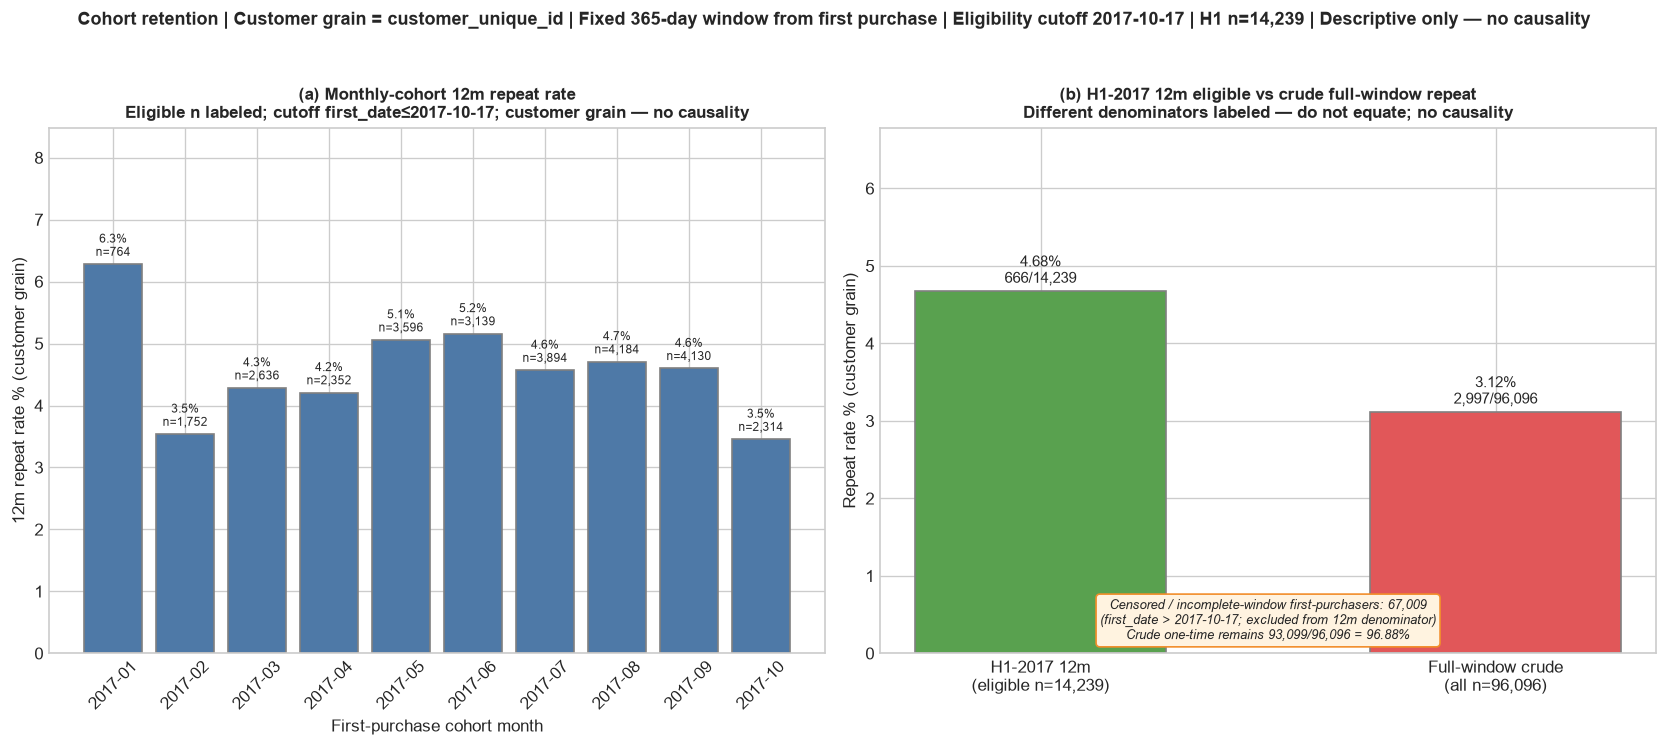

In [19]:
# SECTION 17: COHORT RETENTION — mirrors notebooks/olist_full_eda.py
# Crude 96.88% locked; do NOT redefine. Append-only after Section 16.
# ══════════════════════════════════════════════════════════════════════════
# SECTION 17: COHORT RETENTION (Task 5 — append-only; crude 96.88% locked)
# ══════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('SECTION 17: COHORT RETENTION (CUSTOMER GRAIN, FIXED 365-DAY WINDOW)')
print('='*70)

TABLES_PATH = ROOT / 'outputs' / 'tables'
TABLES_PATH.mkdir(parents=True, exist_ok=True)

# --- Identity: customer_unique_id (never customer_id for retention) ---
_coh_orders = orders.copy()
_coh_orders['order_purchase_timestamp'] = pd.to_datetime(
    _coh_orders['order_purchase_timestamp']
)
_coh = _coh_orders.merge(
    customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left'
)

# Quality checks
_purch_null = int(_coh['order_purchase_timestamp'].isna().sum())
_purch_min = _coh['order_purchase_timestamp'].min()
_purch_max = _coh['order_purchase_timestamp'].max()
_n_unique = int(_coh['customer_unique_id'].nunique())
_fanout = (
    _coh.groupby('customer_unique_id')['customer_id'].nunique() > 1
).sum()
_max_orders_cust = int(
    _coh.groupby('customer_unique_id')['order_id'].nunique().max()
)

print(f'  Purchase timestamp nulls: {_purch_null} (assert 0)')
assert _purch_null == 0, 'Expected 0 null purchase timestamps'
print(f'  Purchase date min/max: {_purch_min} -> {_purch_max}')
print(f'  Unique customer_unique_id: {_n_unique:,}')
print(f'  unique_id->customer_id fan-out (>1 customer_id): {_fanout:,}')
print(f'  Max distinct orders per customer_unique_id: {_max_orders_cust}')

# Crude full-window (locked defs — recompute, do not replace)
_crude_n = _coh.groupby('customer_unique_id')['order_id'].nunique()
_crude_one = int((_crude_n == 1).sum())
_crude_tot = int(len(_crude_n))
_crude_pct = _crude_one / _crude_tot * 100
print(f'  Crude one-time (locked): {_crude_one:,}/{_crude_tot:,} = {_crude_pct:.2f}%')
assert _crude_one == 93099 and _crude_tot == 96096

# First purchase = MIN(order_purchase_timestamp) over ALL statuses
_first = (
    _coh.groupby('customer_unique_id')
    .agg(first_date=('order_purchase_timestamp', 'min'))
    .reset_index()
)

# Eligibility: first_date ≤ 2018-10-17 − 365d = 2017-10-17
_DATA_END = pd.Timestamp('2018-10-17')
_ELIG_CUTOFF = _DATA_END - pd.Timedelta(days=365)  # 2017-10-17
assert _ELIG_CUTOFF == pd.Timestamp('2017-10-17')
_first['eligible_12m'] = _first['first_date'] <= _ELIG_CUTOFF
_n_eligible = int(_first['eligible_12m'].sum())
_n_censored = int((~_first['eligible_12m']).sum())
print(f'  Eligibility cutoff: {_ELIG_CUTOFF.date()} '
      f'(= {_DATA_END.date()} - 365 days)')
print(f'  Eligible (<= cutoff): {_n_eligible:,} | '
      f'Censored / incomplete-window: {_n_censored:,} | '
      f'Sum: {_n_eligible + _n_censored:,} (expect 96,096)')
assert _n_eligible + _n_censored == 96096

# H1-2017 first-purchasers (feasibility anchor ≈14,239)
_h1_mask = (
    (_first['first_date'] >= pd.Timestamp('2017-01-01'))
    & (_first['first_date'] < pd.Timestamp('2017-07-01'))
)
_n_h1 = int(_h1_mask.sum())
print(f'  H1-2017 first-purchase cohort n: {_n_h1:,} (expect ≈14,239)')

# Primary first-purchase status mix (all statuses included in primary)
_idx_first = _coh.groupby('customer_unique_id')['order_purchase_timestamp'].idxmin()
_first_status = _coh.loc[_idx_first, ['customer_unique_id', 'order_status']].copy()
_n_first_delivered = int((_first_status['order_status'] == 'delivered').sum())
_n_first_nondel = _n_unique - _n_first_delivered
print(f'  Primary first-purchase delivered: {_n_first_delivered:,} | '
      f'non-delivered statuses: {_n_first_nondel:,}')

# --- 12m repeat metrics (customer grain, distinct order_id, ≤ first+365d) ---
_elig = _first[_first['eligible_12m']].copy()
_od = _coh.merge(
    _elig[['customer_unique_id', 'first_date']], on='customer_unique_id', how='inner'
)
_od['days_from_first'] = (
    _od['order_purchase_timestamp'] - _od['first_date']
).dt.days
_od12 = _od[(_od['days_from_first'] >= 0) & (_od['days_from_first'] <= 365)]

_n12 = (
    _od12.groupby('customer_unique_id')['order_id'].nunique()
    .rename('n_orders_12m').reset_index()
)
_order_ts = (
    _od12.groupby(['customer_unique_id', 'order_id'])['order_purchase_timestamp']
    .min().reset_index()
    .sort_values(['customer_unique_id', 'order_purchase_timestamp'])
)
_order_ts['ord_rank'] = _order_ts.groupby('customer_unique_id').cumcount() + 1
_second = (
    _order_ts[_order_ts['ord_rank'] == 2]
    [['customer_unique_id', 'order_purchase_timestamp']]
    .rename(columns={'order_purchase_timestamp': 'second_ts'})
)

_cust = _elig.merge(_n12, on='customer_unique_id', how='left')
_cust['n_orders_12m'] = _cust['n_orders_12m'].fillna(0).astype(int)
_cust = _cust.merge(_second, on='customer_unique_id', how='left')
_cust['days_to_second'] = (_cust['second_ts'] - _cust['first_date']).dt.days
_cust['repeated_12m'] = (_cust['n_orders_12m'] >= 2).astype(int)
_cust['cohort_month'] = _cust['first_date'].dt.to_period('M')

# Customer-level export (eligible only)
_cust_out = _cust[
    ['customer_unique_id', 'first_date', 'n_orders_12m', 'repeated_12m', 'days_to_second']
].copy()
_cust_csv = TABLES_PATH / 'cohort_customers.csv'
_cust_out.to_csv(_cust_csv, index=False)
print(f'  Saved: {_cust_csv.relative_to(ROOT)} ({len(_cust_out):,} rows)')

# H1-2017 headline (all H1 first-purchasers are eligible)
_h1 = _cust[
    (_cust['first_date'] >= pd.Timestamp('2017-01-01'))
    & (_cust['first_date'] < pd.Timestamp('2017-07-01'))
]
_h1_n = len(_h1)
_h1_rep = int(_h1['repeated_12m'].sum())
_h1_rate = _h1_rep / _h1_n * 100
_h1_3plus = int((_h1['n_orders_12m'] >= 3).sum())
_h1_med = float(_h1.loc[_h1['repeated_12m'] == 1, 'days_to_second'].median())
print(f'  H1-2017 12m repeat: {_h1_rep:,}/{_h1_n:,} = {_h1_rate:.2f}% '
      f'| 3+ = {_h1_3plus:,} | median days->2nd = {_h1_med:.1f}')

# Monthly cohorts Jan–Oct 2017
_all_first = _first.copy()
_all_first['cohort_month'] = _all_first['first_date'].dt.to_period('M')
_monthly_rows = []
for _m in pd.period_range('2017-01', '2017-10', freq='M'):
    _all_m = _all_first[_all_first['cohort_month'] == _m]
    _n_cust_m = len(_all_m)
    _elig_m = _cust[_cust['cohort_month'] == _m]
    _n_elig_m = len(_elig_m)
    _n_rep_m = int(_elig_m['repeated_12m'].sum()) if _n_elig_m else 0
    _rate_m = (_n_rep_m / _n_elig_m) if _n_elig_m else np.nan
    _n3_m = int((_elig_m['n_orders_12m'] >= 3).sum()) if _n_elig_m else 0
    _med_m = (
        float(_elig_m.loc[_elig_m['repeated_12m'] == 1, 'days_to_second'].median())
        if _n_rep_m else np.nan
    )
    _note = ''
    if _m == pd.Period('2017-10', 'M'):
        _note = (
            f'Oct truncated to first_date≤{_ELIG_CUTOFF.date()}; '
            f'{_n_cust_m - _n_elig_m} post-cutoff first-purchasers censored'
        )
    _monthly_rows.append({
        'cohort_month': str(_m),
        'n_customers': _n_cust_m,
        'n_eligible_12m': _n_elig_m,
        'n_repeat_12m': _n_rep_m,
        'repeat_12m_rate': round(_rate_m, 6) if pd.notna(_rate_m) else np.nan,
        'n_3plus_12m': _n3_m,
        'median_days_to_second': _med_m,
        'note': _note,
    })

_monthly = pd.DataFrame(_monthly_rows)
_monthly_csv = TABLES_PATH / 'cohort_monthly.csv'
_monthly.to_csv(_monthly_csv, index=False)
print(f'  Saved: {_monthly_csv.relative_to(ROOT)}')

# Cross-foot: Jan–Oct eligible repeat sum vs monthly table
_cross_rep = int(_monthly['n_repeat_12m'].sum())
_cross_elig = int(_monthly['n_eligible_12m'].sum())
_jan_oct = _cust[
    (_cust['first_date'] >= pd.Timestamp('2017-01-01'))
    & (_cust['first_date'] <= _ELIG_CUTOFF)
]
print(f'  Cross-foot Jan–Oct eligible n: {_cross_elig:,} vs cust '
      f'{len(_jan_oct):,} | repeat {_cross_rep:,} vs '
      f'{int(_jan_oct["repeated_12m"].sum()):,}')
assert _cross_elig == len(_jan_oct)
assert _cross_rep == int(_jan_oct['repeated_12m'].sum())

_rate_min = float(_monthly['repeat_12m_rate'].min()) * 100
_rate_max = float(_monthly['repeat_12m_rate'].max()) * 100
print(f'  Monthly 12m repeat range (eligible): {_rate_min:.2f}% – {_rate_max:.2f}%')

# --- 6m-window sensitivity (fixed 182-day ≈6m; same eligibility) ---
_WINDOW_6M = 182
_od6 = _od[(_od['days_from_first'] >= 0) & (_od['days_from_first'] <= _WINDOW_6M)]
_n6 = _od6.groupby('customer_unique_id')['order_id'].nunique()
_h1_n6 = _h1['customer_unique_id'].map(_n6).fillna(0)
_h1_rep6 = int((_h1_n6 >= 2).sum())
_h1_rate6 = _h1_rep6 / _h1_n * 100
print(f'  H1-2017 6m ({_WINDOW_6M}d) repeat: {_h1_rep6:,}/{_h1_n:,} = {_h1_rate6:.2f}%')

# --- Delivered-only sensitivity (order_status=='delivered' only) ---
_coh_del = _coh[_coh['order_status'] == 'delivered'].copy()
_first_del = (
    _coh_del.groupby('customer_unique_id')
    .agg(first_date=('order_purchase_timestamp', 'min'))
    .reset_index()
)
_first_del_elig = _first_del[_first_del['first_date'] <= _ELIG_CUTOFF].copy()
_n_del_unique = int(_first_del['customer_unique_id'].nunique())
_n_del_elig = len(_first_del_elig)
_h1_del = _first_del_elig[
    (_first_del_elig['first_date'] >= pd.Timestamp('2017-01-01'))
    & (_first_del_elig['first_date'] < pd.Timestamp('2017-07-01'))
]
_n_h1_del = len(_h1_del)
_od_del = _coh_del.merge(
    _h1_del[['customer_unique_id', 'first_date']], on='customer_unique_id', how='inner'
)
_od_del['days_from_first'] = (
    _od_del['order_purchase_timestamp'] - _od_del['first_date']
).dt.days
_od_del12 = _od_del[
    (_od_del['days_from_first'] >= 0) & (_od_del['days_from_first'] <= 365)
]
_n_del12 = _od_del12.groupby('customer_unique_id')['order_id'].nunique()
_h1_del_n12 = _h1_del['customer_unique_id'].map(_n_del12).fillna(0)
_h1_del_rep = int((_h1_del_n12 >= 2).sum())
_h1_del_rate = _h1_del_rep / _n_h1_del * 100 if _n_h1_del else np.nan
_delta_pp = _h1_rate - _h1_del_rate
print(f'  Delivered-only customers (any first): {_n_del_unique:,} | '
      f'eligible <=cutoff: {_n_del_elig:,}')
print(f'  H1 delivered-only n: {_n_h1_del:,} (primary H1 n={_h1_n:,}; '
      f'delta n={_h1_n - _n_h1_del:,})')
print(f'  H1 delivered-only 12m repeat: {_h1_del_rep:,}/{_n_h1_del:,} = '
      f'{_h1_del_rate:.2f}% | delta vs primary: {_delta_pp:+.2f} pp')

# Orders-per-repeater supporting context (order grain, labeled)
_rep_orders = _h1.loc[_h1['repeated_12m'] == 1, 'n_orders_12m']
print(f'  H1 repeaters — mean orders/12m (order grain, among repeaters): '
      f'{_rep_orders.mean():.2f} | median: {_rep_orders.median():.1f}')

# --- Chart 22 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) Monthly-cohort 12m repeat bars
_ax = axes[0]
_xlab = _monthly['cohort_month'].tolist()
_rates_pct = (_monthly['repeat_12m_rate'] * 100).tolist()
_elig_ns = _monthly['n_eligible_12m'].tolist()
_bars = _ax.bar(_xlab, _rates_pct, color='#4E79A7', edgecolor='gray')
for _b, _r, _n in zip(_bars, _rates_pct, _elig_ns):
    _ax.text(
        _b.get_x() + _b.get_width() / 2, _b.get_height() + 0.08,
        f'{_r:.1f}%\nn={_n:,}', ha='center', va='bottom', fontsize=7,
    )
_ax.set_ylabel('12m repeat rate % (customer grain)')
_ax.set_xlabel('First-purchase cohort month')
_ax.set_ylim(0, max(_rates_pct) * 1.35)
_ax.set_title(
    '(a) Monthly-cohort 12m repeat rate\n'
    f'Eligible n labeled; cutoff first_date≤{_ELIG_CUTOFF.date()}; '
    'customer grain — no causality',
    fontsize=10, fontweight='bold',
)
_ax.tick_params(axis='x', rotation=45)

# (b) H1 headline vs crude comparison (different denominators)
_ax = axes[1]
_crude_repeat_n = _crude_tot - _crude_one  # 2,997
_crude_repeat_pct = _crude_repeat_n / _crude_tot * 100
_bar_labels = [
    f'H1-2017 12m\n(eligible n={_h1_n:,})',
    f'Full-window crude\n(all n={_crude_tot:,})',
]
_bar_vals = [_h1_rate, _crude_repeat_pct]
_colors_b = ['#59A14F', '#E15759']
_bars2 = _ax.bar(_bar_labels, _bar_vals, color=_colors_b, edgecolor='gray', width=0.55)
for _b, _v, _num, _den in zip(
    _bars2, _bar_vals,
    [_h1_rep, _crude_repeat_n],
    [_h1_n, _crude_tot],
):
    _ax.text(
        _b.get_x() + _b.get_width() / 2, _b.get_height() + 0.05,
        f'{_v:.2f}%\n{_num:,}/{_den:,}', ha='center', va='bottom', fontsize=9,
    )
_ax.set_ylabel('Repeat rate % (customer grain)')
_ax.set_ylim(0, max(_bar_vals) * 1.45)
_ax.set_title(
    '(b) H1-2017 12m eligible vs crude full-window repeat\n'
    'Different denominators labeled — do not equate; no causality',
    fontsize=10, fontweight='bold',
)
_ax.annotate(
    f'Censored / incomplete-window first-purchasers: {_n_censored:,}\n'
    f'(first_date > {_ELIG_CUTOFF.date()}; excluded from 12m denominator)\n'
    f'Crude one-time remains {_crude_one:,}/{_crude_tot:,} = {_crude_pct:.2f}%',
    xy=(0.5, 0.02), xycoords='axes fraction', ha='center', va='bottom',
    fontsize=8, style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0', edgecolor='#F28E2B'),
)

fig.suptitle(
    f'Cohort retention | Customer grain = customer_unique_id | '
    f'Fixed 365-day window from first purchase | '
    f'Eligibility cutoff {_ELIG_CUTOFF.date()} | '
    f'H1 n={_h1_n:,} | Descriptive only — no causality',
    fontsize=11, fontweight='bold', y=1.03,
)
save_chart(fig, '22_cohort_retention')

print('  P2 link (descriptive only): H1-2017 eligible customers show a higher '
      f'12m repeat rate ({_h1_rate:.2f}%, {_h1_rep:,}/{_h1_n:,}) than the crude '
      f'full-window repeat ({_crude_repeat_pct:.2f}%, {_crude_repeat_n:,}/{_crude_tot:,}); '
      'different denominators and windows — crude 96.88% one-time is not retracted.')


## SECTION 18: Financial Exposure Scenarios (Task 6)

Product GMV = locked SUM(price). Late GMV = SUM(price) on items with locked is_late broadcast.
Take-rates **15% / 19% / 21%** are **unsourced assumptions** (true 2016-18 take-rate unverified).
Implied commission = GMV x rate. Descriptive / scenario only — no causality, no recoverable-revenue column.
Chart: 23_financial_exposure.png · Table: outputs/tables/financial_exposure.csv · Doc: docs/06-financial-exposure.md.



SECTION 18: FINANCIAL EXPOSURE SCENARIOS (PRODUCT GMV × TAKE-RATE)


  CHECKS
  GMV reconciliation: computed=13,591,643.70 | locked=13,591,643.70 | delta=0.0000 (expect 0)
  Late-order count anchor: 6,534 (expect 6,534; locked order-level is_late)
  Late-item/GMV broadcast: 7,264 late items / 6,534 late orders (ratio 1.112); late GMV=R$ 985,924.34 (7.25% of product GMV) — multi-item orders inherit the same order-level is_late
  Take-rate math audit: commission = GMV × rate (15/19/21% on late GMV → R$ 147,888.65 / 187,325.62 / 207,044.11)
  Coverage vs Task 3 IDs: top-30 set size=30 (overlap with Section-15 _top30=30/30); D1 sellers=310 (expect 310)
  Customer-paid context (not commissionable primary): R$ 15,843,553.24 = SUM(price)+SUM(freight)
  payment_value footnote (reconciliation only): R$ 16,008,872.12
  Concentration: D1 late GMV / late GMV = 68.98%; top-30 late-seller GMV / late GMV = 22.76%; top-10 cat late GMV / late GMV = 64.65%
  True 2016–18 take-rate is UNVERIFIED — 15/19/21% are scenario assumptions only.
  Saved: outputs\tables\financial_

  Saved: outputs\charts\23_financial_exposure.png
  Scenario headline: late GMV represents 7.25% of product GMV; under 19% assumption implied commission on late GMV = R$ 187,325.62 (true 2016–18 take-rate unverified).


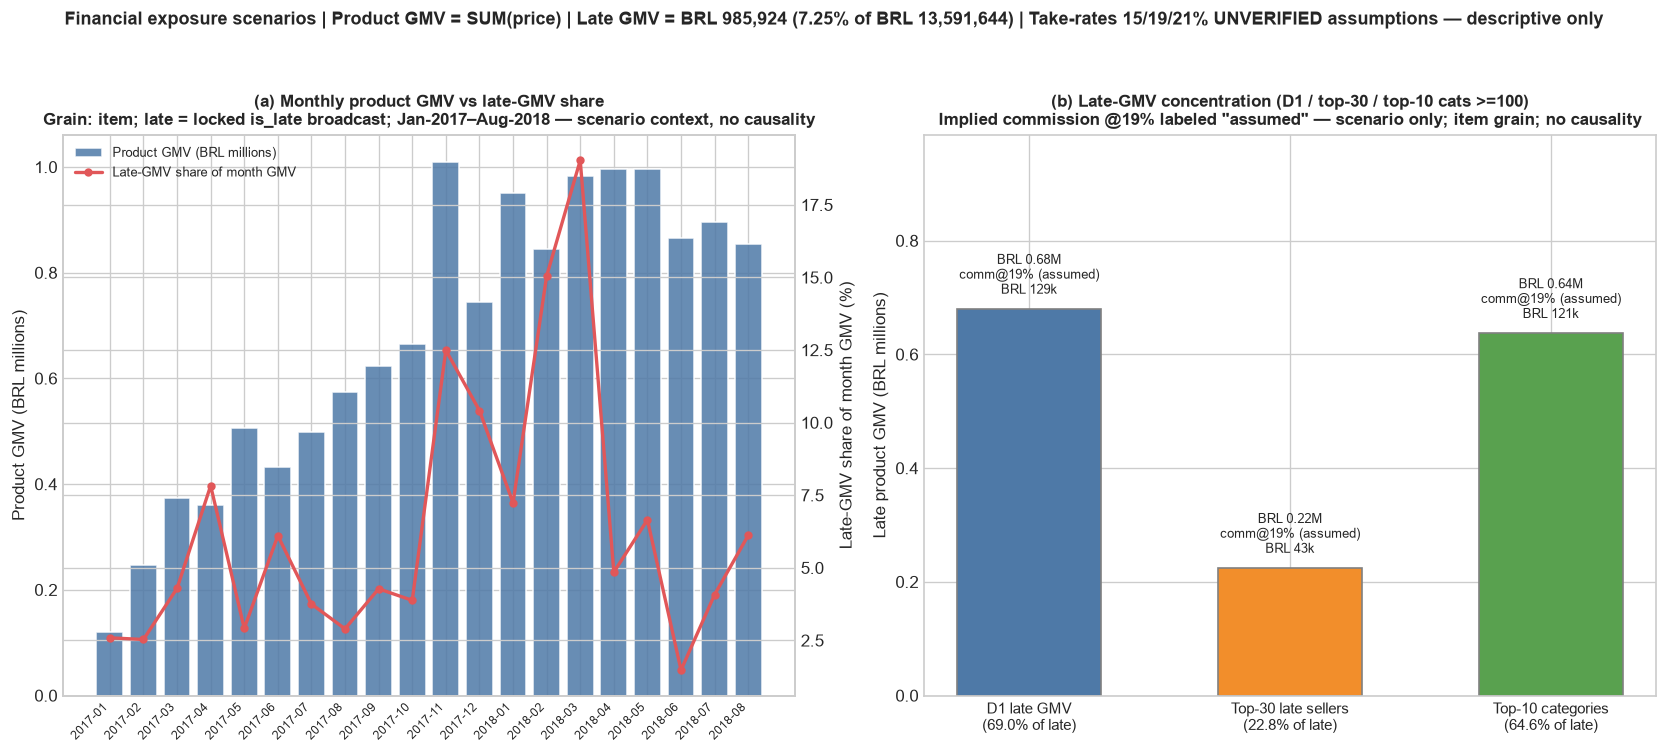

In [20]:
# SECTION 18: FINANCIAL EXPOSURE SCENARIOS — mirrors notebooks/olist_full_eda.py
# Take-rates 15/19/21% UNSOURCED assumptions; do NOT edit Sections 1-17.
# ══════════════════════════════════════════════════════════════════════════
# SECTION 18: FINANCIAL EXPOSURE SCENARIOS (Task 6 — append-only)
# Product GMV = SUM(price) locked; late GMV = SUM(price) on locked is_late broadcast.
# Take-rates {15%, 19%, 21%} are UNSOURCED assumptions — scenarios only, not facts.
# ══════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('SECTION 18: FINANCIAL EXPOSURE SCENARIOS (PRODUCT GMV × TAKE-RATE)')
print('='*70)

TABLES_PATH = ROOT / 'outputs' / 'tables'
TABLES_PATH.mkdir(parents=True, exist_ok=True)

_FX_LOCKED_GMV = 13_591_643.70
_FX_RATES = (0.15, 0.19, 0.21)

# --- Bases (no redefinition) ---
# Product GMV = SUM(items.price) — locked REVENUE_BASE
_fx_total_gmv = float(items['price'].sum())
_fx_gmv_delta = _fx_total_gmv - _FX_LOCKED_GMV
_fx_n_items_all = int(len(items))
_fx_n_orders_all = int(items['order_id'].nunique())
_fx_freight = float(items['freight_value'].sum())
_fx_customer_paid = _fx_total_gmv + _fx_freight  # context only
_fx_payment_value = float(payments['payment_value'].sum())  # reconciliation footnote only

# Late GMV: item grain, order-level locked is_late broadcast to items
_fx_del_items = (
    items[['order_id', 'seller_id', 'product_id', 'price', 'freight_value']]
    .merge(
        orders_delivered[['order_id', 'is_late', 'order_purchase_timestamp']],
        on='order_id', how='inner',
    )
)
_fx_late = _fx_del_items[_fx_del_items['is_late']].copy()
_fx_late_gmv = float(_fx_late['price'].sum())
_fx_late_n_items = int(len(_fx_late))
_fx_late_n_orders = int(_fx_late['order_id'].nunique())  # expect 6,534
_fx_late_share = _fx_late_gmv / _fx_total_gmv if _fx_total_gmv else np.nan

# Top-30 late-seller IDs (Task 3) + D1 seller IDs (Task 3 revenue decile)
_fx_top30_ids = set(_top30['seller_id'].tolist())
_fx_d1_ids = set(
    seller_level.loc[seller_level['revenue_decile'] == 'D1', 'seller_id'].tolist()
)
_fx_top30_late = _fx_late[_fx_late['seller_id'].isin(_fx_top30_ids)]
_fx_d1_late = _fx_late[_fx_late['seller_id'].isin(_fx_d1_ids)]
_fx_top30_late_gmv = float(_fx_top30_late['price'].sum())
_fx_d1_late_gmv = float(_fx_d1_late['price'].sum())
_fx_top30_conc = (
    _fx_top30_late_gmv / _fx_late_gmv if _fx_late_gmv else np.nan
)
_fx_d1_conc = (
    _fx_d1_late_gmv / _fx_late_gmv if _fx_late_gmv else np.nan
)

# Category late-GMV top-10 (≥100 delivered-order filter, item grain; excl. Unknown)
_UNKNOWN_FX = 'Unknown / untranslated'
_fx_cat_frame = (
    _fx_del_items
    .merge(
        products[['product_id', 'product_category_name']],
        on='product_id', how='left',
    )
    .merge(
        cat_translation,
        on='product_category_name', how='left',
    )
)
_miss_fx = _fx_cat_frame['product_category_name'].isna()
_untr_fx = (
    _fx_cat_frame['product_category_name'].notna()
    & _fx_cat_frame['product_category_name_english'].isna()
)
_fx_cat_frame['category_en'] = _fx_cat_frame['product_category_name_english']
_fx_cat_frame.loc[_miss_fx | _untr_fx, 'category_en'] = _UNKNOWN_FX

_fx_cat_n_orders = (
    _fx_cat_frame.groupby('category_en')['order_id'].nunique()
)
_fx_headline_cats = set(
    _fx_cat_n_orders[
        (_fx_cat_n_orders >= 100) & (_fx_cat_n_orders.index != _UNKNOWN_FX)
    ].index
)
_fx_cat_late = (
    _fx_cat_frame[_fx_cat_frame['is_late'] & _fx_cat_frame['category_en'].isin(_fx_headline_cats)]
    .groupby('category_en', as_index=False)
    .agg(
        late_gmv=('price', 'sum'),
        n_items=('order_id', 'count'),
        n_orders=('order_id', 'nunique'),
    )
    .sort_values('late_gmv', ascending=False)
)
_fx_cat_top10 = _fx_cat_late.head(10).copy()
_fx_cat_top10_gmv = float(_fx_cat_top10['late_gmv'].sum())
_fx_cat_top10_conc = (
    _fx_cat_top10_gmv / _fx_late_gmv if _fx_late_gmv else np.nan
)

# Monthly late-GMV rate (purchase month, Jan-2017–Aug-2018)
_fx_all_month = (
    items[['order_id', 'price']]
    .merge(orders[['order_id', 'order_purchase_timestamp']], on='order_id', how='left')
)
_fx_all_month['purchase_month'] = (
    pd.to_datetime(_fx_all_month['order_purchase_timestamp']).dt.to_period('M')
)
_fx_late['purchase_month'] = (
    pd.to_datetime(_fx_late['order_purchase_timestamp']).dt.to_period('M')
)
_fx_month_range = pd.period_range('2017-01', '2018-08', freq='M')
_fx_monthly_rows = []
for _m in _fx_month_range:
    _mg = float(
        _fx_all_month.loc[_fx_all_month['purchase_month'] == _m, 'price'].sum()
    )
    _ml = _fx_late[_fx_late['purchase_month'] == _m]
    _ml_gmv = float(_ml['price'].sum())
    _ml_items = int(len(_ml))
    _ml_orders = int(_ml['order_id'].nunique())
    _rate = (_ml_gmv / _mg) if _mg else np.nan
    _fx_monthly_rows.append({
        'purchase_month': str(_m),
        'gmv_product': _mg,
        'late_gmv': _ml_gmv,
        'late_gmv_rate': _rate,
        'n_items_late': _ml_items,
        'n_orders_late': _ml_orders,
    })
_fx_monthly = pd.DataFrame(_fx_monthly_rows)

# --- Scenario commissions (assumption only) ---
def _fx_comms(gmv):
    return {r: gmv * r for r in _FX_RATES}


def _fx_row(slice_name, grain, n_items, n_orders, gmv, share):
    c = _fx_comms(gmv)
    return {
        'slice': slice_name,
        'grain': grain,
        'n_items': int(n_items),
        'n_orders': int(n_orders),
        'gmv_product': round(float(gmv), 2),
        'gmv_share': round(float(share), 6) if pd.notna(share) else np.nan,
        'commission_15': round(c[0.15], 2),
        'commission_19': round(c[0.19], 2),
        'commission_21': round(c[0.21], 2),
    }


_fx_rows = [
    _fx_row(
        'total_product_gmv', 'item (all items)',
        _fx_n_items_all, _fx_n_orders_all,
        _fx_total_gmv, 1.0,
    ),
    _fx_row(
        'late_product_gmv', 'item (delivered; is_late broadcast)',
        _fx_late_n_items, _fx_late_n_orders,
        _fx_late_gmv, _fx_late_share,
    ),
    _fx_row(
        'd1_late_gmv', 'item (D1 sellers × late orders)',
        len(_fx_d1_late), _fx_d1_late['order_id'].nunique(),
        _fx_d1_late_gmv, _fx_d1_late_gmv / _fx_total_gmv,
    ),
    _fx_row(
        'top30_late_seller_gmv', 'item (Task-3 top-30 late sellers × late)',
        len(_fx_top30_late), _fx_top30_late['order_id'].nunique(),
        _fx_top30_late_gmv, _fx_top30_late_gmv / _fx_total_gmv,
    ),
    _fx_row(
        'cat_top10_late_gmv', 'item (≥100 cats; top-10 by late GMV)',
        int(_fx_cat_top10['n_items'].sum()),
        int(_fx_cat_frame[
            _fx_cat_frame['is_late']
            & _fx_cat_frame['category_en'].isin(_fx_cat_top10['category_en'])
        ]['order_id'].nunique()),
        _fx_cat_top10_gmv, _fx_cat_top10_gmv / _fx_total_gmv,
    ),
]
for _, _cr in _fx_cat_top10.iterrows():
    _fx_rows.append(_fx_row(
        f"cat_late_{_cr['category_en']}",
        'item (≥100 filter; late GMV)',
        int(_cr['n_items']), int(_cr['n_orders']),
        float(_cr['late_gmv']), float(_cr['late_gmv']) / _fx_total_gmv,
    ))
for _mr in _fx_monthly_rows:
    _fx_rows.append(_fx_row(
        f"monthly_late_{_mr['purchase_month']}",
        'item (purchase month; late GMV)',
        _mr['n_items_late'], _mr['n_orders_late'],
        _mr['late_gmv'],
        _mr['late_gmv_rate'],  # share of that month's product GMV
    ))

financial_exposure = pd.DataFrame(_fx_rows)
_fx_csv = TABLES_PATH / 'financial_exposure.csv'
financial_exposure.to_csv(_fx_csv, index=False)

# --- Checks (required prints) ---
print('  CHECKS')
print(f'  GMV reconciliation: computed={_fx_total_gmv:,.2f} | '
      f'locked={_FX_LOCKED_GMV:,.2f} | delta={_fx_gmv_delta:.4f} '
      f'(expect 0)')
assert abs(_fx_gmv_delta) < 0.01, 'GMV reconciliation delta must be ~0'
print(f'  Late-order count anchor: {_fx_late_n_orders:,} '
      f'(expect 6,534; locked order-level is_late)')
assert _fx_late_n_orders == 6534, 'Late-order count must be 6,534'
print(f'  Late-item/GMV broadcast: {_fx_late_n_items:,} late items / '
      f'{_fx_late_n_orders:,} late orders (ratio '
      f'{_fx_late_n_items / _fx_late_n_orders:.3f}); '
      f'late GMV=R$ {_fx_late_gmv:,.2f} '
      f'({100 * _fx_late_share:.2f}% of product GMV) — '
      f'multi-item orders inherit the same order-level is_late')
print(f'  Take-rate math audit: commission = GMV × rate '
      f'(15/19/21% on late GMV → '
      f'R$ {_fx_late_gmv * 0.15:,.2f} / '
      f'{_fx_late_gmv * 0.19:,.2f} / '
      f'{_fx_late_gmv * 0.21:,.2f})')
_fx_top30_cov = len(_fx_top30_ids & set(_top30['seller_id']))
_fx_d1_n = len(_fx_d1_ids)
print(f'  Coverage vs Task 3 IDs: top-30 set size={len(_fx_top30_ids)} '
      f'(overlap with Section-15 _top30={_fx_top30_cov}/30); '
      f'D1 sellers={_fx_d1_n} (expect 310)')
assert _fx_top30_cov == 30
assert _fx_d1_n == 310
print(f'  Customer-paid context (not commissionable primary): '
      f'R$ {_fx_customer_paid:,.2f} = SUM(price)+SUM(freight)')
print(f'  payment_value footnote (reconciliation only): '
      f'R$ {_fx_payment_value:,.2f}')
print(f'  Concentration: D1 late GMV / late GMV = '
      f'{100 * _fx_d1_conc:.2f}%; '
      f'top-30 late-seller GMV / late GMV = '
      f'{100 * _fx_top30_conc:.2f}%; '
      f'top-10 cat late GMV / late GMV = '
      f'{100 * _fx_cat_top10_conc:.2f}%')
print(f'  True 2016–18 take-rate is UNVERIFIED — '
      f'15/19/21% are scenario assumptions only.')
print(f'  Saved: {_fx_csv.relative_to(ROOT)} ({len(financial_exposure)} rows)')

# --- Chart 23 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) monthly GMV vs late-GMV share
_ax = axes[0]
_xm = np.arange(len(_fx_monthly))
_ax.bar(
    _xm, _fx_monthly['gmv_product'] / 1e6,
    color='#4E79A7', edgecolor='white', alpha=0.85, label='Product GMV (BRL millions)',
)
_ax2 = _ax.twinx()
_ax2.plot(
    _xm, _fx_monthly['late_gmv_rate'] * 100,
    color='#E15759', marker='o', linewidth=2, markersize=4,
    label='Late-GMV share of month GMV',
)
_ax.set_xticks(_xm)
_ax.set_xticklabels(_fx_monthly['purchase_month'], rotation=45, ha='right', fontsize=7)
_ax.set_ylabel('Product GMV (BRL millions)')
_ax2.set_ylabel('Late-GMV share of month GMV (%)')
_ax.set_title(
    '(a) Monthly product GMV vs late-GMV share\n'
    'Grain: item; late = locked is_late broadcast; '
    'Jan-2017–Aug-2018 — scenario context, no causality',
    fontsize=10, fontweight='bold',
)
_h1, _l1 = _ax.get_legend_handles_labels()
_h2, _l2 = _ax2.get_legend_handles_labels()
_ax.legend(_h1 + _h2, _l1 + _l2, loc='upper left', fontsize=8)

# (b) late-GMV concentration bars + 19% assumed commission annotation
_ax = axes[1]
_conc_labels = [
    f'D1 late GMV\n({100 * _fx_d1_conc:.1f}% of late)',
    f'Top-30 late sellers\n({100 * _fx_top30_conc:.1f}% of late)',
    f'Top-10 categories\n({100 * _fx_cat_top10_conc:.1f}% of late)',
]
_conc_gmvs = [_fx_d1_late_gmv, _fx_top30_late_gmv, _fx_cat_top10_gmv]
_conc_comm19 = [g * 0.19 for g in _conc_gmvs]
_xb = np.arange(len(_conc_labels))
_bars = _ax.bar(
    _xb, [g / 1e6 for g in _conc_gmvs],
    color=['#4E79A7', '#F28E2B', '#59A14F'], edgecolor='gray', width=0.55,
)
for _i, (_b, _g, _c) in enumerate(zip(_bars, _conc_gmvs, _conc_comm19)):
    _ax.text(
        _b.get_x() + _b.get_width() / 2, _b.get_height() + 0.02,
        f'BRL {_g / 1e6:.2f}M\n'
        f'comm@19% (assumed)\nBRL {_c / 1e3:.0f}k',
        ha='center', va='bottom', fontsize=8,
    )
_ax.set_xticks(_xb)
_ax.set_xticklabels(_conc_labels, fontsize=9)
_ax.set_ylabel('Late product GMV (BRL millions)')
_ax.set_ylim(0, max(_conc_gmvs) / 1e6 * 1.45)
_ax.set_title(
    '(b) Late-GMV concentration (D1 / top-30 / top-10 cats >=100)\n'
    'Implied commission @19% labeled "assumed" — '
    'scenario only; item grain; no causality',
    fontsize=10, fontweight='bold',
)

fig.suptitle(
    'Financial exposure scenarios | Product GMV = SUM(price) | '
    f'Late GMV = BRL {_fx_late_gmv:,.0f} '
    f'({100 * _fx_late_share:.2f}% of BRL {_fx_total_gmv:,.0f}) | '
    'Take-rates 15/19/21% UNVERIFIED assumptions — descriptive only',
    fontsize=11, fontweight='bold', y=1.04,
)
save_chart(fig, '23_financial_exposure')

print(f'  Scenario headline: late GMV represents '
      f'{100 * _fx_late_share:.2f}% of product GMV; '
      f'under 19% assumption implied commission on late GMV = '
      f'R$ {_fx_late_gmv * 0.19:,.2f} '
      f'(true 2016–18 take-rate unverified).')


## 15. Key business findings (dynamic)

Numbers below are computed from the cells above — re-run the notebook to refresh.


In [21]:
print('=' * 70)
print('FINAL SUMMARY — KEY BUSINESS INSIGHTS FOR HVIA')
print('=' * 70)
print(f'''
1. DELIVERY = #1 SATISFACTION DRIVER
   Late drops reviews {avg_review_ontime:.2f} -> {avg_review_late:.2f} (-{review_drop / avg_review_ontime * 100:.0f}%)
   {late_pct:.1f}% of delivered orders arrive late

2. CUSTOMER LOYALTY GAP
   {one_time_pct:.1f}% one-time buyers | only {repeat_pct:.1f}% repeat (2+)

3. SELLER CONCENTRATION (PARETO)
   Top 10% sellers -> {top10_rev:.1f}% revenue | bottom 50% -> {bottom50_rev:.1f}%

4. GEOGRAPHIC LOGISTICS GAP
   Cross-state +{cross_state_delivery - same_state_delivery:.0f} days vs same-state
   Median seller->customer distance ~{orders_dist["distance_km"].median():.0f} km

5. FREIGHT MARGIN COMPRESSION
   Overall freight ratio ~{overall_ftr:.1f}%

6. GROWTH & SEASONALITY
   YoY Jan17->Jan18 ~{growth_pct:.0f}% (early-base caveat)
   Peak: {peak_month_label} ({peak_month_orders:,} orders)

HVIA capability map:
  -> Logistics Intelligence: delay risk + distance-aware ETA
  -> Customer Intelligence: churn risk + review-text triage
  -> Forecasting: peak capacity / seasonality
  -> AI-Assisted Operations: seller SLA monitoring
''')
print(f'Charts saved to: {CHARTS_PATH}')


FINAL SUMMARY — KEY BUSINESS INSIGHTS FOR HVIA

1. DELIVERY = #1 SATISFACTION DRIVER
   Late drops reviews 4.29 -> 2.27 (-47%)
   6.8% of delivered orders arrive late

2. CUSTOMER LOYALTY GAP
   96.9% one-time buyers | only 3.1% repeat (2+)

3. SELLER CONCENTRATION (PARETO)
   Top 10% sellers -> 67.5% revenue | bottom 50% -> 3.2%

4. GEOGRAPHIC LOGISTICS GAP
   Cross-state +7 days vs same-state
   Median seller->customer distance ~434 km

5. FREIGHT MARGIN COMPRESSION
   Overall freight ratio ~21.3%

6. GROWTH & SEASONALITY
   YoY Jan17->Jan18 ~809% (early-base caveat)
   Peak: 2017-11 (7,544 orders)

HVIA capability map:
  -> Logistics Intelligence: delay risk + distance-aware ETA
  -> Customer Intelligence: churn risk + review-text triage
  -> Forecasting: peak capacity / seasonality
  -> AI-Assisted Operations: seller SLA monitoring

Charts saved to: C:\ai atuomation\hvia\outputs\charts
